# Introduction

Welcome to this comprehensive tutorial on Large Language Models (LLMs). This notebook serves as a practical guide to understanding, fine-tuning, optimizing, and evaluating state-of-the-art LLMs. The content explores the architectural foundations of modern language models, dives into various fine-tuning techniques, and implements hands-on experiments with different model families.

Large Language Models represent a paradigm shift in artificial intelligence, enabling machines to understand, generate, and manipulate human language with unprecedented sophistication. These models have evolved from simple pattern matchers to complex reasoning systems capable of handling diverse tasks across multiple domains.

This tutorial covers:
- Dive deep into specific LLMs model architecture and components of modern LLMs.
- Dive deep into different model families and specialized applications.
- Fundamental implementation of fine-tuning techniques on various pre-trained models.
- Fundamental optimization strategies.
- Evaluation of model performance using multiple metrics.

# Objective

**Primary Objectives:**

- Architectural Understanding: Comprehension of core components in Transformer-based LLMs, including attention mechanisms, positional encodings, and normalization layers.
- Model Selection: Guidance on choosing appropriate models for specific NLP tasks based on architectural characteristics.
- Fine-tuning Proficiency: Mastery of multiple fine-tuning techniques, ranging from full parameter updates to parameter-efficient methods like LoRA and QLoRA.
- Optimization Skills: Implementation and comparison of various optimization strategies for efficient training.
- Evaluation Competence: Application of comprehensive evaluation metrics to assess model performance.

**Technical Objectives:**

- Implementation of data preprocessing pipelines for LLM training.
- Configuration and execution of fine-tuning for different model architectures.
- Optimization of training for memory efficiency and computational performance.
- Comparison of generation strategies and their impact on output quality.
- Analysis of model performance across multiple evaluation dimensions.

# Models Used in the Pipeline

**1. GPT Family Models**

- Pythia-410m (EleutherAI): Research-focused decoder-only transformer with 410M parameters.
- GPT-2-medium (OpenAI): Classic 355M parameter model with decoder-only architecture.
- GPT Architecture: Foundation for most modern LLMs with decoder-only transformer design.
- Llama-3.1-8B-Instruct (Meta): State-of-the-art 8B parameter model with instruction tuning.
- Qwen-3-8B (Alibaba): Multilingual model with large vocabulary and optimized architecture.
- Falcon-3-7B-Instruct: Efficient 7B parameter model with advanced attention mechanisms.
- OLMo-2-1124-7B-Instruct: Fully open-source transparent model for research.

**3. Mixture-of-Experts (MoE) Models**

- Ministral-3-3B-Instruct: Efficient MoE implementation for edge computing.
- DeepSeek-V2-Lite: MoE model with Multi-head Latent Attention for high efficiency.
- Phi-3.5-MoE-instruct: Microsoft's MoE model with 16 experts and conditional computation.
- AI21-Jamba2-3B: Ultra-compact model released by AI21 Labs using "Jamba" hybrid architecture

**4. Large Reasoning Models (LRMs)**

- Qwen3-4B-Thinking-2507: Chain-of-Thought optimized model for complex reasoning.
- DeepSeek-R1-Distill-Qwen-1.5B: Distilled reasoning model with thinking capabilities.
- LFM2.5-1.2B-Thinking: Liquid Foundation Model with sequential state processing.
- Phi-4-mini-reasoning: Compact reasoning-focused model.
- Ministral-3-3B-Reasoning-2512: Reasoning-tuned version with sliding window attention.

**5. Small Language Models (SLMs)**

- Phi-3.5-mini-instruct: High-performance 3.8B parameter model.
- Gemma-3-1b-it: Google's lightweight 1B parameter model.
- Ministral-3-3B-Instruct-2512: Edge-optimized 3B parameter model.
- SmolLM3-3B: High-density 3B parameter model optimized for efficiency.

# Table of Contents

**Part 1: Foundations of LLMs**

- Introduction to Large Language Models: Mechanics of LLMs; Tokenization, Vector Embeddings, Self-Attention; Transformer architecture overview.
- Modern LLM Categories: GPT, MoE, LRM, SLM, VLM, LAM, HLM, LCM.
- Core Components: Tokenization methods (BPE, SentencePiece, Tiktoken); Attention Mechanisms (GQA, Ring Attention, Flash Attention); Positional Encodings (RoPE, ALiBi, CoPE); Architecture variants (Dense, MoE, State-Space Models).

**Part 2: Model Selection and Architecture**

- NLP Tasks and Model Matching: Text Summarization, Translation, Chatbots, Information Extraction, Text Classification, and RAG systems.
- Model Architecture Deep Dive: Decoder-only Transformer; Mixture-of-Experts implementation; Hybrid architectures (Transformer + Mamba); Reasoning model architectures.
- Model Suffix Syntax: Understanding naming conventions, parameter size indicators, model type suffixes (Base, Instruct, Reasoning), and performance suffixes.

**Part 3: Fine-Tuning Fundamentals**

- Types of Fine-Tuning: Supervised Fine-Tuning (SFT), Instruction Tuning, Domain Adaptation, and Preference Alignment (RLHF, DPO).
- Fine-Tuning Methods: Full Fine-Tuning; PEFT; LoRA; QLoRA; Additive Tuning.
- Implementation Frameworks: Hugging Face Trainer API; Native PyTorch; Efficiency-focused frameworks (Unsloth, Axolotl).

**Part 4: Optimization Techniques**

- Memory Efficiency: Mixed Precision Training (BF16/FP16); Gradient Checkpointing; Parameter Offloading.
- Parameter Efficiency: 4-bit Quantization (NF4); 8-bit Optimization; Double Quantization.
- Computational Optimization: Data Packing; Gradient Accumulation; Distributed Training (FSDP).

**Part 5: Hands-on Implementation**

- Environment Setup: Hardware requirements and library dependencies.
- Data Pipeline: Data loading, normalization, dataset splitting, and tokenization.
- Model Fine-Tuning Implementation: Practical training of Pythia, GPT-2, and Llama-3.1 with QLoRA.

**Part 6: Evaluation and Analysis**

- Text Generation Strategies: Greedy Search vs. Beam Search; Sampling methods (Temperature, Top-K, Top-P).
- Evaluation Metrics: Perplexity calculation; ROUGE scores (1, 2, L); BLEU score implementation.
- Performance Analysis: Model comparison, generation quality assessment, and resource utilization analysis.

# Large Language Models (LLMs)

A Large Language Model (LLM) is a type of Artificial Intelligence trained to understand, generate, and manipulate human language. These models are "large" in two senses: they are trained on massive datasets (nearly the entire public internet) and contain billions of internal mathematical connections, known as parameters.

**How does LLMs worked?**

At their core, Large Language Models (LLMs) function as probabilistic inference engines based on the Transformer architecture. Unlike rule-based systems, an LLM does not possess conceptual understanding; rather, it performs autoregressive next-token prediction. By analyzing the statistical distributions within vast datasets, the model estimates the conditional probability of a subsequent unit of text given a specific input sequence.

The transition from raw human language to machine-generated output involves several distinct computational stages:

- Tokenization: This is the initial preprocessing phase where discrete text is decomposed into tokens—the fundamental atomic units of the model. These units may represent whole words, sub-words, or individual characters, allowing the model to handle a diverse vocabulary and out-of-vocabulary terms efficiently.
- Vector Embedding: Because neural networks cannot process raw text, tokens are mapped into a high-dimensional continuous vector space. These embeddings capture semantic and syntactic relationships, ensuring that tokens with similar contextual usage are mathematically proximal to one another.
- Self-Attention Mechanism: This is the defining feature of the Transformer architecture. The attention mechanism allows the model to calculate the relevance of every token in a sequence relative to every other token. By utilizing Query (Q), Key (K), and Value (V) matrices, the model identifies long-range dependencies, enabling it to maintain context across extensive passages.
- Probabilistic Prediction: In the final layer, the model applies a Softmax function across its entire vocabulary. This produces a probability distribution where the sum of all possible next tokens equals 1. The model then selects the most statistically probable token to append to the sequence, repeating this cycle until a termination condition is met.

## Modern LLMs 

Modern AI agents aren’t powered by "one model to rule them all." Instead, developers mix and wire together different model types—each optimized for a specific job. This modular approach allows for smarter resource allocation, lower latency, and more reliable reasoning across complex workflows.

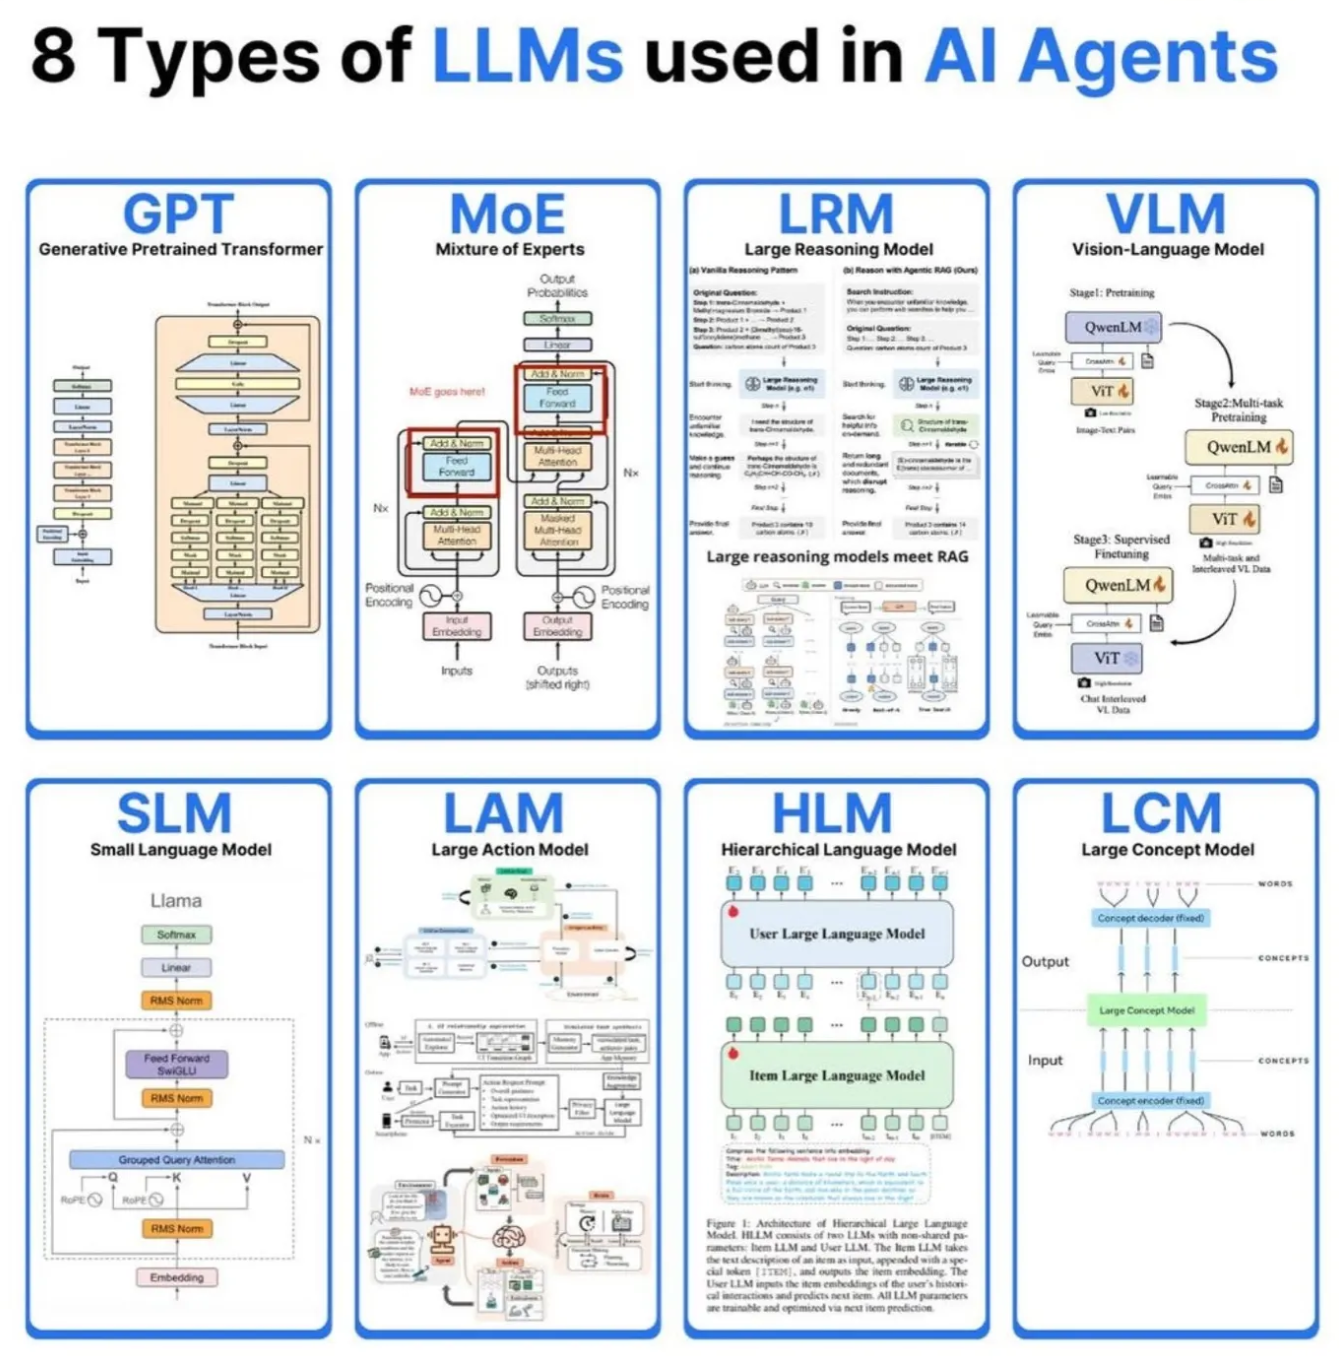

**The 8 Categories of LLMs**

- GPT (General-Purpose Generative Pretrained Transformer) : This is the default "text-in to text-out" brain used for general reasoning, drafting, and synthesis. While it offers the strongest generalization and is easy to steer, it can often be overkill and expensive for simple, repetitive tasks. It serves as the primary engine for most open-ended conversational applications.
- MoE (Mixture of Experts) : Designed for high throughput and scale, this architecture uses a "router" to activate only a few specific "expert" sub-networks for each token processed. This allows the model to have a massive effective parameter count without requiring the full compute cost for every step. It is the go-to "big-iron" upgrade when you need scale without crushing latency.
- LRM (Large Reasoning Model) : Focused on multi-step reasoning, tool use, and Retrieval-Augmented Generation (RAG). These models utilize chain-of-thought processing and self-consistency checks to provide search-grounded, verifiable answers with citations. They are essential for complex technical queries where reliability is more important than speed.
- VLM (Vision-Language Model) : These models interpret pixels and text simultaneously to understand screenshots, diagrams, and physical documents. They turn visual data into structured insights, making them ideal for processing invoices, navigating user interfaces, or analyzing product photos.
- SLM (Small Language Model) : Optimized for on-device or edge computing, SLMs are fast, cheap, and private. They are perfect for fast control loops and local data governance where a 70B parameter model would be too slow or resource-intensive. They require tighter prompts but excel at narrow, well-defined tasks.
- LAM (Large Action Model) : A LAM is specialized in turning language into concrete actions via tools and APIs. Whether it is booking a flight, creating a JIRA ticket, or querying a database, these models focus on executing real-world work through deterministic schemas and strict input validation.
- HLM (Hierarchical Language Model) : This operates as a "planner–worker" stack where a high-level top model decomposes complex tasks into a list of sub-tasks. Specialist models then execute those individual steps. While it introduces orchestration complexity, it provides high transparency, modularity, and the ability to parallelize work.
- LCM (Large Concept Model) : Instead of generating text immediately, an LCM maps inputs to interpretable concepts like specific skills, entities, or risk categories. This makes the AI's decision-making process auditable and controllable, allowing it to be easily grounded in Knowledge Graphs or strictly enforced safety policies.

# Modern LLMs Components

## Tokenization

In 2026, tokenization is no longer just "breaking words into pieces"; it is a highly engineered compression layer. As vocabularies expand to 128k or 256k entries, the efficiency of how text is mapped to integers directly determines the model's "effective" context length and reasoning speed.

**Byte-Pair Encoding (BPE) and Tiktoken**

BPE remains the industry standard, notably through the Tiktoken implementation. It iteratively merges the most frequent adjacent pairs of bytes into a single new token.
- Large Vocabularies: By using massive vocabularies (e.g., GPT-4o and Llama 3/4), models can represent entire technical terms (e.g., "photosynthesis") or common code snippets as a single integer. This reduces the total sequence length, allowing the model to "see" more text in its fixed context window.

**WordPiece and SentencePiece**

While BPE is common in decoder-only models, WordPiece (used by BERT/Gemma) and SentencePiece (used by Llama/T5) offer different advantages.
- SentencePiece is unique because it treats the input as a raw stream of characters—including spaces—which it treats as a special symbol (_). This removes the need for a language-specific "pre-tokenizer," making it the architecture of choice for truly global, multilingual models that handle languages like Japanese or Chinese where word boundaries aren't marked by spaces.

**Unigram Language Modeling** 

Unlike BPE, which starts with characters and merges them, Unigram starts with a massive vocabulary and iteratively prunes the least useful tokens based on a probabilistic model.
- The Benefit: It provides multiple ways to tokenize a single sentence (subword regularization), which can be used during training to make the model more robust to spelling errors or different writing styles.

**Byte-level and Character-level Fallbacks**

To eliminate "out-of-vocabulary" errors, modern tokenizers use UTF-8 Byte Fallback. If a model encounters a rare emoji or an obscure mathematical symbol it doesn't recognize, it breaks that character down into its raw UTF-8 bytes. This ensures the model can process any possible input string without crashing or returning an <UNK> (unknown) token.

**Visual and Multimodal Tokenization**
    
The 2026 generation of "Native Multimodal" models uses Visual Quantization (such as VQ-VAE or ViT patches).
- Discrete Vision Tokens: Images are sliced into small patches, and each patch is mapped to a "visual vocabulary" entry. To the model's internal Transformer, an image is simply a sequence of tokens, no different from a paragraph of text, enabling seamless cross-modal reasoning within a single unified latent space.

## Attention Mechanisms

The standard Multi-Head Attention (MHA) was the primary bottleneck of early models due to its quadratic scaling. Modern architectures utilize a suite of specialized mechanisms to handle massive contexts and noise reduction:

- Grouped-Query Attention (GQA): Used in Llama 3/4 and Mistral. It functions as a middle ground between MHA and Multi-Query Attention (MQA). By grouping multiple query heads to share a single Key-Value (KV) head, it drastically reduces the memory footprint of the KV Cache. This allows for significantly higher throughput and longer conversations without the performance degradation seen in MQA.
- Differential Attention (Diff-Transformer): A breakthrough from Microsoft Research that tackles "attention noise." Instead of a single softmax map, it calculates the difference between two separate attention maps. This subtraction cancels out irrelevant background noise, allowing the model to focus purely on the "signal," which significantly reduces hallucinations in long documents.
- Ring Attention: Designed for "near-infinite" context, Ring Attention distributes the attention calculation across a ring of multiple GPUs. By overlapping the communication of KV blocks with the computation of the next block, it allows models to process sequences of 100 million tokens or more, limited only by the number of devices in the cluster rather than individual GPU memory.
- Dilated Attention (LongNet): Inspired by dilated convolutions in vision, this mechanism expands the model’s "attentive field" exponentially as the distance between tokens increases. It provides a logarithm dependency between tokens, enabling a $1$ billion token context window while maintaining linear computational complexity.
- Flash Attention-3: A hardware-aware algorithm that optimizes how the GPU’s SRAM and HBM interact. By using asynchronous execution and "warpshaping" strategies, it eliminates memory-bound bottlenecks, making the $O(N^2)$ calculation so fast that context windows of 128k to 1M tokens become standard even on consumer-grade hardware.
- Sliding Window Attention (SWA): Rather than attending to every token in a document, each layer only "sees" a fixed-size window of nearby tokens. Because these windows are stacked across layers, the model develops a "receptive field" that covers the entire sequence, reducing complexity from $O(N^2)$ to $O(N)$.
- Multi-Head Latent Attention (MLA): Popularized by the DeepSeek-V3 series, MLA uses low-rank joint compression for the KV cache. It compresses the Key and Value vectors into a latent space, allowing the model to maintain the representational power of many heads while requiring only a fraction of the memory traditionally needed to store the conversation history.

## Positional Encodings

Positional encodings are the "GPS" of a Large Language Model. Because the Transformer architecture processes all words in a sequence simultaneously (parallelization), it has no inherent sense of order. Without these encodings, a model would see "The dog bit the man" and "The man bit the dog" as identical sets of words. Detailed breakdown of the primary positional encoding strategies used in modern LLMs:

**1. Absolute Positional Encodings**

These methods assign a unique, fixed vector to every specific index (e.g., position 1, position 2).
- Sinusoidal (Fixed) Encodings: Used in the original 2017 Transformer. It uses sine and cosine functions of different frequencies to create a unique signature for each position.
    - Pros: Requires no extra parameters; can theoretically handle sequences longer than those seen during training.
    - Cons: Struggles to capture complex relative relationships between tokens.
- Learned Encodings: Used in models like BERT and GPT-2. Instead of a formula, the model has a dedicated "lookup table" of embeddings for each position (up to a maximum limit, like 512 or 2048) that it optimizes during training.
    - Pros: Can learn the most "useful" representation for a specific dataset.
    - Cons: Hard-coded limit; the model cannot process a single token beyond the maximum position it was trained on.

**2. Relative Positional Encodings**

Rather than focusing on where a token is in the sentence, these focus on how far tokens are from each other.
- ALiBi (Attention with Linear Biases): Popularized by the MPT and Bloom models. It doesn't add vectors to the embeddings. Instead, it penalizes the attention score between two tokens based on their distance—the further apart they are, the lower the bias.
    - Pros: Incredible extrapolation; a model trained on 2k tokens can often work on 8k or more without retraining.
- T5 Relative Bias: Used in Google's T5 model. It learns a specific scalar bias for different "buckets" of distances (e.g., "1 token away," "2–4 tokens away," etc.).

**3. Rotary Positional Embeddings (RoPE)**

The current industry standard for state-of-the-art models like Llama 3, PaLM, and Mistral.
- Mechanism: RoPE treats token representations as pairs of coordinates in a high-dimensional space and "rotates" them. The amount of rotation depends on the token's position. When the model calculates attention, the dot product between two tokens naturally captures their relative distance through the angle between them.
- Scaling (Long Context): RoPE is highly compatible with "Linear Scaling" and YaRN (Yet another RoPE extension), allowing developers to "stretch" the rotation angles to expand context windows from 4k to 128k or even 1M tokens with minimal fine-tuning.

**4. Contextual & Advanced Encodings (The Frontier)**

Newer methods aim to make "position" more than just a number.
- CoPE (Contextual Position Encoding): A 2024 advancement from Meta. Instead of counting tokens (1, 2, 3...), CoPE allows the model to "count" based on context. For example, it can learn to attend to the "2nd previous sentence" or the "3rd previous code function," regardless of how many tokens are in between.
- NoPE: Some research suggests that with specific training (like in the C4 dataset), models can actually learn implicit positional logic without any explicit encoding at all, though this is not yet the standard for large-scale production models.

## Architecture

In early 2026, the landscape of Large Language Model (LLM) design has matured into a diverse ecosystem of specialized primitives. Developers no longer rely on raw scaling alone; instead, they utilize a sophisticated array of architectural families to navigate the trade-offs between "reasoning density," memory bandwidth, and the quadratic costs of long-sequence processing.

**Dense Transformers (The Baseline)**

The classic decoder-only Transformer remains the foundation for mid-sized models (7B–70B parameters) where maximum knowledge density is required. In this setup, every input token activates every parameter in the network, ensuring predictable scaling and high-quality reasoning.
- The Components: Modern dense stacks use RMSNorm or LayerNorm variants for numerical stability during training and SwiGLU/GeGLU activations in the feed-forward blocks to capture non-linear relationships more effectively.
- Positioning: Instead of fixed sine waves, these models use Rotary Positional Embeddings (RoPE) or ALiBi, allowing the model to understand the relative distance between words, which is crucial for maintaining coherence in long documents.
- Examples: Llama 3.1/4 (Meta), Gemma 3 (Google), and Qwen 2.5 (Alibaba).

**Mixture-of-Experts (MoE)**

MoE has become the dominant paradigm for frontier-class models reaching into the trillions of parameters. Instead of a single massive feed-forward layer, MoE uses a "sparse" architecture containing many parallel sub-networks called "experts."
- How it Works: A lightweight Gating Network (Router) evaluates each token and directs it to only a few specific experts (usually 1 to 8). This allows a model to have a massive "brain" (total parameters) while only spending the compute power of a much smaller model (active parameters) for each word generated.
- Trade-offs: While MoE offers incredible throughput, it requires sophisticated load-balancing to prevent "router collapse" (where one expert gets overworked while others sit idle) and carries a larger memory footprint, as the entire expert suite must be available in VRAM.
- Examples: DeepSeek-V3, Mixtral 8x22B, and Grok-3.

**State-Space Models (SSMs) and Mamba**

Introduced as a challenge to the "Attention" bottleneck, Mamba-family models replace the standard self-attention mechanism with Selective Scanning. This allows the model to process sequences with linear-time complexity ($O(N)$) rather than the squared complexity ($O(N^2)$) of Transformers.
- The "State" Advantage: These models maintain a compressed internal state that is updated sequentially, making them incredibly efficient for ultra-long contexts (100k to 1M+ tokens).
- Evolution: Early SSMs struggled with precise data retrieval, but by 2026, improved selective mechanisms have allowed them to rival Transformers in reasoning while using a fraction of the memory for long-form generation.
- Examples: Jamba 1.5 (AI21 Labs) and Falcon Mamba.

**Diffusion Transformers (DiT) for Text and Multimodality**

Originally designed for image generation, the Diffusion Transformer (DiT) architecture is increasingly used for LLMs that must handle multimodal inputs (video, audio, text) within a single unified latent space.
- The Architecture: These models treat text generation as a denoising process. By using a Transformer backbone to predict noise levels, they offer smoother transitions in creative writing and better integration with visual data.
- Scaling: DiT scales exceptionally well with compute, making it a favorite for models that power generative video and world simulators.
- Examples: Sora-v2 (OpenAI) and Llama-Gen (Meta).

**Retentive Networks (RetNet)**

RetNet is a strong competitor to both Transformers and SSMs, marketed as "The Successor to Transformers." It utilizes a Multi-Scale Retention mechanism that can operate in three modes: parallel (for fast training), recurrent (for efficient inference), and chunkwise (for long-form processing).
- The Mechanism: It avoids the $O(N^2)$ cost by using a decaying retention score that naturally forgets older, less relevant information while keeping a sharp focus on recent context.
- Inference Speed: RetNet offers significantly higher throughput than Transformers because it doesn't require a traditional, massive KV cache to function.
- Examples: Research models from Microsoft and specialized "Edge LLMs."

**Hybrid Architectures**

The most promising frontier in 2026 is the hybrid approach, which interleaves different layer types to neutralize the weaknesses of individual architectures. By combining Attention, MoE, and SSM layers, developers create models that are "jacks of all trades."
- The Synergy: Attention excels at global reasoning and precise retrieval; MoE provides cheap parameter scaling for vast knowledge; and SSMs/Mamba layers provide memory efficiency for massive context windows.
- Implementation: A model might use one Attention layer for every three Mamba layers, ensuring the model can "look back" precisely while maintaining high-speed streaming capabilities.
- Examples: DeepSeek-V3 (MoE + Dense), Jamba (Transformer + Mamba + MoE), and Qwen 3 experimental hybrids.

## Normalization and Activation Functions

**Normalization**

Normalization acts as the model's "internal thermostat," ensuring that signal values do not explode or vanish as they pass through hundreds of layers.
- RMSNorm (Root Mean Square Layer Normalization): Now the universal standard for models like Llama 3, GQA-based hybrids, and DeepSeek. Unlike traditional LayerNorm, it skips the "mean-centering" step and only scales the input by the root mean square of its elements.
    - Architecture Benefit: It provides a 10%–40% speedup in the normalization phase because it avoids the overhead of calculating the mean. It assumes that the "offset" (mean) of the data is less important than its "scale" (variance) for stabilizing gradients.
- DeepNorm: Developed to solve the "Deep Transformer" problem where models with 100+ layers become unstable. It modifies the initialization and residual connections, scaling the identity branch differently than the sub-layer branch.
    - Architecture Benefit: It allows models to scale to extreme depths (e.g., 200–400 layers) without requiring the complex hyperparameter tuning usually needed to prevent training collapse.
- LayerNorm (Standard): Still found in some older GPT-style architectures. It normalizes across the feature dimension and includes a "bias" term. In 2026, it is largely considered legacy for frontier LLMs due to higher computational overhead compared to RMSNorm.
- Query-Key Normalization (QK Norm): A specialized technique where normalization is applied specifically to the Query and Key vectors inside the attention head.
    - Architecture Benefit: It prevents "attention sinks" and numerical instability in very high-dimensional models, ensuring that the dot-product results don't exceed the precision limits of FP16 or BF16 formats.
    
**Activation Functions**

Activation functions are the "gates" that decide which information is important enough to pass to the next layer. Modern functions are "gated," meaning they use one part of the input to decide how much of the other part to let through.
- SwiGLU (Swish-Gated Linear Unit): The 2026 gold standard for feed-forward networks (FFN). It is a hybrid of the Swish function and the Gated Linear Unit.
    - Architecture Benefit: Instead of a simple "on/off" switch like ReLU, SwiGLU uses two separate linear layers that are multiplied together. This provides a smoother gradient and more "expressive power," allowing the model to learn subtle nuances in logic and coding.
- GeGLU (Gaussian Error Gated Linear Unit): A variant of the GELU activation used in many Google-originated models like PaLM and Gemini.
    - Architecture Benefit: It approximates the Gaussian cumulative distribution function. Like SwiGLU, it is a gated unit, but it utilizes the Gaussian error function to "soften" the activation, which has been shown to improve performance in reasoning-heavy tasks.
- GELU (Gaussian Error Linear Unit): The successor to ReLU used in early GPT-3/4 models. It weights inputs by their percentile rather than just zeroing out negative values.
    - Architecture Benefit: It allows a small amount of "negative signal" to pass through, which helps prevent "dead neurons" (where parts of the model stop learning entirely during training).
- ReLU (Rectified Linear Unit): The classic $f(x) = \max(0, x)$ function. In 2026, it is almost exclusively used in tiny "edge" models or older research benchmarks because it lacks the sophistication required for complex language understanding at scale.

# LLMs Model Selection

## NLP Tasks and LLMs

**1. Text Summarization (Long-Context Specialists)**

Summarization requires a model that can ingest massive amounts of data without suffering from "middle-of-the-document" forgetfulness, a phenomenon known as the "lost in the middle" problem.
- Jamba 1.5/2.0 (AI21 Labs): A hybrid architecture that interleaves Transformer layers with Mamba (SSM) layers. This allows for linear-time complexity $O(N)$, meaning it can summarize a 500-page document with the same efficiency a standard model uses for a few pages.
- Claude 4 (Anthropic): Utilizing ALiBi and RoPE positional encodings, Claude is optimized for "high-fidelity retrieval." It is excellent for creative or executive summaries where the "tone" of the original text must be preserved.
- Gemini 1.5 Pro: Its Ring Attention mechanism allows it to process up to 2 million tokens, making it the only choice for summarizing entire video series or massive technical repositories in a single pass.

**2. Language Translation (Multilingual & Sparse Models)**

Effective translation requires a massive "world knowledge" base and a tokenizer that treats all languages equally.
- DeepSeek-V3: A Mixture-of-Experts (MoE) model that excels at high-speed translation. It uses Multi-Head Latent Attention (MLA) to reduce memory costs while maintaining trillion-parameter performance across 100+ languages.
- Qwen 3 (Alibaba): The dominant model for Eastern linguistic nuances. Its architecture is optimized with RMSNorm and a massive multilingual training set, specifically excelling in the transition between high-context languages like Mandarin and low-context languages like English.

**3. Chatbots & Conversational AI (High-Throughput Models)**

Chatbots require low latency and efficient handling of the "KV Cache" to remember long conversations without crashing the server or increasing cost-per-query.
- GPT-4o / GPT-5 (OpenAI): A native multimodal model. Its breakthrough is a Unified Latent Space, allowing it to process text, audio, and vision simultaneously. This makes it the premier choice for human-like, real-time voice and vision-integrated chatbots.
- Llama 4 (Meta): The industry standard for self-hosted chat. Because it utilizes Grouped-Query Attention (GQA), the memory required to store conversation history is slashed, allowing a single GPU to serve dozens of concurrent users.

**4. Information Extraction & Topic Modeling**

These tasks require a model to strictly adhere to logical structures (like JSON or SQL) and identify latent themes in messy, unstructured data.
- Mistral Large 3: Known for its "instruction-following" precision. It uses a refined SwiGLU activation setup that excels at identifying entities (names, dates, prices) and extracting them into structured formats without "hallucinating" extra data.
- BERTopic-LLM (Hybrid): For topic modeling, developers now use a hybrid approach: an encoder model (like RoBERTa-v2) to create embeddings, and a generative model (like Llama 4) to label the discovered clusters with natural language names.

**5. Text Classification & Sentiment Analysis**

Classification is a "discriminative" task that is now handled most efficiently by small-language models (SLMs) or "Distilled" models that minimize latency.
- Phi-4 (Microsoft): A tiny but mighty model (under 4B parameters) trained on "textbook-quality" synthetic data. It is the gold standard for high-volume sentiment analysis, spam detection, and intent classification on local or edge hardware.
- Gemma 3 (Google): Built on the same technical foundations as Gemini, this model is optimized for on-device execution, ensuring that sensitive data used for classification (like internal company emails) never leaves the local machine.

**6. Question Answering (QA) & RAG (Retrieval-Augmented Generation)**

Modern QA models focus on "grounding" their answers in external evidence to prevent hallucinations.
- Perplexity-Sonar (Online LLMs): These are specialized models optimized for searching the live web. They use Cross-Attention mechanisms to compare their internal knowledge against real-time search results, citing sources with high precision.
- Command R+ (Cohere): Specifically designed for RAG workflows. It has a high "Contextual Precision" score, meaning it excels at ignoring irrelevant data in a search result and focusing only on the snippets that answer the user's query.

**7. Natural Language Inference (NLI) & Formal Logic**

NLI involves determining if one sentence logically follows from another (entailment, contradiction, or neutral).
- DeepSeek-R1 / o1-series: These use "Chain of Thought" (CoT) reinforcement learning. They are the best for tasks where the model must "verify" its own logic before providing an answer, making them ideal for legal reasoning or software bug detection.

**8. Text-to-SQL & Code Generation**

These models treat natural language as a prompt to generate rigid, executable syntax.
- StarCoder 3: A model trained almost exclusively on code and technical documentation. It uses Fill-In-the-Middle (FIM) capabilities, allowing it to complete code in the middle of a file by looking at both the code above and below the cursor.

## LLMs Suffix Syntax

Understanding this "suffix syntax" is essential to knowing whether a model will fit on your hardware, how it will behave in a chat, and which architectural breakthroughs it utilizes.

**1. The Llama & Meta Collection**

In the Meta ecosystem, the suffix indicates the scale of the "brain" and its specialized protective layers.

Model Size (1B, 3B, 8B, 11B, 70B, 405B): The number represents parameters in billions ($10^9$).

- 1B – 3B: "Mobile/Edge" versions. Optimized for on-device processing (phones/tablets).
- 8B – 11B: "Small/Workstation" versions. The 11B variant often includes Vision capabilities. These run on high-end consumer GPUs (RTX 4090/5090).
- 70B: "Medium/Pro" version. The balanced choice for enterprise-grade reasoning.
- 405B: "Flagship/Frontier" version. Meta’s most powerful model, requiring massive computing clusters.

Model Type (Base vs. Instruct):

- -Base / No Suffix: The raw "Next-Token Predictor." Trained to complete patterns but lacks social conditioning; it may repeat questions rather than answering them.
- -Instruct: The "Agentic" version. Refined via SFT and RLHF, it is designed to follow commands and behave as a helpful assistant.

Safety & Capability Suffixes:

- -Llama-Guard: A "Classifier" model acting as a digital bouncer to detect toxic, biased, or dangerous content.
- -Prompt-Guard: A tiny 86M parameter model designed to intercept "Prompt Injections" and jailbreak attempts.
- -Vision: Indicates the model is multimodal, capable of processing image inputs alongside text.

**2. The GPT & OpenAI Series**

OpenAI uses suffixes to denote specific optimization paths, ranging from all-purpose models to high-speed thinkers.

Model Flavors:

- -o (Omni): A native multimodal model handling text, audio, and vision in a single unified space.
- -turbo: Versions optimized for significantly lower latency and higher throughput.
- -mini: A smaller, cost-efficient version with high "reasoning density" for its scale.

Reasoning & Snapshots:

- -o1 / -o3: Reasoning models using Chain-of-Thought (CoT). They "think" before generating an answer to verify logic.
- Date-Based Snapshots (e.g., -2024-08-06): Allows developers to lock in a specific version to ensure "Output Stability" and prevent software breakage during updates.

**3. The DeepSeek Series**

DeepSeek suffixes describe how "thinking" was achieved and how the architecture manages parameter efficiency.

Reasoning Core:

- -Zero: The "Raw RL" version. Trained without human examples, it "thinks out loud" in a raw, highly intelligent, yet sometimes chaotic way.
- -Distill: Identifies a "Student" model. A smaller architecture (like Llama or Qwen) taught to mimic the logic of the massive DeepSeek-R1 (685B).

Efficiency & Architecture:

- -MoE (Mixture of Experts): A "Sparse" model that only activates a fraction of its parameters (e.g., 21B out of 236B) per task for extreme speed.
- -MLA (Multi-Head Latent Attention): A 2026-standard suffix for massive memory savings in long conversations.
- -V2.5 / -V3: Mid-gen upgrades that merge specialized coding and chat branches into one unified weights file.

**4. The Qwen & Alibaba Series**

Qwen models are highly optimized for technical tasks, mathematics, and Eastern linguistic nuances.

Domain Specialists:

- -Coder: Specifically fine-tuned on vast repositories of code; optimized for software engineering.
- -Math: Optimized for solving complex equations and generating high-quality LaTeX output.

Generational Suffixes:

- -Qwen3: The latest 2026 architecture utilizing advanced attention mechanisms to reduce KV Cache memory requirements.

**5. The Phi & Gemma Collections**

Microsoft and Google focus on "Smarter, not Bigger," targeting high performance in compact sizes.

Phi & Gemma Types:

- Phi-4: Trained on "synthetic textbooks," allowing a 3B model to rival the logic of much larger 70B models.
- -it (Instruction Tuned): The Google/Gemma equivalent of "Instruct."
- -pt (Pre-trained): The Google/Gemma equivalent of "Base."

Framework Suffixes:
- -pytorch / -keras / -jax: Indicates which specific software library the model is formatted for.

**6. Quantization & Performance**

These suffixes describe how a model was "shrunk" to fit into specific VRAM or RAM limits.

Mathematical Precision:

- -BF16 / -FP16: Uses precision; high quality but requires maximum memory.
- -FP8 / -INT8: Uses 8-bit math to halve memory usage with negligible quality loss.
- -Q4_K_M / -int4: 4-bit quantization, shrinking the model by roughly 70-75 percent for consumer hardware.

Library & Method:

- -GGUF: Designed for llama.cpp and Ollama; optimized for CPU and Apple Silicon.
- -AWQ / -GPTQ: Standardized formats for high-speed NVIDIA GPU cloud deployment.
- -QAT (Quantization Aware Training): A premium version where the model was "born small," retaining higher intelligence than models shrunk after training.

**7. BERT & Encoder Suffixes:**

BERT models focus on "reading" and "understanding" rather than generating text.

- -cased vs. -uncased: "Cased" distinguishes between "Apple" (company) and "apple" (fruit); "Uncased" treats everything as lowercase for robustness.
- -WWM (Whole Word Masking): An advanced training technique where the model hides entire words rather than fragments, boosting context accuracy.

# Fine Tuning LLMs

Fine-tuning a Large Language Model (LLM) is the process of taking a "pre-trained" model (which has already learned general language, grammar, and facts from the internet) and training it further on a specific, smaller dataset.

## Types of Fine-Tuning

- Supervised Fine-Tuning (SFT): This is the fundamental "bridge" from a base model to an assistant. It uses curated datasets of Prompt-Response pairs. The model learns to map specific input patterns to a structured output format, establishing the "personality" and baseline reliability of the AI.
- Instruction Tuning: A specialized form of SFT that uses high-diversity datasets (like Dolly or Alpaca) to teach the model how to follow commands. Instead of just "knowing facts," the model learns to execute tasks like summarization, brainstorming, or creative writing across a wide variety of topics.
- Self-Supervised Fine-Tuning (SSFT): In this method, the model acts as its own teacher. It is often used to improve reasoning capabilities. The model generates multiple solutions to a problem, evaluates them (sometimes using an external tool like a Python interpreter or a logical verifier), and then fine-tunes itself only on the successful "chains of thought." This is a key part of how "reasoning models" like DeepSeek-R1 are developed.
- Semi-Supervised Fine-Tuning: This approach combines a small amount of high-quality labeled data with a large amount of unlabeled data. The model uses the labeled data to learn the task format, then "pseudo-labels" the unlabeled data by predicting what the response should be. After filtering for high-confidence predictions, the model is trained on both the real and predicted labels.
- Domain Adaptation (Continual Pre-training): This involves training the model on a massive corpus of raw, unlabeled text from a specific field (e.g., legal case law or medical research). Unlike SFT, there are no questions or answers; the model simply learns the "language," vocabulary, and deep statistical patterns of that industry.
- Alignment (RLHF & DPO): These are "preference-based" types of tuning used after SFT to refine behavior.
    - RLHF (Reinforcement Learning from Human Feedback): Uses a separate "Reward Model" that mimics human judgment to score the LLM's answers, pushing it toward outputs that humans rank as more helpful.
    - DPO (Direct Preference Optimization): A more efficient alternative that directly optimizes the LLM to choose the "Better" answer over the "Worse" answer in a dataset of paired choices, skipping the need for a separate reward model.
- Task-Specific Fine-Tuning: The most narrow form of tuning, where the model is optimized for a single, repetitive output, such as converting natural language into SQL queries or extracting specific entities from medical prescriptions.
- Multimodal Fine-Tuning: A specialized type where a model is trained on pairs of different data types, such as Image-Text or Audio-Text. This allows the model to "see" or "hear" by learning to align visual/auditory tokens with language tokens.

## Ways to Fine-Tune LLMs

There are several strategies for fine-tuning, ranging from updating the entire model to only touching a tiny fraction of it:
- Full Fine-Tuning : In this method, every single parameter in the model is updated. While it is highly accurate, it is extremely expensive in terms of VRAM and compute, often requiring industrial-grade hardware clusters. This method is best for massive domain shifts, such as teaching a general model to become a specialized legal or medical expert. However, it risks Catastrophic Forgetting, where the model loses its general reasoning abilities while trying to master the new task.
- Parameter-Efficient Fine-Tuning (PEFT) : These methods are the industry standard for most users because they are fast and resource-light. Instead of training the whole model, you only train a small "adapter" or a subset of layers.
    - LoRA (Low-Rank Adaptation): You inject small, trainable mathematical matrices into the Transformer layers. The original model weights remain frozen, and only these tiny matrices are updated.
    - QLoRA: A step further where the base model is quantized (compressed) to 4-bit, and LoRA is applied on top. This allows you to fine-tune a massive model (like Llama 70B) on a single consumer GPU.
    - IA3 (Infused Adapter by Inhibiting and Amplifying Inner Activations): A method that scales inner activations by learned vectors, achieving efficiency even greater than LoRA for certain tasks.
- Additive Tuning (Prompt Tuning and Prefix Tuning) : Instead of changing the model's weights, these methods focus on the input space.
    - Prompt Tuning: You keep the model frozen and learn a "soft prompt"—a series of continuous vectors that act as a virtual prefix to your input.
    - Prefix Tuning: Similar to prompt tuning, but it prepends trainable parameters to every layer of the transformer architecture, not just the input layer, providing more steering power.
- Adapter-Based Tuning : This involves inserting small bottleneck layers (adapters) between existing layers of the pre-trained model. Only these new layers are trained. It allows for "modular" AI, where you can swap different adapters onto the same base model to perform different tasks.
- Preference Alignment (RLHF and DPO) : Once a model has been fine-tuned on instructions, it often undergoes an alignment phase to match human preferences.
    - RLHF (Reinforcement Learning from Human Feedback): This uses a separate Reward Model to score LLM outputs, utilizing PPO (Proximal Policy Optimization) to adjust the LLM’s behavior toward safer or more helpful responses.
    - DPO (Direct Preference Optimization): A more recent alternative to RLHF that eliminates the need for a separate reward model. DPO directly optimizes the model using a binary cross-entropy loss on a dataset of "preferred" vs. "rejected" responses, making the alignment process more stable and computationally efficient.

## Fine Tune LLMs Implementation Framework

When you are ready to write code, your choice of framework determines your level of control—from high-level automation to low-level tensor of LLMs manipulation.Choosing a framework depends on whether you want "push-button" simplicity or "from-scratch" control.
- Hugging Face Trainer API (The Industry Standard) The Trainer and SFTTrainer (from the TRL library) are the most popular ways to fine-tune. This method sits on top of PyTorch but automates the "boring" parts like manual gradient clipping, device placement, and logging. It is designed specifically for supervised fine-tuning and handles data formatting and "packing" (combining short samples) automatically to save GPU time.
- Native PyTorch (Maximum Control) This is the "manual" way to fine-tune, providing total control over the training process. You write the manual training loop, define your own optimizer (like AdamW), and handle backpropagation yourself. This is essential for researchers who are inventing new loss functions or need to implement custom sharding techniques like FSDP (Fully Sharded Data Parallel).
- Keras and TensorFlow (Modular Simplicity) Using Keras 3 or KerasHub, you can load models like Gemma or Llama as standard Keras layers. This allows you to use the familiar model.compile() and model.fit() syntax. It is a great choice for developers who want to integrate LLMs into a larger TensorFlow production pipeline or leverage TPU (Tensor Processing Unit) acceleration.
- Efficiency-First Frameworks (Unsloth & Axolotl)
    - Unsloth: A specialized wrapper that manually rewrites the mathematical kernels of the model. It can make fine-tuning up to 2x faster and use 70% less memory than standard PyTorch.
    - Axolotl: A configuration-based framework where you define your model and parameters in a simple .yaml file. It handles the backend complexities for you, making it excellent for reproducible and scalable training runs.
    - Llama-Factory: A comprehensive, user-friendly framework that offers a "no-code" web interface (Gradio) to manage the entire fine-tuning process.
    - DeepSpeed: A Microsoft library designed for high-end users who need to perform massive-scale full fine-tuning across many GPUs.

## HuggingFace API Parameters

#### Tokenizer Parameters

`AutoTokenizer.from_pretrained`

The tokenizer converts text into numbers. If configured incorrectly, the model will output gibberish.

`pretrained_model_name_or_path`
- Input: String (matches the model path on HuggingFace website).
- Function: Loads the specific vocabulary and merge rules for the model.
- Result: Ensures the numbers (tokens) sent to the model align with what it was originally trained on.

`use_fast`
- Input: Boolean (True, False).
- Function: Uses a Rust-based "Fast" tokenizer implementation.
- Result: Significantly speeds up the tokenization of large datasets. Almost always set to True.

`padding_side`
- Input: String ("left", "right").
- Function: Determines where the "padding" tokens are added to make sentences the same length.
- Result: For Causal LLMs (text generation), you must use "left" during inference, but "right" is often used for training with SFTTrainer.

`add_eos_token / add_bos_token`
- Input: Boolean (True, False).
- Function: Automatically adds "End of Sentence" or "Beginning of Sentence" markers.
- Result: Vital for fine-tuning. If the model doesn't learn when to stop (EOS), it will generate endless loops of text.

`truncation`
- Input: Boolean (True, False).
- Function: Cuts off sequences that are longer than the model's max context window.
- Result: Prevents memory errors when a specific document in your dataset is too long for the model to handle.

#### Model Loading Parameters

`AutoModelForCausalLM.from_pretrained`

These parameters dictate the "physical" state of the model on your hardware.

`pretrained_model_name_or_path`
- Input: String (e.g., "meta-llama/Llama-3-8b", "./local_model_folder/").
- Function: The unique identifier or path to the model weights.
- Result: Points the library to the specific architecture and weights to download or load.

`device_map`
- Input: String ("auto", "balanced") or Dict (mapping layers to specific GPUs).
- Function: Dictates which parts of the model go to which GPU/CPU.
- Result: Setting this to "auto" automatically handles "Model Parallelism," splitting the model across multiple GPUs if one isn't large enough.

`quantization_config`
- Input: BitsAndBytesConfig object.
- Function: Configures 4-bit or 8-bit loading (QLoRA).
- Result: Drastically reduces VRAM usage. For example, loading an 8B model in 4-bit requires ~5GB of VRAM instead of 16GB.

`torch_dtype`
- Input: torch.dtype (e.g., torch.float16, torch.bfloat16, "auto").
- Function: Sets the precision of the weights.
- Result: bfloat16 is preferred for modern GPUs to maintain numerical stability during fine-tuning.

`trust_remote_code`
- Input: Boolean (True, False).
- Function: Allows the execution of custom modeling code provided by the model author on the Hub.
- Result: Required for many new architectures (like Falcon or Phi) that haven't been merged into the core Transformers library yet.

`attn_implementation`
- Input: String ("eager", "sdpa", "flash_attention_2").
- Function: Chooses the mathematical engine for the Attention mechanism.
- Result: "flash_attention_2" is significantly faster and more memory-efficient but requires specific hardware (A100, H100, RTX 30/40 series).

`low_cpu_mem_usage`
- Input: Boolean (True, False).
- Function: Changes how the model is initialized to avoid using 2x the model size in CPU RAM.
- Result: Prevents system crashes (OOM) during the initial loading phase.

#### Fine Tuning Parameters

`TrainingArguments`

`TrainingArguments` defines the execution logic of the fine-tuning process. Because LLMs are computationally heavy, these parameters are the difference between a successful training run and prevent a "CUDA Out of Memory" (OOM) error. Here is a breakdown of the primary TrainingArguments grouped by their functional impact.

**1. Hardware & Memory Efficiency**

These parameters dictate how the model interacts with your GPU.

`per_device_train_batch_size`
- Input: Integer (e.g., 1, 4, 8).
- Function: The number of training examples processed simultaneously on a single GPU.
- Result: Higher values result in more stable gradient updates and faster training but require significantly more VRAM. For 7B models on 24GB GPUs, this is often set to 1 or 2.

`gradient_accumulation_steps`
- Input: Integer (e.g., 4, 8, 16).
- Function: The number of steps to accumulate gradients before performing a single weight update.
- Result: This allows you to simulate a large Global Batch Size without needing a massive GPU. (Effective Batch Size = per_device_train_batch_size × gradient_accumulation_steps × num_gpus).

`gradient_checkpointing`
- Input: Boolean (True, False).
- Function: Re-computes activations during the backward pass instead of storing them all in memory.
- Result: Reduces VRAM usage by 30-50% at the cost of roughly 20% slower training speed. Essential for fine-tuning models larger than 7B on consumer hardware.

`fp16 or bf16`
- Input: Boolean (True, False).
- Function: Enables Mixed Precision training. BF16 (BFloat16) is the 2026 industry standard for LLMs.
- Result: Halves memory usage and speeds up training. BF16 is preferred over FP16 because it has a wider dynamic range, preventing the "NaN" loss errors common in LLM fine-tuning.

**2. Learning & Optimization Logic**

These "knobs" control how the model learns from your specific dataset.

`learning_rate`
- Input: Float (e.g., 2e-4, 5e-5).
- Function: Controls the size of the steps the optimizer takes when updating weights.
- Result: High values (e.g., 1e-3) lead to fast but unstable learning and "catastrophic forgetting." Low values (e.g., 1e-6) are safer but may fail to adapt the model to your specific style or data.

`lr_scheduler_type`
- Input: String ("linear", "cosine", "constant", "cosine_with_restarts").
- Function: Defines how the learning rate changes over the course of training.
- Result: "cosine" is standard for smooth convergence; "linear" is often used for shorter instruction-tuning runs.

`warmup_ratio or warmup_steps`
- Input: Float (0.03) or Integer (100).
- Function: Gradually increases the learning rate from zero to the target rate at the start of training.
- Result: Prevents the model from being "shocked" by massive gradients in the first few batches, leading to much more stable convergence.

`weight_decay`
- Input: Float (e.g., 0.01, 0.1).
- Function: A penalty added to the loss function based on the size of the weights (Regularization).
- Result: Prevents the model from becoming too reliant on specific training examples (overfitting).

`optim`
- Input: String ("adamw_torch", "paged_adamw_32bit", "paged_adamw_8bit").
- Function: The algorithm used to update weights.
- Result: Using "paged_adamw_8bit" is the standard for QLoRA. It offloads optimizer states to CPU RAM when the GPU is full, effectively preventing OOM errors.

**3. Training Duration & Checkpointing**

These parameters manage the timeline of your fine-tuning run.

`num_train_epochs`
- Input: Float or Integer (e.g., 1, 3).
- Function: The number of times the model sees the entire dataset.
- Result: For LLM fine-tuning, 1 to 3 epochs is usually sufficient. More can lead to "overfitting," where the model mimics the data exactly but loses its general intelligence.

`max_steps`
- Input: Integer (e.g., 500, 1000).
- Function: Overrides epochs to stop training after a specific number of updates.
- Result: Useful for long datasets where you only want to perform a specific amount of training.

`save_steps / save_strategy`
- Input: Integer (100) / String ("steps", "epoch").
- Function: How often the model "saves" its progress to disk.
- Result: Frequent saving protects against hardware crashes but consumes significant disk space (a 7B model checkpoint is approx. 14GB-28GB).

**4. Logging & Evaluation**

Parameters for tracking the "health" of the training process.

`logging_steps`
- Input: Integer (e.g., 1, 10).
- Function: How often the loss (error rate) is printed to the console.
- Result: Lower values provide a smoother "Loss Curve" in tools like Weights & Biases (W&B).

`eval_strategy`
- Input: String ("steps", "epoch", "no").
- Function: Determines when to run the model against a "validation set" it hasn't seen yet.
- Result: Essential for verifying that the model is actually learning and not just memorizing.

`report_to`
- Input: String or List ("tensorboard", "wandb", "none").
- Function: Where to send the training metrics for visualization.

**5. Advanced Optimization & Stability**

These parameters ensure the training process doesn't "explode" and that the model updates its weights in a controlled manner.

`max_grad_norm`
- Input: Float (e.g., 0.3, 0.5, 1.0).
- Function: Clips the maximum value of the gradients (the steepness of the update).
- Result: This is vital for model stability, especially in Mixture-of-Experts (MoE) or 4-bit models. It prevents a single "bad" batch from causing massive weight shifts that would ruin the pre-trained knowledge.

`warmup_steps`
- Input: Integer (e.g., 100, 500).
- Function: The number of initial steps where the learning rate grows from zero to its maximum value.
- Result: Unlike warmup_ratio (which is a percentage of total training), this provides a fixed window of time for the model to "warm up" its adapters. It leads to much more stable loss curves at the very beginning of a run.

`ddp_find_unused_parameters`
- Input: Boolean (True, False).
- Function: Used in multi-GPU (Distributed Data Parallel) training to check for layers that aren't participating in the gradient calculation.
- Result: Setting this to False (as in your code) reduces overhead and speeds up training. It is almost always set to False when using LoRA because the adapters are the only things being updated.

**6. Model Selection & Checkpoint Management**

These parameters control which version of the model you actually keep and how much disk space you use.

`load_best_model_at_end`
- Input: Boolean (True, False).
- Function: At the end of the training, the trainer will automatically reload the weights from the version that performed best on your evaluation set.
- Result: Ensures that even if the model started "overfitting" in the final epoch, you walk away with the most generalized version of your fine-tune.

`metric_for_best_model`
- Input: String (e.g., "eval_loss", "accuracy").
- Function: Specifies the criteria used to decide which model version is the "best."
- Result: Usually set to eval_loss. It directs the trainer to prioritize the model that had the lowest error on data it wasn't trained on.

`greater_is_better`
- Input: Boolean (True, False).
- Function: Tells the trainer whether a higher value for your chosen metric is good (like Accuracy) or bad (like Loss).
- Result: For eval_loss, this must be False. This setting prevents logic errors where the trainer accidentally saves the worst-performing model.

`save_total_limit`
- Input: Integer (e.g., 2).
- Function: Limits the number of model checkpoints saved in your output_dir.
- Result: Crucial for disk management. Since each LLM checkpoint can be several gigabytes, this prevents your hard drive or cloud storage from filling up by deleting older, inferior checkpoints.

**7. Data Handling & Performance**

`remove_unused_columns`
- Input: Boolean (True, False).
- Function: Automatically drops columns from your dataset that aren't mentioned in the model's forward function.
- Result: Setting this to False is often necessary when using custom datasets or TRL’s SFTTrainer to ensure the "text" or "label" columns aren't accidentally deleted before the trainer can process them.

`dataloader_pin_memory`
- Input: Boolean (True, False).
- Function: Keeps the data in "pinned" (non-pageable) CPU memory to speed up transfers to the GPU.
- Result: While it can speed up data loading, setting it to False (as in your code) is a safer bet on systems with limited RAM to avoid system-wide lag or crashes.

`group_by_length`
- Input: Boolean (True, False).
- Function: Batches together sequences of similar lengths.
- Result: If False, the trainer uses random sampling. While True can speed up training by reducing padding, it is often disabled (False) for models with specific architectures like MoE (Phi-3.5 or Ministral) to maintain uniform distribution across the "experts."

**8. Logging & Identification**

`run_name`
- Input: String (e.g., "phi-3.5-moe-lora-qa").
- Function: A human-readable label for this specific training experiment.
- Result: Used to identify the run in logging dashboards like Weights & Biases or Tensorboard. This makes it much easier to compare different hyperparameter settings later.

`output_dir`
- Input: String/Path.
- Function: The folder where all logs, checkpoints, and the final model will be saved.
- Result: Organizing these by run names prevents you from accidentally overwriting a successful fine-tune with a new experiment.

**Special SFTTrainer Parameters (TRL Specific)**

Beyond the standard TrainingArguments, the TRL SFTTrainer uses these inputs:
- `packing` (Boolean): Combines multiple short examples into a single sequence.
    - Result: Increases training speed by 2x-4x by eliminating wasted space (padding) in your GPU memory.
- `max_seq_length` (Integer): The maximum context window for training (e.g., 2048, 4096).
    - Result: Directly impacts VRAM. Doubling this usually requires significantly more memory.

# Optimization Methods for Fine-Tuning LLMs

To achieve high-performance results without requiring a supercomputer, developers rely on a sophisticated stack of optimizations. These methods reduce the computational bottleneck of the "Attention" mechanism and manage the massive memory footprint of model weights and gradients.

**Mixed Precision (BF16/FP16)**

Standard training uses 32-bit floats (FP32). Mixed precision uses 16-bit floats (FP16 or BFloat16) for calculations while keeping a master copy of weights in 32-bit. This halves the memory required for activations and speeds up computation on modern GPUs. BFloat16 (BF16) is generally preferred as it handles large numerical ranges better than FP16, preventing the "gradient explosion" or "vanishing" issues that can crash training.

**Flash Attention**

The standard "Attention" mechanism grows in complexity at a squared rate ($O(N^2)$) relative to sequence length. Flash Attention is an IO-aware algorithm that optimizes how the GPU memory handles these calculations. It reduces the memory requirement to a linear scale, allowing you to train on massive context windows (e.g., 32k or 128k tokens) that would otherwise cause an "Out of Memory" (OOM) error.Gradient CheckpointingDuring training, the GPU usually saves every intermediate "activation" from the forward pass to use during the backward pass. This consumes massive VRAM. 

**Gradient Checkpointing**

During training, the GPU usually saves every intermediate "activation" from the forward pass to use during the backward pass. This consumes massive VRAM. Gradient Checkpointing only saves a few "checkpoints" and re-computes the missing activations on the fly when needed. This reduces VRAM usage by up to 70% at the cost of about 20% slower training speed.

**Data Packing**

If you have many short training examples, the GPU has to "pad" the empty space in each block with zeros to reach a uniform length. Data packing concatenates all your examples into a single long stream of tokens, separated by "End of Sentence" (EOS) markers. This ensures that every single GPU cycle is spent processing actual data rather than empty padding.

**Knowledge Distillation**

This is a method where a large, highly capable "Teacher" model (like GPT-4) trains a smaller "Student" model (like a 7B Llama).How it works: 
    - Instead of just learning from hard labels (right/wrong), the student model tries to mimic the "logits" or the probability distributions of the teacher.
    - Benefit: It allows a much smaller, faster model to capture the complex reasoning capabilities of a giant model.

**Token Pruning and Sequence Truncation**

Token pruning dynamically identifies and removes "unimportant" tokens (like punctuation or redundant words) during the forward pass of the model. By reducing the number of tokens the model has to "attend" to, you significantly lower the computational cost and memory usage for long-form generation tasks.

**Weight Pruning and Sparsity**

This optimization involves removing weight connections that have a near-zero impact on the model's output.
    - Structured Pruning: Removes entire neurons or channels, making the model physically smaller and faster.
    - Unstructured Pruning: Zeros out individual weights, creating a "sparse" model. When combined with specialized hardware, this can lead to massive speedups in inference and further fine-tuning.

**Parameter-Efficient Fine-Tuning (PEFT)**

These methods are the "gold standard" for fine-tuning because they don't touch the original model weights, instead training a tiny fraction of new parameters.
- LoRA (Low-Rank Adaptation): Inserts small trainable matrices into the transformer layers.
- QLoRA: Quantizes the base model to 4-bit and then applies LoRA. This allows you to fine-tune a 70B model on a single 24GB VRAM GPU.
- DoRA (Weight-Decomposed Low-Rank Adaptation): A more advanced version of LoRA that separates weight updates into "magnitude" and "direction," allowing the model to learn complex logic faster.
- IA3 (Infused Adapter by Inhibiting and Amplifying Inner Activations): Scales internal activations by learned vectors, making it even lighter than LoRA.

**Gradient Accumulation**

If your GPU is too small to handle a large "Batch Size," you can use a small batch size (like 1 or 2) and accumulate the gradients over multiple steps. The model only updates its weights after a set number of steps (e.g., 32). This allows you to simulate the stability of a massive training run on a single, low-VRAM GPU.

**Pager / Optimizer State Offloading (8-bit Optimizers)**

Optimizers like AdamW store a "memory" of previous gradients, which can take up even more VRAM than the model itself.
    - 8-bit Optimizers (bitsandbytes) Optimizers like AdamW store a "memory" of previous gradients, which can take up more VRAM than the model itself. Using 8-bit optimizers compresses this memory by 75%, allowing you to fit much larger models or larger batch sizes into the same GPU memory.
    - CPU Offloading: You can move the optimizer states from the GPU VRAM to your system's RAM (CPU memory). This is slower but allows you to tune models that are technically too large for your GPU.

**Paged Attention & Quantization (NF4)** 

Specifically for QLoRA, the use of 4-bit NormalFloat (NF4) is a specialized optimization. It maps the weights of the model to a normal distribution, preserving more information than standard 4-bit integers. Combined with Paged Optimizers, which handle memory spikes by offloading to the CPU temporarily, this makes it possible to tune a 70B model on a single 48GB GPU.

**FSDP (Fully Sharded Data Parallel)**

When training across multiple GPUs, FSDP "shards" (splits) the model weights, gradients, and optimizer states across all available cards. No single GPU holds the whole model. When a layer needs to be calculated, the GPUs communicate to temporarily share the necessary parts. This is the primary optimization used for "Full Fine-Tuning" of massive models.

## Parameter-Efficient Fine-Tuning (PEFT) Parameters

The LoraConfig is the heart of LoRA (Low-Rank Adaptation). Instead of updating all billions of parameters in an LLM, LoRA freezes the original weights and injects small, trainable "adapter" matrices into specific layers. This makes fine-tuning incredibly efficient. Below are the parameters, their inputs, and their roles in the fine-tuning process.

**1. The Core "Rank" Parameters**

These define the size and mathematical strength of the adapters.

`r` (Rank)
- Input: Integer (e.g., 8, 16, 32, 64).
- Function: This is the "rank" of the low-rank matrices. It determines the number of trainable parameters.
- Result: A higher $r$ allows the model to learn more complex patterns but increases VRAM usage and the risk of overfitting. For most instruction tuning, an $r$ of 8 or 16 is sufficient.

`lora_alpha`
- Input: Integer (e.g., 16, 32).
- Function: A scaling factor for the LoRA weights. The adapter weights are scaled by the ratio $\frac{\alpha}{r}$.
- Result: It acts like a "learning rate" for the adapters. A common best practice is to set `lora_alpha` to double the value of r (e.g., $r=16, \alpha=32$) to ensure the adapters have enough influence over the frozen base model.

**2. Targeting the Model Architecture**

This is where you tell LoRA exactly which parts of the brain to modify.

`target_modules`
- Input: List of Strings or a Regex pattern (e.g., ["q_proj", "v_proj"]).
- Function: Identifies which specific layers (linear modules) will receive LoRA adapters.
- Details on Input Values: 
    - Attention Modules: `q_proj (Query), k_proj (Key), v_proj (Value), and o_proj (Output)`. Targeting q_proj and v_proj is the bare minimum for fine-tuning.
    - MLP Modules: `gate_proj, up_proj, and down_proj`. In modern architectures (like Llama or Mistral), adding these to your target list significantly improves the model's ability to learn new facts.
    - "all-linear": A shortcut string used to apply LoRA to every linear layer in the model.
- Result: Targeting more modules increases the "capacity" of the fine-tune. Research suggests that targeting all linear layers with a lower $r$ is often more effective than targeting only a few layers with a very high $r$.

**3. Training Behavior & Regularization**

These control how the model behaves during the actual training steps.

`lora_dropout`
- Input: Float (e.g., 0.05, 0.1).
- Function: Randomly zeros out a percentage of the LoRA adapter neurons during training.
- Result: Prevents the adapters from "memorizing" the training data (overfitting), helping the model generalize better to unseen prompts.

`bias`
- Input: String ("none", "all", "lora_only").
- Function: Determines if the "bias" parameters of the layers should be trained.
- Result: Usually set to "none". Training biases increases the parameter count with very little gain in performance.

`modules_to_save`
- Input: List of Strings (e.g., ["embed_tokens", "lm_head"]).
- Function: Identifies modules that should be fully trained and saved alongside the LoRA adapters.
- Result: Useful if you are adding new tokens to the vocabulary or performing domain-specific fine-tuning where the model needs to "relearn" how to predict the very next word.

**4. Specialized Task Parameters**

`task_type`
- Input: String (e.g., "CAUSAL_LM", "SEQ_2_SEQ_LM").
- Function: Tells the PEFT (Parameter-Efficient Fine-Tuning) library what kind of model you are using.
- Result: For standard LLMs (Llama, GPT, etc.), this should always be "CAUSAL_LM". It ensures the library handles the loss calculation and saving correctly.

`inference_mode`
- Input: Boolean (True, False).
- Function: Specifies if the config is being used for training or just for running the model later.
- Result: Always False during the fine-tuning stage.

**Summary of Impact on Fine-Tuning**

The magic of LoraConfig is that it allows you to tune a model with less than 1% of the original parameters.
- Low $r$ + High Alpha: Best for style-transfer or following specific instructions.
- High $r$ + MLP Targeting: Best for teaching the model new domains of knowledge (e.g., medical or legal data).
- All-Linear Targeting: The modern default for the best overall performance vs. memory trade-off.

## Quantization Parameters

`BitsAndBytesConfig`

The `BitsAndBytesConfig` is the primary tool used to implement QLoRA (Quantized Low-Rank Adaptation). It allows you to shrink massive LLMs so they fit on accessible hardware by compressing the weights from 16-bit to 4-bit or 8-bit. It is also the engine that enables QLoRA and 8-bit quantization, allowing you to fit massive models into much smaller GPU memory footprints.

**1. 8-Bit Quantization Parameters**

Setting `load_in_8bit=True` enables `LLM.int8()`. This method quantizes the majority of the model's weights to 8-bit integers while keeping important "outlier" values in 16-bit to maintain accuracy.

`load_in_8bit`
- Input: Boolean (True, False).
- Function: Enables 8-bit quantization for the base model.
- Result: Reduces the VRAM required to load model weights by roughly 50%. It is generally more accurate than 4-bit but uses more memory.

`llm_int8_threshold`
- Input: Float (typically 6.0).
- Function: Sets the value threshold for identifying outlier features.
- Result: Any hidden state value exceeding this threshold is processed in 16-bit (FP16). Lowering this value makes the model more precise but uses more VRAM; increasing it saves VRAM but may lead to a degradation in text quality.

`llm_int8_skip_modules`
- Input: List of Strings (e.g., ["lm_head", "embed_tokens"]).
- Function: Specifies modules that should remain in their original precision (FP16/BF16).
- Result: Essential for protecting sensitive layers like the prediction head, ensuring that the final output tokens are calculated with maximum accuracy.

`llm_int8_enable_fp32_cpu_offload`
- Input: Boolean (True, False).
- Function: Allows the model to offload 8-bit weights to the CPU RAM if the GPU is full.
- Result: Prevents "Out of Memory" (OOM) crashes, though it significantly slows down training and inference due to the data transfer bottleneck between CPU and GPU.

**2. 4-Bit Quantization Parameters (QLoRA)**

Setting load_in_4bit=True enables 4-bit NormalFloat (NF4) quantization, which is the core of the QLoRA technique. This is the 2026 standard for fine-tuning 7B to 70B models on consumer-grade hardware.

`load_in_4bit`
- Input: Boolean (True, False).
- Function: Compresses the model weights down to 4 bits.
- Result: Reduces VRAM usage by approximately 75%. This allows you to fine-tune a 7B model on as little as 6GB–8GB of VRAM or a 70B model on a single 48GB GPU.

`bnb_4bit_compute_dtype`
- Input: torch.dtype (e.g., torch.bfloat16, torch.float16).
- Function: The data type used for the mathematical computations during the forward and backward passes.
- Result: Even though weights are stored in 4-bit, they are "dequantized" to this type for math. bfloat16 is highly recommended as it prevents the gradient overflows (NaN loss) common in 4-bit training.

`bnb_4bit_quant_type`
- Input: String ("nf4" or "fp4").
- Function: Selects the storage data type. "fp4" is a standard 4-bit float, while "nf4" is NormalFloat4.
- Result: "nf4" is mathematically optimized for weights that follow a normal (Gaussian) distribution. Using "nf4" yields significantly higher accuracy than "fp4," making it the default choice for high-quality fine-tuning.

`bnb_4bit_use_double_quant`
- Input: Boolean (True, False).
- Function: Performs a second round of quantization on the quantization constants.
- Result: Saves an additional 0.4 bits per parameter on average. For a 70B model, this translates to several gigabytes of VRAM savings without any measurable drop in model performance.

`bnb_4bit_quant_storage`
- Input: torch.dtype (e.g., torch.bfloat16).
- Function: Defines the data type in which the quantized weights are stored.
- Result: Usually set to match the compute_dtype. It ensures the bit-packing process is optimized for the specific GPU architecture you are using.

**Impact on Fine-Tuning**

- 4-bit (NF4 + Double Quant): Best for fine-tuning large models on limited hardware. Minimal accuracy loss when paired with LoRA adapters.
- 8-bit: Good for inference or when you have slightly more VRAM and want to avoid the potential noise of 4-bit quantization.
- 16-bit (Full/Half Precision): Best for maximum performance and stability if you have massive GPU resources (e.g., A100/H100 clusters).

In [17]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
%%capture
# Download dataser via API
!pip install kaggle
#!/bin/bash
!kaggle datasets download stackoverflow/stacksample

In [20]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = 'stacksample.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


# Setup Environment

In [15]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version:    {torch.version.cuda}")
    print(f"GPU Device:      {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0+cu128
CUDA Available:  True
CUDA Version:    12.8
GPU Device:      NVIDIA RTX A4000


In [1]:
%%capture
!pip install polars beautifulsoup4 markdownify
!pip install rouge-score nltk
#!pip install transformers

# Upgrade Libraries to compatible with new version of pre-trained model
!pip install --upgrade polars beautifulsoup4 markdownify
!pip install --upgrade transformers datasets huggingface-hub peft accelerate bitsandbytes evaluate

# Check CUDA compatible with your PyTorch version if you have to upgrade PyTorc in your environment
# https://pytorch.org/get-started/previous-versions/
#!pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu126
#!pip install --uograde torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu126

# For model fine tuning optimization
#!pip install deepspeed
!pip install --upgrade deepspeed
!apt-get update -y
!apt-get install -y libaio-dev

In [ ]:
import os
import collections
import math
import logging
import numpy as np
import pandas as pd
import polars as pl
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split

# Resource monitoring
import time
import threading
import psutil

# evaluation metrics
import nltk
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# huggingface ecosystem
import torch
from datasets import Dataset, DatasetDict
from huggingface_hub import login
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
    AutoConfig,
    GPT2Tokenizer,
    GPT2Model,
    GPT2LMHeadModel,
    Mistral3ForConditionalGeneration,
    MistralCommonBackend,
)
import transformers
import transformers.utils.import_utils

os.environ["TOKENIZERS_PARALLELISM"] = "false"

login("YOUR_HF_ACCESS_TOKEN")

nltk.download('punkt', quiet=True)

# Data Loading

In [2]:
def clean_html(text):
    if not text:
        return ""
    soup = BeautifulSoup(text, 'html.parser')
    return soup.get_text(separator=' ', strip=True)

# Load with proper encoding (filter for answer score more than 5)
questions = pl.read_csv(
    "Questions.csv",
    encoding="utf8-lossy",
    columns=["Id", "Title", "Body", "Score"]
).filter(pl.col("Score") > 5)

answers = pl.read_csv(
    "Answers.csv",
    encoding="utf8-lossy",
    columns=["Id", "ParentId", "Body", "Score"]
).filter(pl.col("Score") > 5)

# Only samples data due to computational limitation
questions = questions.sort("Score", descending=True).head(100)

# Data Preprocessing

In [3]:
questions = questions.with_columns([
    pl.col("Body").map_elements(clean_html, return_dtype=pl.Utf8),
    pl.col("Title").str.strip_chars()
])

answers = answers.with_columns(
    pl.col("Body").map_elements(clean_html, return_dtype=pl.Utf8)
)


# Simple join and select
qa_pairs = answers.join(
    questions,
    left_on="ParentId",
    right_on="Id",
    how="inner"
).select([
    pl.col("ParentId").alias("question_id"),  # Use ParentId as question_id
    pl.col("Title").alias("question_title"),
    pl.col("Body_right").alias("question_body"),
    pl.col("Score_right").alias("question_score"),
    pl.col("Id").alias("answer_id"),
    pl.col("Body").alias("answer"),
    pl.col("Score").alias("answer_score")
])

print(f"Questions: {questions.height:,}")
print(f"Answers: {answers.height:,}")
print(f"Q&A pairs: {qa_pairs.height:,}")

Questions: 100
Answers: 154,002
Q&A pairs: 931


In [4]:
if qa_pairs.height > 0:
    q_id = qa_pairs[0, "question_id"]
    q_data = qa_pairs.filter(pl.col("question_id") == q_id)
    
    print("QUESTION WITH ANSWERS")
    print("\n" + "-"*80)
    
    print(f"\nTitle: {q_data[0, 'question_title']}")
    print(f"Score: {q_data[0, 'question_score']}")
    print(f"\nBody:")
    print("-" * 40)
    print(q_data[0, "question_body"][:800])
    print("-" * 40)
    
    print(f"\nAnswers ({q_data.height}):")
    for i in range(q_data.height):
        print(f"\nAnswer {i+1} (Score: {q_data[i, 'answer_score']}):")
        print("-" * 30)
        print(q_data[i, "answer"][:500])
        print("-" * 30)

QUESTION WITH ANSWERS

--------------------------------------------------------------------------------

Title: How do you disable browser Autocomplete on web form field / input tag?
Score: 1614

Body:
----------------------------------------
How do you disable autocomplete in the major browsers for a specific input (or form field )?
----------------------------------------

Answers (18):

Answer 1 (Score: 1637):
------------------------------
Firefox 30 ignores autocomplete="off" for passwords, opting to prompt the user instead whether the password should be stored on the client. Note the following commentary from May 5, 2014: The password manager always prompts if it wants to save a password. Passwords are not saved without permission from the user. We are the third browser to implement this change, after IE and Chrome. According to Mozilla developer documentation the form element attribute autocomplete prevents form data from being
------------------------------

Answer 2 (Score: 11

In [5]:
qa_selected = qa_pairs.select([
    "question_title", 
    "question_body", 
    "answer"
])

print(f"\nSelected columns Q&A pairs: {qa_selected.height:,}")
print("\nColumns in selected dataframe:")
print(qa_selected.columns)


Selected columns Q&A pairs: 931

Columns in selected dataframe:
['question_title', 'question_body', 'answer']


In [6]:
if qa_selected.height > 0:
    print("\n" + "="*80)
    print("SAMPLE Q&A (Selected Columns Only)")
    print("="*80)
    
    for i in range(min(3, qa_selected.height)):
        print(f"\nQ&A Pair #{i+1}:")
        print("-" * 40)
        print(f"Question Title: {qa_selected[i, 'question_title']}")
        print(f"\nQuestion Body:")
        print("-" * 20)
        print(qa_selected[i, 'question_body'][:300] + ("..." if len(qa_selected[i, 'question_body']) > 300 else ""))
        print(f"\nAnswer:")
        print("-" * 20)
        print(qa_selected[i, 'answer'][:400] + ("..." if len(qa_selected[i, 'answer']) > 400 else ""))
        print("="*80)


SAMPLE Q&A (Selected Columns Only)

Q&A Pair #1:
----------------------------------------
Question Title: How do you disable browser Autocomplete on web form field / input tag?

Question Body:
--------------------
How do you disable autocomplete in the major browsers for a specific input (or form field )?

Answer:
--------------------
Firefox 30 ignores autocomplete="off" for passwords, opting to prompt the user instead whether the password should be stored on the client. Note the following commentary from May 5, 2014: The password manager always prompts if it wants to save a password. Passwords are not saved without permission from the user. We are the third browser to implement this change, after IE and Chrome. According to M...

Q&A Pair #2:
----------------------------------------
Question Title: How do you disable browser Autocomplete on web form field / input tag?

Question Body:
--------------------
How do you disable autocomplete in the major browsers for a specific input (or 

# Dataset Splitting

In [7]:
unique_questions = qa_selected["question_title"].unique().to_list()
print(f"Unique questions: {len(unique_questions):,}")

train_questions, temp_questions = train_test_split(
    unique_questions, 
    test_size=0.2,  
    random_state=42
)

test_questions, val_questions = train_test_split(
    temp_questions,
    test_size=0.3,  
    random_state=42
)

print(f"\nSplit sizes:")
print(f"Train questions: {len(train_questions):,} ({len(train_questions)/len(unique_questions)*100:.1f}%)")
print(f"Test questions: {len(test_questions):,} ({len(test_questions)/len(unique_questions)*100:.1f}%)")
print(f"Validation questions: {len(val_questions):,} ({len(val_questions)/len(unique_questions)*100:.1f}%)")

train_data = qa_selected.filter(
    pl.col("question_title").is_in(train_questions)
)

test_data = qa_selected.filter(
    pl.col("question_title").is_in(test_questions)
)

val_data = qa_selected.filter(
    pl.col("question_title").is_in(val_questions)
)

print(f"\nData splits by question-title:")
print(f"Train data: {train_data.height:,} rows")
print(f"Test data: {test_data.height:,} rows")
print(f"Validation data: {val_data.height:,} rows")

Unique questions: 100

Split sizes:
Train questions: 80 (80.0%)
Test questions: 14 (14.0%)
Validation questions: 6 (6.0%)

Data splits by question-title:
Train data: 739 rows
Test data: 141 rows
Validation data: 51 rows


# Resource Monitoring Function

In [8]:
class ResourceMonitor(threading.Thread):
    def __init__(self, interval=2.0):
        super().__init__()
        self.interval = interval
        self.running = False
        self.cpu_samples = collections.deque(maxlen=1000)
        self.memory_samples = collections.deque(maxlen=1000)
        
    def run(self):
        self.running = True
        while self.running:
            self.cpu_samples.append(psutil.cpu_percent(interval=self.interval))
            self.memory_samples.append(psutil.virtual_memory().percent)
            
    def stop(self):
        self.running = False
        
    def get_average(self):
        if not self.cpu_samples:
            return 0, 0
        return sum(self.cpu_samples) / len(self.cpu_samples), sum(self.memory_samples) / len(self.memory_samples)
        
    def clear(self):
        self.cpu_samples.clear()
        self.memory_samples.clear()

class EpochMonitor(TrainerCallback):
    def __init__(self):
        self.start_time = time.time()
        self.epoch_data = []
        self.current_epoch = None
        self.monitor = ResourceMonitor(interval=1.0)
        
    def on_train_begin(self, args, state, control, **kwargs):
        self.monitor.start()
        
    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start = time.time()
        self.current_epoch = state.epoch
        self.monitor.clear()
        
    def on_epoch_end(self, args, state, control, **kwargs):
        epoch_time = time.time() - self.epoch_start
        avg_cpu, avg_memory = self.monitor.get_average()
        
        self.epoch_data.append({
            'epoch': self.current_epoch,
            'time': epoch_time,
            'avg_cpu': avg_cpu,
            'avg_memory': avg_memory
        })
        
    def on_train_end(self, args, state, control, **kwargs):
        self.monitor.stop()

# GPT (Generative Pretrained Transformer)

GPT models are the foundation of most AI systems today. Built using the Transformer architecture, GPTs learn by predicting the next token in a text sequence, enabling them to generate human-like language.

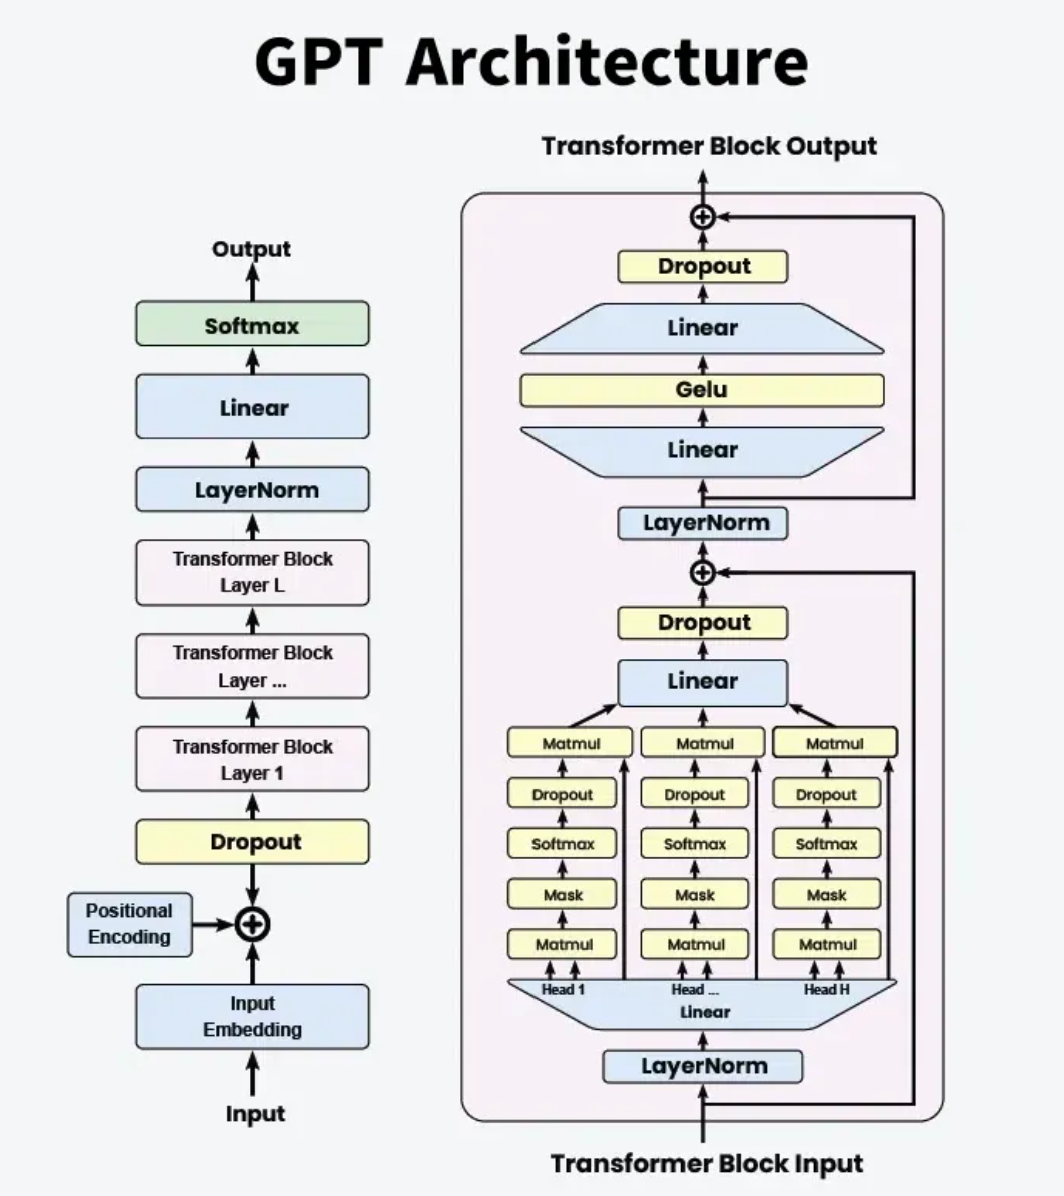

**The Architecture: Decoder-Only Transformer**

While the original Transformer (introduced in 2017) had two parts—an Encoder and a Decoder—GPT models specifically use a Decoder-only architecture. This means the model is optimized for "causal" modeling, where it only looks at the past to predict the future.

**Key Components of the Architecture**

**A. Input Embeddings and Positional Encoding**

Since computers don't understand words, text is converted into vectors (lists of numbers). Because Transformers process all words in a sentence simultaneously (rather than one by one), they need Positional Encodings added to the word vectors to know the order of the words.

**B. The Transformer Block (Repeated $N$ times)**

A GPT model consists of multiple identical layers stacked on top of each other. Each layer has two main sub-components:

- Masked Multi-Head Self-Attention: This allows the model to "focus" on relevant words regardless of how far apart they are. For example, in the sentence "The cat, which was hungry, ate its food," the attention mechanism helps the model link "ate" back to "cat."
    - Masked: In a decoder, the model is prevented from "looking ahead" at the words it is trying to predict. It can only see words to its left.
    
- Feed-Forward Network (FFN): After the attention mechanism gathers information from other words, the FFN processes that information for each word independently to transform the representation further.

**C. Layer Normalization and Residual Connections**

- Residual Connections: These act like "shortcuts" that pass the original input around the attention/FFN layers. This helps prevent the "vanishing gradient" problem, allowing models to be very deep (100+ layers).

- Layer Norm: This keeps the mathematical values (activations) within a stable range, making training faster and more reliable. 

**D.The Output (Softmax)**

The final layer converts the model's internal numbers into a probability distribution over the entire vocabulary. If the model has 50,000 words in its "dictionary," it assigns a percentage chance to each word; the word with the highest probability is usually chosen as the next word.

## Pythia-410m (EleutherAI)

The EleutherAI/pythia-410m is part of a specialized suite of models designed to provide a transparent look into how large language models learn. Because it was built for research, its architecture is highly standardized but includes a few modern "twists" that differentiate it from the original GPT-3 design.

### Pythia-410m Tokenizer

**Tokenizer: GPT-NeoX-20B**

The model uses the GPT-NeoX-20B tokenizer, which is a Byte-Pair Encoding (BPE) tokenizer. It was specifically trained on The Pile, a massive 825GB dataset of diverse English text.

**Vocabulary and Special Tokens**

- Vocabulary Size: It contains 50,277 unique tokens.
- EOS (End of Sequence): The EOS token is `<|endoftext|>`. Its job is to act as a "stop sign" for the model. When the model generates this token, it signals that the thought or sentence is complete, preventing the model from generating infinite loops of text.
- Padding (PAD): Interestingly, the Pythia models do not have a dedicated padding token by default. In practice, researchers usually set the pad_token to be the same as the eos_token (`<|endoftext|>`). Padding is used to make all sequences in a "batch" the same length so the computer can process them all at once. For example, if your batch has one 10-word sentence and one 5-word sentence, the shorter one gets 5 "padding" tokens added to its end to match the longer one.

In [8]:
# Configuration
MODEL_NAME = "EleutherAI/pythia-410m"
OUTPUT_DIR = "./pythia-410m-finetuned"
MAX_LENGTH = 128

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Tokenization with padding mask for labels
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}"
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )

    labels = tokenized["input_ids"].clone()

    # IMPORTANT: mask padding tokens in labels with -100
    labels[labels == tokenizer.pad_token_id] = -100

    tokenized["labels"] = labels
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Tokenizing training data...
Tokenizing validation data...
Train examples: 715
Validation examples: 67


### Pythia-410m  Model Architecture

The Pythia-410m uses a Decoder-only Transformer architecture. This means it is "autoregressive"—it predicts the next word in a sequence based solely on the words that came before it.

**Model Architecture**

The 410-million parameters are organized into a specific structure of 24 layers (or blocks). Each block contains several specialized components:
- Rotary Positional Embeddings (RoPE): Instead of adding a fixed number to a word to show its position (like older models), Pythia uses a rotation-based mathematical trick. This helps the model better understand the relative distance between words, even in very long sentences.
- Parallel Attention and Feed-Forward Layers: In a traditional Transformer, the data goes through an "Attention" step and then a "Feed-Forward" step in a sequence. In Pythia, these two steps happen at the same time (in parallel) and their results are added together. This makes the model faster to train without losing much accuracy.
- Layer Normalization (LayerNorm): Pythia uses "Pre-LayerNorm," meaning the data is normalized before it enters the attention and feed-forward sections. This helps keep the mathematical values stable and prevents the model from "crashing" during training.
- Flash Attention: While not a part of the mathematical "look" of the model, the architecture was trained using Flash Attention, a high-speed way for the computer to calculate which words are most important to each other.

**How the Architecture Works**

The magic of the architecture lies in the Attention Mechanism. When you give the model a prompt like "The sky is," the following process occurs:

- Vectorization: Every word is turned into a long string of numbers (a vector) of size 1024.
- Self-Attention: Inside each of the 24 layers, the model uses 16 different "Attention Heads." Each head "looks" at the sentence from a different perspective. One head might focus on the grammar, while another focuses on the factual meaning of the words.
- Information Processing: Each word "talks" to every other word that came before it to gather context. The model uses this context to update its understanding of what the current word means in this specific sentence.
- Prediction: After passing through all 24 layers, the model creates a list of probabilities for every word in its 50,277-word vocabulary. It might decide there is a 90% chance the next word is "blue" and a 2% chance it is "green."
- Iteration: It picks "blue," adds it to the sentence, and starts the entire process over again to predict the next word.

The core mathematical operation inside the attention heads is:

$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

This formula is how the model calculates the "score" for how much focus it should give to previous words when predicting the new one.

### Pythia-410m Model Fine Tuning

In [9]:
# Load model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

# Data collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

monitor = EpochMonitor()

# TrainingArguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,           
    gradient_accumulation_steps=4,
    learning_rate=1e-4,                      # higher initial LR often helps small models
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",                     
    report_to="none",
    logging_strategy="epoch",
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_torch",
    warmup_steps=100,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,                       # important clipping to prevent explosion
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

# Summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print("Starting training...")

train_result = trainer.train()

# Save final model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

`torch_dtype` is deprecated! Use `dtype` instead!
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'partial_rotary_factor'}
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'partial_rotary_factor'}


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Total parameters: 405,334,016
Starting training...


Epoch,Training Loss,Validation Loss
1,2.299326,2.600010
2,1.561476,3.196300
3,1.454580,3.083881


Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'partial_rotary_factor'}


('./pythia-410m-finetuned/tokenizer_config.json',
 './pythia-410m-finetuned/tokenizer.json')

In [10]:
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

# Extract validation losses from log history
log_history = trainer.state.log_history
validation_losses = []

for log in log_history:
    if 'eval_loss' in log:
        validation_losses.append(log['eval_loss'])

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    validation_loss = None
    if i < len(validation_losses):
        validation_loss = validation_losses[i]
    
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': validation_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nTraining Results:")
print(results_df.to_string(index=False))

print(f"\nFinal Training Loss: {train_result.training_loss:.4f}")
print(f"Total Training Time: {sum(epoch['time'] for epoch in monitor.epoch_data):.1f}s")
print(f"Average Epoch Time: {sum(epoch['time'] for epoch in monitor.epoch_data) / len(monitor.epoch_data):.1f}s")
print(f"Average CPU Usage: {sum(epoch['avg_cpu'] for epoch in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Average Memory Usage: {sum(epoch['avg_memory'] for epoch in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Training Results:
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.600010 18.509678    19.205556        8.800000
     1         3.196300 18.235100    15.252632        8.810526
     2         3.083881 18.587216    14.550000        8.811111

Final Training Loss: 1.7718
Total Training Time: 55.3s
Average Epoch Time: 18.4s
Average CPU Usage: 16.3%
Average Memory Usage: 8.8%

Training completed.


## GPT2-medium (OpenAI)

The GPT-2 Medium model, released by OpenAI, is a significant milestone in generative AI. It is a mid-sized version of the GPT-2 family, containing approximately 355 million parameters. Below is a detailed breakdown of its tokenizer, structure, and internal mechanics.

### GPT2-medium Tokenizer

**Tokenizer: Byte-Pair Encoding (BPE)**

The model uses a Byte-Level Byte-Pair Encoding (BPE) tokenizer. Unlike simple word-based tokenizers that struggle with new words, or character-based tokenizers that are very slow, BPE finds a middle ground.

It treats text as a sequence of UTF-8 bytes. This allows the tokenizer to build a vocabulary of common "sub-words." For example, the word "unbelievably" might be broken into "un", "believe", and "ably". This ensures that the model can represent almost any English word without seeing it before, effectively eliminating "out-of-vocabulary" errors.

- Vocabulary Size: 50,257 tokens.
- EOS (End of Sequence) Token: The model uses `<|endoftext|>` as its EOS token. This serves as a boundary marker, telling the model where a document or a thought ends.
- Padding (PAD): GPT-2 does not have a native padding token. When processing multiple sentences of different lengths in a batch, developers typically reuse the `<|endoftext|>` token as a "filler" (padding) to make all sequences the same length. This is necessary because the underlying math (linear algebra) requires fixed-size input grids (tensors).

In [8]:
MODEL_NAME = "gpt2-medium"
OUTPUT_DIR = "./gpt2-medium-finetuned"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) 
tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer)}")

def tokenize_examples(df, tokenizer, max_length=128):
    texts = []
    
    for row in df.iter_rows(named=True):
        text = f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}"
        texts.append(text)
    
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data, tokenizer)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data, tokenizer)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"]
})

val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"]
})

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})

print(f"Train dataset: {len(dataset_dict['train'])} examples")
print(f"Validation dataset: {len(dataset_dict['validation'])} examples")

Tokenizer loaded: gpt2-medium
Vocab size: 50257
Tokenizing training data...
Tokenizing validation data...
Train dataset: 775 examples
Validation dataset: 43 examples


### GPT2-medium Model Architecture

GPT-2 Medium uses a Transformer Decoder-only architecture. While the original Transformer paper proposed an "Encoder" (to understand text) and a "Decoder" (to generate text), GPT-2 proved that you could do both tasks using only the Decoder blocks stacked on top of each other.

**Model Architecture**

The "Medium" variant is defined by the following structural depth:

- 24 Layers: The data passes through 24 successive Transformer blocks.
- Hidden Dimension of 1024: Each token is represented by a vector of 1024 numbers.
- 16 Attention Heads: In every layer, there are 16 separate "heads" that look at different parts of the sentence simultaneously.
- Context Window: The model can "remember" and look back at a maximum of 1024 tokens at a time.

Each of the 24 layers consists of two main parts: a Multi-Head Self-Attention mechanism and a Position-wise Feed-Forward Network. Between these parts, there are "Layer Normalization" steps to keep the numbers stable and "Residual Connections" (shortcuts) that allow information to flow through the deep network without getting distorted.

**How the Architecture Works**

The GPT-2 architecture works through a process called Autoregressive Generation. This means it generates text one token at a time, using its own previous outputs as the input for the next step.
- Input and Positional Encoding: Since Transformers process all words in a sentence at once, they don't naturally know the order of words. GPT-2 adds "Positional Encodings" to the word vectors. This is a set of numbers that tells the model, "this word is in position 1, and this word is in position 2."
- Masked Self-Attention: This is the core "brain" of the decoder. It uses a "mask" to ensure the model cannot "cheat" by looking at future words during training. When predicting word #5, the attention mechanism is mathematically blocked from seeing words #6 and beyond. It can only look at words #1 through #4 to find context.
- The Formula: The attention mechanism calculates a "relevance score" between words using Queries ($Q$), Keys ($K$), and Values ($V$). The math is: $$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$ Essentially, the model calculates how much "attention" the word "bank" should pay to the word "river" versus the word "money" to determine its meaning.
- The Output Head: After the data travels through all 24 layers, it reaches a final linear layer that maps the hidden vector (1024 dimensions) back to the vocabulary size (50,257). A "Softmax" function then turns these numbers into probabilities. If the word "sky" has the highest probability, it is selected and printed out.

The process then repeats: the new word is added to the prompt, and the model starts over to predict the next word.

In [9]:
print(f"Loading {MODEL_NAME}...")

monitor = EpochMonitor()

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="fine-tune-gpt2-medium-qa",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")

print("Starting training...")
train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Loading gpt2-medium...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Total parameters: 354,823,168
Batch size: 4
Gradient accumulation: 4
Starting training...


Epoch,Training Loss,Validation Loss
1,2.535404,2.787216
2,1.974278,2.877611
3,1.743499,2.918696


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./gpt2-medium-finetuned/tokenizer_config.json',
 './gpt2-medium-finetuned/tokenizer.json')

In [10]:
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

# Extract validation losses from log history
log_history = trainer.state.log_history
validation_losses = []

for log in log_history:
    if 'eval_loss' in log:
        validation_losses.append(log['eval_loss'])

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    validation_loss = None
    if i < len(validation_losses):
        validation_loss = validation_losses[i]
    
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': validation_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nTraining Results:")
print(results_df.to_string(index=False))

print(f"\nFinal Training Loss: {train_result.training_loss:.4f}")
print(f"Total Training Time: {sum(epoch['time'] for epoch in monitor.epoch_data):.1f}s")
print(f"Average Epoch Time: {sum(epoch['time'] for epoch in monitor.epoch_data) / len(monitor.epoch_data):.1f}s")
print(f"Average CPU Usage: {sum(epoch['avg_cpu'] for epoch in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Average Memory Usage: {sum(epoch['avg_memory'] for epoch in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Training Results:
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.787216 35.463459    23.320000        7.717143
     1         2.877611 36.020796    17.641667        7.725000
     2         2.918696 36.114729    16.243243        7.802703

Final Training Loss: 2.0844
Total Training Time: 107.6s
Average Epoch Time: 35.9s
Average CPU Usage: 19.1%
Average Memory Usage: 7.7%

Training completed.


## Llama-3.1-8B-Instruct (Meta-Llama)

The Meta-Llama-3.1-8B-Instruct model is a state-of-the-art, instruction-tuned large language model. It utilizes a refined version of the Transformer architecture to achieve high performance while remaining computationally efficient enough for consumer hardware.

### Llama-3.1-8B-Instruct Tokenizer

**Tokenizer: Tiktoken-based BPE**

The Llama 3.1 8B model uses a Tiktoken-based Byte Pair Encoding (BPE) tokenizer.

**Key Characteristics:**

- Vocabulary Size: It has a significantly expanded vocabulary of 128,256 tokens (compared to 32,000 in Llama 2). This allows the model to represent text more efficiently, particularly for non-English languages and code.
- Efficiency: Because the vocabulary is larger, the model can compress more characters into a single token, leading to faster processing and a longer effective context window.
- Special Tokens: It includes specific control tokens such as `<|begin_of_text|>, <|end_of_text|>, and <|eot_id|>` (End of Turn) to manage conversational flow.

**Padding and EOS**

These two concepts are vital for how the model handles batches of data and knows when to stop talking.
- **EOS (End of Sequence)** : The EOS token is a unique marker that signals the model has finished its thought. When the model generates this specific ID (e.g., 128009 for Llama 3.1), the software running the model knows to stop the generation process. The model uses the `<|end_of_text|>` token to signify the end of a document. However, for the Instruct version, it relies heavily on the `<|eot_id|>` (End of Turn) token.
- **Padding (PAD)** : Padding is used when you want the model to process multiple sentences of different lengths at the exact same time (batching). If sentence A is 10 tokens and sentence B is 5 tokens, you add "empty" tokens (Padding) to sentence B so they both become 10 tokens long. This creates a uniform "rectangle" of data that the GPU can process efficiently.In practice, researchers usually set the `pad_token_id` to be the same as the `eos_token_id`.

In [8]:
# Configuration
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"   
OUTPUT_DIR = "./llama-3.1-8b-qlora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"""<|begin_of_text|><|start_header_id|>user<|end_header_id|>

Question: {row['question_title']}
{row['question_body']}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

{row['answer']}<|eot_id|>"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: meta-llama/Llama-3.1-8B-Instruct


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Tokenizer loaded. Vocab size: 128256
Tokenizing training data...
Tokenizing validation data...
Train examples: 760
Validation examples: 47


### Llama-3.1-8B-Instruct Model Architecture

The Llama 3.1 8B-Instruct follows a dense, decoder-only Transformer architecture. Unlike "Encoder-Decoder" models (like T5), a decoder-only model focuses on predicting the next token in a sequence based only on the preceding tokens.

**Architectural Specifications:**

- Parameters: approx. 8 Billion.
- Layers: 32 Transformer blocks.
- Hidden Dimension: 4,096.
- Attention Heads: 32 for Queries, with 8 Key-Value (KV) heads (Grouped-Query Attention).
- Context Window: Support for up to 128,000 tokens.

**Model Architecture**

The model is composed of a stack of identical layers, each containing several specialized components:
- Rotary Positional Embeddings (RoPE): Instead of adding absolute position markers to words, RoPE uses a rotation-based mathematical approach. This allows the model to understand the relative distance between words, which is key to handling its 128k context length.
- Grouped-Query Attention (GQA): A more efficient version of standard multi-head attention. In GQA, multiple "Query" heads share a single "Key" and "Value" head. This significantly reduces the memory required for the "KV Cache" during inference.
- SwiGLU Activation Function: Used in the feed-forward layers. `SwiGLU` is a hybrid of the Swish and Gated Linear Unit functions, known for helping models learn complex patterns more effectively than older functions like ReLU.
- `RMSNorm` (Root Mean Square Layer Normalization): This is applied at the start of each transformer block to stabilize training and improve computational speed by simplifying the normalization math.

**How the Architecture Works**

The model operates through a process of Autoregressive Inference. Here is the step-by-step internal logic:

1. Embedding and Positioning When you type a prompt, the tokenizer turns words into IDs. The model converts these IDs into vectors of size 4,096 (the hidden dimension). RoPE is applied to these vectors so the model knows the order of the words.
2. The Attention Stage (Context Gathering)As the vector passes through each of the 32 layers, it enters the Grouped-Query Attention block. Here, the model calculates a "compatibility score" between the current word and every word that came before it.
    - The Query ($Q$): What the current word is looking for.
    - The Key ($K$): What information the previous words contain.
    - The Value ($V$): The actual information to be extracted.The model uses the formula $$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$ to decide which previous words are most relevant to predicting the next one.
3. The Feed-Forward Stage (Refining)Once the attention block has gathered all the relevant context, the resulting data is sent to the Feed-Forward Network. This is where the model "thinks" about the gathered information. Using the SwiGLU activation, the model performs complex non-linear transformations to narrow down the meaning of the tokens.
4. Prediction and AutoregressionAfter exiting the 32nd layer, the final vector is compared against the 128,256 possible tokens in the vocabulary. The model assigns a probability to each. It picks the most likely token, adds it to the prompt, and restarts the entire 32-layer process to generate the next token. This cycle continues until an EOS or EOT token is produced.

### Llama-3.1-8B-Instruct QAT and PEFT Optimization Configuration

**Llama Quantization-Aware Training (QAT) and Parameter-Efficient Fine-Tuning (PEFT) Configuration**

This configuration sets up QLoRA (Quantized Low-Rank Adaptation), which is the industry standard for fine-tuning a model like Llama 3.1 8B on consumer GPUs. It allows you to train a massive model using only a fraction of the usual VRAM.

**1. 4-bit Quantization (BitsAndBytes)**

This section shrinks the model's weights so it fits into your GPU memory.
- `load_in_4bit=True`: Compresses the 16-bit weights into 4-bit. This reduces the model's memory footprint by roughly 4x.
- `bnb_4bit_quant_type="nf4"`: Uses Normalized Float 4, a data type specifically designed for weights with a normal distribution. It provides better accuracy than standard 4-bit integers.
- `bnb_4bit_compute_dtype=torch.bfloat16`: While weights are stored in 4-bit, the calculations happen in BrainFloat16. This prevents precision loss during the forward and backward passes.
- `bnb_4bit_use_double_quant=True`: This is "Nested Quantization." It quantizes the quantization constants themselves, saving an additional 0.4 bits per parameter (about 400MB of VRAM on an 8B model).

**2. LoRA Configuration (The Adapters)**

Instead of training all 8 billion parameters, LoRA freezes the original model and only trains small "adapter" matrices.
- `r=64` (Rank): This determines the "width" of the adapter matrices. A higher rank (like 64) allows the model to learn more complex patterns but uses more VRAM. For Llama 3.1 8B, 64 is considered a high-quality setting.
- `lora_alpha=128`: A scaling factor. The rule of thumb is to set alpha to $2 \times r$. It controls how much influence the new adapters have over the original pre-trained weights.
- `target_modules`: This list tells the code exactly where to "plug in" the adapters. By targeting all linear layers (q, k, v, o, and the MLP gates), you ensure the highest possible fine-tuning quality, similar to full fine-tuning.
- `lora_dropout=0.05`: A small amount of regularization to prevent the model from memorizing your training data (overfitting).

**3. Preparation Functions**

- `prepare_model_for_kbit_training`: This is a crucial helper function. It enables gradient checkpointing and ensures that the `"LayerNorm" and "Embedding"` layers are handled correctly in 4-bit mode to keep training stable.
- `get_peft_model`: This wraps your model with the LoRA layers. After this line, the original 8B parameters are "frozen" (untrainable), and only the new adapters will be updated.

In [9]:
# 4-bit quantization config (BitsAndBytes)
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # "nf4" is usually best quality/memory trade-off
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,        # nested quantization saves more memory
)

# Load model in 4-bit
print(f"Loading {MODEL_NAME} in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

# Prepare for k-bit training
model = prepare_model_for_kbit_training(model)

# LoRA config (only adapters are trained)
lora_config = LoraConfig(
    r=64,                          # rank – 64 is good balance for 8B models
    lora_alpha=128,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()   # should show 1–2 percent trainable params

`torch_dtype` is deprecated! Use `dtype` instead!


Loading meta-llama/Llama-3.1-8B-Instruct in 4-bit...


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

trainable params: 167,772,160 || all params: 8,198,033,408 || trainable%: 2.0465


### Llama-3.1-8B-Instruct Model Fine Tuning

In [10]:
# Training setup
monitor = EpochMonitor()

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,         
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="llama-3.1-8b-qlora-qa",
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",           # memory-efficient optimizer for QLoRA
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Mixed precision: bf16={training_args.bf16}, fp16={training_args.fp16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Total parameters: 4,708,372,480
Trainable parameters (LoRA): 167,772,160
Batch size: 4
Gradient accumulation: 8
Mixed precision: bf16=True, fp16=False
Gradient checkpointing: True
Starting training...


Epoch,Training Loss,Validation Loss
1,2.182424,2.059274
2,1.595431,2.018134
3,1.272299,2.046990


('./llama-3.1-8b-qlora-finetuned-qa/tokenizer_config.json',
 './llama-3.1-8b-qlora-finetuned-qa/chat_template.jinja',
 './llama-3.1-8b-qlora-finetuned-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nTraining Results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(epoch['time'] for epoch in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(epoch['avg_cpu'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    avg_memory = sum(epoch['avg_memory'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"Total Training Time: {total_time:.1f}s")
    print(f"Average Epoch Time: {avg_time:.1f}s")
    print(f"Average CPU Usage: {avg_cpu:.1f}%")
    print(f"Average Memory Usage: {avg_memory:.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Training Results:
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.059274 197.561263    19.533503        9.932995
     1         2.018134 197.962418    17.203535       10.668182
     2         2.046990 198.261522    18.505584       10.693401
Total Training Time: 593.8s
Average Epoch Time: 197.9s
Average CPU Usage: 18.4%
Average Memory Usage: 10.4%

Training completed.


## Qwen-3-8B

As of early 2026, Qwen3-8B represents the latest evolution in the Qwen series from Alibaba Cloud. It is designed to be a highly efficient, high-performance model that competes with the Llama and Mistral families by utilizing a refined version of the Transformer architecture.

### Qwen-3-8B Tokenizer

**Tokenizer: Tiktoken-based BPE**

Qwen3-8B uses a highly optimized Tiktoken-based Byte-Pair Encoding (BPE) tokenizer. This tokenizer is specifically designed to be "multilingual-first."
- Vocabulary Size: It features a massive vocabulary of 151,936 tokens. This is one of the largest vocabularies in the 8B parameter class.
- Efficiency: Because the vocabulary is so large, the model can represent complex Chinese characters, mathematical symbols, and code snippets more compactly. For example, a word that might take three tokens in an older model might only take one token in Qwen3, which speeds up processing and effectively extends the context window.
- Special Tokens: It includes specific tokens for system prompts, user turns, and assistant responses to maintain clear boundaries in a conversation.

In [8]:
# Configuration
MODEL_NAME = "Qwen/Qwen3-8B"
OUTPUT_DIR = "./qwen3-8b-qlora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization – Qwen3 chat format
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"""<|im_start|>system
You are a helpful AI assistant.<|im_end|>
<|im_start|>user
Question: {row['question_title']}
{row['question_body']}<|im_end|>
<|im_start|>assistant
{row['answer']}<|im_end|>"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: Qwen/Qwen3-8B


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Tokenizer loaded. Vocab size: 151669
Tokenizing training data...
Tokenizing validation data...
Train examples: 704
Validation examples: 54


### Qwen-3-8B Model Architecture

The architecture of Qwen3-8B is a Dense Decoder-only Transformer. Unlike "Encoder-Decoder" models that translate between two different structures, Qwen3 focuses entirely on predicting the next token in a sequence.

**Model Architecture**

The 8-billion parameter model is structured into a deep stack of 32 Transformer layers. Within each layer, several cutting-edge components work together:
- Grouped-Query Attention (GQA): Qwen3 uses GQA to balance performance and memory. Instead of every "Query" head having its own "Key" and "Value" head, multiple Query heads share a single Key-Value pair. This significantly reduces the memory footprint of the KV cache, allowing the model to handle very long sequences (up to 128k context) without a massive hit to speed.
- RoPE (Rotary Positional Embeddings): To help the model understand the order of words, Qwen3 uses an advanced version of Rotary Positional Embeddings with Base Frequency Scaling. This allows the model to maintain high accuracy even when reading documents that are much longer than the ones it saw during initial training.
- SwiGLU Activation Function: The Feed-Forward Networks (FFN) inside each layer use the SwiGLU activation function. This is a "gated" mathematical function that allows the model to learn more complex logical relationships compared to the standard ReLU function used in older AI.
- Dual Layer Normalization: Qwen3 applies normalization (specifically RMSNorm) both at the beginning of the attention block and the beginning of the feed-forward block. This ensures that as data travels through 32 layers, the mathematical values stay within a stable range, preventing "gradient explosion."

**How the Architecture Works**

The model operates as a high-speed inference engine, processing data in a linear pipeline:

**1. The Embedding Stage**

When you provide an input, the tokenizer converts your text into a series of integers. These integers are then transformed into high-dimensional vectors (of size 4,096). At this stage, the RoPE logic is applied, "twisting" the vectors in a mathematical space so the model knows that the word at position #1 is different from the same word at position #50.

**2. The Attention Mechanism (Contextualization)**

As these vectors move through the 32 layers, they enter the Attention block. Here, each token "looks" at every other token in the prompt. Using the Grouped-Query Attention formula:$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$ The model calculates a "weight" for every word. If you ask about "The history of France," the word "History" will pay high attention to "France" to ensure the model doesn't start talking about the history of something else.

**3. The Feed-Forward Refinement**

After the attention block has gathered all the relevant context, the information is passed into the Feed-Forward Network. This part of the layer acts like a "knowledge filter." It uses the SwiGLU gate to decide which parts of the gathered context are actually useful for predicting the next word. It refines the raw data into a more abstract "thought."

**4. Logits and Token Selection**

After passing through all 32 layers, the vector for the final word is projected onto the 151,936-word vocabulary. This produces "logits"—essentially a scoreboard where every possible word gets a score. The model uses a "Softmax" function to turn these scores into percentages (e.g., "The" = 80%, "A" = 10%). It selects the highest-scoring word, adds it to the prompt, and begins the process again until it generates an End-of-Sequence (EOS) token.

### Qwen-3-8B QAT and PEFT Optimization Configuration

This configuration implements QLoRA for the Qwen 3 architecture. Since Qwen models often use a high number of parameters relative to their size and handle multiple languages/code exceptionally well, this specific setup is designed to preserve that intelligence while fitting the model into consumer.

**1. 4-Bit Quantization (BitsAndBytes)**

This section handles the "compression" of the model so you don't run into Out-Of-Memory (OOM) errors.
- `load_in_4bit=True`: This shrinks the model's weights from 16-bit to 4-bit. For a model like Qwen 3 4B or 7B, this reduces the memory requirement from approx. 15GB+ down to about 5GB.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is a data type that assumes the model weights follow a Gaussian (normal) distribution. It is statistically more accurate than standard integer quantization (fp4).
- `bnb_4bit_compute_dtype=torch.bfloat16`: This ensures that while the weights are stored in 4-bit, the actual math during the training "forward pass" happens in BrainFloat16. This is vital for modern GPUs (Ampere and later) to maintain high precision.
- `bnb_4bit_use_double_quant=True`: This quantizes the quantization constants themselves. It’s an extra layer of compression that saves an additional 0.4 bits per parameter without losing accuracy.

**2. Model Loading & Prep**

- `trust_remote_code=True`: Essential for Qwen models, as they often use custom layer implementations not yet hard-coded into the standard Hugging Face library.
- `attn_implementation="sdpa"`: This triggers Scaled Dot Product Attention, which is a fast, memory-efficient attention mechanism built into PyTorch. It is similar to Flash Attention and helps speed up training.
- `prepare_model_for_kbit_training(...)`: This is a utility from the PEFT library. It fixes the precision of the LayerNorm layers and ensures the input embeddings can provide gradients. Setting use_gradient_checkpointing=True is the "secret sauce" for long sequences—it trades a bit of speed to save a massive amount of VRAM.

**3. LoRA Configuration (The "Brain" Adapters)**

Instead of overwriting the whole model, you are adding tiny, trainable "side-cars" to the existing layers.
- `r=64` (Rank): This controls the number of trainable parameters. A rank of 64 is quite high (robust), meaning the model can learn very specific new behaviors or styles.
- `lora_alpha=128`: This is a scaling factor. By setting it to $2 \times r$, you ensure the adapters have enough "strength" to influence the pre-trained weights during the fine-tuning process.
- `target_modules`: This list covers every linear layer in the Transformer block.
    - `q, k, v, o`: These handle the Attention mechanism (how the model relates words).
    - `gate, up, down`: These handle the MLP/Feed-Forward layers (the model's "knowledge" storage).Targeting all of these ensures the fine-tuning is nearly as effective as a full-parameter train.
- `lora_dropout=0.05`: This prevents the model from "memorizing" your dataset exactly (overfitting), helping it generalize better to new prompts.

**Why this optimization works for Qwen 3**

Qwen 3 is highly dense. By using all target modules and a rank of 64, you are ensuring that the model's specialized abilities in coding and logic aren't "washed out" during the fine-tuning process. You will likely see only 1.5% to 2% of the model parameters being trained, which is enough to transform its behavior entirely.

In [9]:
# 4-bit quantization config – this is what solves the OOM
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",               # NormalFloat4 – best quality/memory
    bnb_4bit_compute_dtype=torch.bfloat16,   # compute in bf16
    bnb_4bit_use_double_quant=True           # nested quant to even lower memory
)

# Load base model in 4-bit
print(f"Loading {MODEL_NAME} in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    attn_implementation="sdpa"
)

# Prepare for k-bit training (required before LoRA)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# LoRA config – only adapters are trained
lora_config = LoraConfig(
    r=64,                          # rank – 64 is good balance for 4B models
    lora_alpha=128,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # should show approx. 1–2 percent trainable params

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Qwen/Qwen3-8B in 4-bit...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

trainable params: 174,587,904 || all params: 8,365,323,264 || trainable%: 2.0870


### Qwen-3-8B Model Fine Tuning

In [10]:
# Training setup
monitor = EpochMonitor()

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,          # can be 4–8 with QLoRA
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="qwen3-8b-qlora-qa",
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",               # very good for quantized models
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Mixed precision: bf16={training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total parameters: 4,892,439,552
Trainable parameters (LoRA): 174,587,904
Batch size: 4
Gradient accumulation: 4
Mixed precision: bf16=True
Gradient checkpointing: True
Starting training...


Epoch,Training Loss,Validation Loss
1,2.400802,2.149997
2,1.535758,2.154812
3,1.246629,2.253036


('./qwen3-8b-qlora-finetuned-qa/tokenizer_config.json',
 './qwen3-8b-qlora-finetuned-qa/chat_template.jinja',
 './qwen3-8b-qlora-finetuned-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nTraining Results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(epoch['time'] for epoch in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(epoch['avg_cpu'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    avg_memory = sum(epoch['avg_memory'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"Total Training Time: {total_time:.1f}s")
    print(f"Average Epoch Time: {avg_time:.1f}s")
    print(f"Average CPU Usage: {avg_cpu:.1f}%")
    print(f"Average Memory Usage: {avg_memory:.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Training Results:
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.149997 197.286050    16.763265       10.482653
     1         2.154812 197.735545    18.757868       11.214213
     2         2.253036 197.702421    17.942640       11.277157
Total Training Time: 592.7s
Average Epoch Time: 197.6s
Average CPU Usage: 17.8%
Average Memory Usage: 11.0%

Training completed.


## Falcon-3-7B-Instruct

The Falcon-3-7B-Instruct is the latest iteration in the Falcon series from TII (Technology Innovation Institute). It represents a significant jump in efficiency and performance, moving away from some of the unique experimental features of earlier Falcon models toward a more industry-standard, high-performance architecture.

### Falcon-3-7B-Instruct Tokenizer

**Tokenizer: BPE with Extended Vocabulary**

Falcon-3-7B-Instruct uses a Byte-Pair Encoding (BPE) tokenizer, specifically one that has been optimized for high-density information processing and better multilingual support.
- Vocabulary Size: The tokenizer utilizes a vocabulary of 100,288 tokens. This size is a "sweet spot" that allows the model to handle diverse languages and technical jargon (like programming code or medical terms) more efficiently than smaller vocabularies, without the massive memory overhead of even larger tokenizers.
- EOS (End of Sequence): The model uses a specific `<|endoftext|>` token to signify the completion of a response.
- Padding (PAD): Like many modern LLMs, Falcon-3 doesn't have a unique "hard-coded" padding token. Usually, the EOS token is repurposed as a padding token during batch processing. Padding is the process of adding "meaningless" tokens to shorter sentences in a group so the computer can process them as a single, uniform block of data.

In [8]:
# Configuration
MODEL_NAME = "tiiuae/Falcon3-7B-Instruct"
OUTPUT_DIR = "./falcon3-7b-qlora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"""User: Question: {row['question_title']}
{row['question_body']}
Assistant: {row['answer']}"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: tiiuae/Falcon3-7B-Instruct


config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

Tokenizer loaded. Vocab size: 131072
Tokenizing training data...
Tokenizing validation data...
Train examples: 768
Validation examples: 44


### Falcon-3-7B-Instruct Model Architecture

The Falcon-3-7B-Instruct is built on a Decoder-only Transformer architecture. This means it is an "autoregressive" model that generates text by looking at all previous words to predict the single most likely next word.

**Model Architecture**

The 7-billion parameters are organized into a deep stack of 32 Transformer layers. Each layer is composed of the following sophisticated sub-components:

- Grouped-Query Attention (GQA): Earlier Falcon models used "Multi-Query Attention" (one KV head for all query heads). Falcon-3 uses GQA, which is a middle ground. It groups several query heads to share a single Key and Value head. This drastically speeds up the model's "thinking time" and reduces the memory needed to store long conversations (the KV Cache).
- Rotary Positional Embeddings (RoPE): Falcon-3 uses RoPE to help the model understand the order of words. Instead of adding a static "position number" to a word, RoPE mathematically rotates the word's vector representation. This allows the model to handle much longer contexts (up to 32k tokens) while maintaining a precise sense of which word came before which.
- SwiGLU Activation Function: In the Feed-Forward blocks, Falcon-3 employs the SwiGLU activation function. This function acts as a "gate" that helps the model learn complex logical patterns more effectively than the traditional ReLU or GELU functions found in older models.
- RMSNorm: For stability, the model uses Root Mean Square Layer Normalization. It normalizes the data before it enters the attention and feed-forward sections (Pre-Normalization). This prevents the mathematical values from growing too large and becoming unstable during deep processing.

**How the Model Architecture Works?**

The model functions through a sequence of mathematical transformations designed to extract meaning from text:

**1. Tokenization and Embedding**

When you enter a prompt, the tokenizer turns words into numbers. These numbers are then turned into high-dimensional vectors (of size 4,096). RoPE is applied to these vectors so the model understands the structural layout of your sentence.

**2. The Attention Mechanism (Contextual Retrieval)**

As the vectors pass through the 32 layers, they hit the Attention block. This is where the "magic" happens. The model compares the current word (the Query) against every word in the past (the Keys). The core formula is:$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$ where
- The Query ($Q$): What the current word is looking for.
- The Key ($K$): What information the previous words contain.
- The Value ($V$): The actual information to be extracted.

This calculation determines how much "weight" each previous word should have. If you're asking about a "blue car," the attention mechanism ensures the model connects the word "blue" directly to the word "car" rather than to an unrelated word elsewhere in the text.

**3. The Feed-Forward Network (Reasoning)**

Once the context is gathered, the data moves into the Feed-Forward block. If the attention block is about "finding information," the feed-forward block is about "processing it." Using the SwiGLU activation, the model applies its internal knowledge to refine the context into a prediction of what the next word should be.

**4. Logit Generation and Sampling**

After the 32nd layer, the model produces a final vector. This vector is compared against all 100,288 possible words in the vocabulary. The model gives each word a probability score (logits). It selects the most appropriate word, appends it to your prompt, and starts the cycle again until it reaches the End of Sequence (EOS).

### Falcon-3-7B-Instruct QAT and PEFT Optimization Configuration

This configuration sets up QLoRA for the Falcon-3-7B-Instruct model. Falcon-3 is highly efficient, and this specific configuration ensures you can fine-tune its 7 billion parameters on a single consumer GPU by drastically reducing the memory overhead.

**1. 4-Bit Quantization (BitsAndBytes)**

This section defines how the model weights are compressed to fit into your GPU's VRAM.
- `load_in_4bit=True`: This is the primary memory-saver. It converts the model's 16-bit weights into 4-bit, reducing the model's memory footprint from approx. 15GB down to approximately 5.5GB.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is the gold standard for QLoRA. Unlike regular 4-bit integers, NF4 is optimized for weights that follow a normal distribution, ensuring that the "compressed" model maintains nearly the same intelligence as the original.
- `bnb_4bit_compute_dtype=torch.bfloat16`: This is the "math type." While the weights are stored in 4-bit, the model performs its calculations in bfloat16. This prevents the rounding errors that occur in standard float16, leading to more stable training.
- `bnb_4bit_use_double_quant=True`: This "quantizes the quantization constants." It saves an extra few hundred MBs of VRAM, which can be the difference between an Out-Of-Memory (OOM) error and a successful training run.

**2. Loading & Preparation**

- `trust_remote_code=True`: Falcon models often use unique architecture features (like specialized attention mechanisms) that require executing code directly from the Hugging Face repository.
- `prepare_model_for_kbit_training(...)`: This function is a mandatory "handshake" between the quantized model and the training process.It ensures that the output embedding layer has gradients.
- `use_gradient_checkpointing=True`: This is a critical VRAM-saving technique. It doesn't store all the "math" for every layer at once; instead, it re-calculates it when needed. This allows you to train with much longer text sequences.

**3. LoRA Configuration (The Adapters)**

Since the 7B parameters are "frozen" in 4-bit, we add tiny trainable layers (adapters) to actually learn the new data.
- `r=64` (Rank): This represents the dimension of the low-rank matrices. A rank of 64 is considered "heavy" fine-tuning, giving the model enough capacity to learn complex new tasks or a specific corporate "voice."
- `lora_alpha=128`: This scales the weight of the adapters. By setting this to $2 \times r$, you balance the new knowledge with the model's existing pre-trained knowledge.
- `target_modules`: Falcon-3 benefits from "All-Linear" targeting.
    - `q, k, v, o_proj`: Targets the Attention layers.
    - `gate, up, down_proj`: Targets the MLP (Knowledge) layers.By targeting both, you achieve performance that is almost identical to "Full Fine-Tuning" while only updating approx. 2 percent of the parameters.

In [9]:
# 4-bit quantization config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",               # best quality/memory trade-off
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True           # nested quantization saves extra memory
)

# Load base model in 4-bit
print(f"Loading {MODEL_NAME} in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Prepare for k-bit training (required step before LoRA)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# LoRA config – only adapters are trained
lora_config = LoraConfig(
    r=64,                          # rank – 64 is good balance for 4B models
    lora_alpha=128,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # should show 1–2 percent trainable params

`torch_dtype` is deprecated! Use `dtype` instead!


Loading tiiuae/Falcon3-7B-Instruct in 4-bit...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

trainable params: 177,078,272 || all params: 7,632,628,736 || trainable%: 2.3200


### Falcon-3-7B-Instruct Model Fine Tuning

In [10]:
# Training setup – memory efficient for QLoRA
monitor = EpochMonitor()

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,          # 2–4 works well with QLoRA
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="falcon3-7b-qlora-qa",
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",               # memory-efficient optimizer for quantized models
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Mixed precision: bf16={training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total parameters: 4,307,594,240
Trainable parameters (LoRA): 177,078,272
Batch size: 2
Gradient accumulation: 8
Mixed precision: bf16=True
Gradient checkpointing: True
Starting training...


Epoch,Training Loss,Validation Loss
1,2.275467,1.909989
2,1.749092,1.899306
3,1.467686,1.927917


('./falcon3-7b-qlora-finetuned-qa/tokenizer_config.json',
 './falcon3-7b-qlora-finetuned-qa/chat_template.jinja',
 './falcon3-7b-qlora-finetuned-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nTraining Results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(epoch['time'] for epoch in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(epoch['avg_cpu'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    avg_memory = sum(epoch['avg_memory'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"Total Training Time: {total_time:.1f}s")
    print(f"Average Epoch Time: {avg_time:.1f}s")
    print(f"Average CPU Usage: {avg_cpu:.1f}%")
    print(f"Average Memory Usage: {avg_memory:.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Training Results:
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         1.909989 281.232315    18.078929       10.131429
     1         1.899306 281.507158    18.121352       11.691103
     2         1.927917 281.514844    17.857651       10.916014
Total Training Time: 844.3s
Average Epoch Time: 281.4s
Average CPU Usage: 18.0%
Average Memory Usage: 10.9%

Training completed.


## OLMo-2-1124-7B-Instruct

The OLMo-2-1124-7B-Instruct (Open Language Model) by the Allen Institute for AI (AI2) is a fully open-source model designed for transparency and research. Unlike many "open-weights" models that keep their training data or recipes secret, OLMo provides the full pipeline, making its architecture and tokenization choices highly documented.

### OLMo 2 Tokenizer

**Tokenizer: GPT-NeoX Base**

OLMo-2 uses a Byte-Pair Encoding (BPE) tokenizer, specifically a modified version of the GPT-NeoX-20B tokenizer.
- Vocabulary Size: It features a vocabulary of 50,280 tokens.
- Design Choice: By using a BPE approach based on the GPT-NeoX standard, the model ensures high efficiency for English text and code, while maintaining compatibility with many existing research tools.
- Special Tokens: It includes standard control tokens. For the "Instruct" version, it uses specific delimiters to distinguish between the `<|user|>, <|assistant|>, and <|system|>` roles in a conversation.
- EOS and Padding: The End-Of-Sequence (EOS) token is typically `<|endoftext|>`. Like its predecessors, it does not have a dedicated padding token by default; researchers usually use the EOS token to pad sequences during batch processing to ensure all inputs in a GPU operation have the same length.

In [8]:
# Configuration
MODEL_NAME = "allenai/OLMo-2-1124-7B-Instruct"
OUTPUT_DIR = "./olmo-2-7b-qlora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"""Question: {row['question_title']}
{row['question_body']}

Answer: {row['answer']}"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: allenai/OLMo-2-1124-7B-Instruct


config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/581 [00:00<?, ?B/s]

Tokenizer loaded. Vocab size: 100278
Tokenizing training data...
Tokenizing validation data...
Train examples: 731
Validation examples: 58


### OLMo-2-1124-7B-Instruct Model Architecture

OLMo-2-7B is built on a Decoder-only Transformer architecture. While it follows the general framework of the original Transformer, it incorporates several "modern" refinements that have become standard in high-performance models like Llama 3.

**Model Architecture**

The "7B" version consists of approximately 7 billion parameters distributed across 32 Transformer layers. Each layer contains the following specific components:
- Rotary Positional Embeddings (RoPE): Instead of using old-school absolute position embeddings (which just add a number to a word's vector), OLMo uses RoPE. This rotates the hidden states in a complex vector space, allowing the model to better understand the relative distance between words, which is crucial for maintaining logic over long passages of text.
- SwiGLU Activation Function: In its feed-forward blocks, OLMo-2 uses SwiGLU rather than standard ReLU. This is a "gating" mechanism that allows the model to learn more complex features by multiplying two linear transformations of the input together before passing them through a Sigmoid-style curve.
- Grouped-Query Attention (GQA): To increase inference speed and reduce memory usage, OLMo-2 utilizes GQA. In this setup, several "Query" heads share a single "Key" and "Value" head. This makes the "KV Cache" (the memory the model uses to remember the current conversation) much smaller, allowing for faster response times.
- No Bias Terms: Following the "PaLM" and "Llama" style of optimization, OLMo-2 removes nearly all "bias" terms in the Linear layers. This has been shown to improve the stability of the model during training.
- Layer Normalization: It uses RMSNorm (Root Mean Square Layer Normalization), which is applied before each attention and feed-forward block (Pre-Norm). This is faster than standard LayerNorm because it doesn't require calculating the mean of the data, only the variance.

**How the Architecture Works**

The model operates through a process called Autoregressive Next-Token Prediction. 

**1. Input Representation**

The tokenizer turns your text into a sequence of integers. These integers are mapped to "embeddings"—vectors of 4,096 numbers that represent the meaning of the word. RoPE then "twists" these vectors to encode their position in the sentence.

**2. Contextual Processing (Self-Attention)**

As the vectors move through the 32 layers, the Grouped-Query Attention mechanism calculates how much each word should "focus" on other words. For example, in the sentence "The scientist published her paper," the attention mechanism helps the model realize that "her" refers back to "scientist."The math follows the standard attention formula:$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**3. Knowledge Transformation (Feed-Forward)**

After the attention block gathers context, the Feed-Forward Network uses the SwiGLU gate to process that context. This is where the "reasoning" happens. The model applies its learned weights to the contextual data to determine the most logical concepts to follow.

**4. Probability Distribution**

Once the data exits the final layer, a "Language Model Head" projects the result back onto the 50,280 possible tokens in the vocabulary. The model assigns a probability score to every word it knows. The highest-probability word is chosen, added to the text, and the entire process repeats until it generates an EOS token.

### OLMo-2-1124-7B-Instruct QAT and PEFT Optimization Configuration

This configuration sets up QLoRA for the OLMo-2-1124-7B-Instruct model. OLMo is unique because it is a truly "Open Language Model" from AllenAI, and this setup is designed to fine-tune it efficiently on a single GPU by compressing the model weights while maximizing the learning capacity of the adapters.

**1. 4-bit Quantization (BitsAndBytes)**

Since OLMo-2-7B would normally require ~15GB–28GB of VRAM to train, this section slashes that requirement.
- `load_in_4bit=True`: Compresses the model weights, allowing the 7B parameter model to sit in about 5GB–6GB of VRAM.
- `bnb_4bit_quant_type="nf4"`: Uses NormalFloat 4. Because model weights usually follow a "bell curve" distribution, NF4 is much better at capturing the nuances of the original model than standard integer quantization.
- `bnb_4bit_compute_dtype=torch.bfloat16`: This ensures that math is done in BrainFloat16. This is crucial for OLMo-2, as it was trained natively in bfloat16; keeping the compute type the same prevents training instability and "exploding gradients."
- `bnb_4bit_use_double_quant=True`: This quantizes the "quantization constants" themselves, squeezing out a few extra hundred megabytes of memory—essential for staying under the limit on 8GB or 12GB cards.

**2. Force-GPU Loading**

- `device_map={"": 0}`: This is a specific "safety" setting. By forcing the entire model onto GPU 0, you prevent the system from trying to "offload" parts of the model to your system RAM (CPU). Offloading to CPU is very slow and often causes errors during the backward pass of fine-tuning.

**3. Preparation & Gradient Checkpointing**

- `prepare_model_for_kbit_training(...)`: This "unfreezes" the necessary parts of the model (like layer norms) so they can handle gradients while the main weights stay frozen in 4-bit.
- `use_gradient_checkpointing=True`: This is a "memory-for-speed" trade-off. Instead of remembering every calculation for every layer, the model re-calculates them on the fly during the backprop step. This allows you to train on longer contexts (like 2048 or 4096 tokens) without crashing.

**4. LoRA Configuration (The Adapters)**

- `r=64` (Rank): A high rank that provides plenty of "expressive power." This is ideal for teaching the model a complex new task or a specific domain (like legal or medical terminology).
- `lora_alpha=128`: Set to $2 \times r$. This determines how much the "adapter" signal overrides the "original" signal. 128 is a strong setting that helps the model learn your new data quickly.
- `target_modules`: This targets all linear layers (q, k, v, o for Attention and gate, up, down for the MLP). Targeting the MLP layers is especially important for OLMo-2 to ensure it retains its factual reasoning while learning your new style.
- `lora_dropout=0.05`: A slight "noise" added during training to ensure the model doesn't just memorize your spreadsheet but actually learns the patterns.

In [9]:
# 4-bit quantization config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",               # NormalFloat4 – best quality/memory
    bnb_4bit_compute_dtype=torch.bfloat16,   # compute in bf16
    bnb_4bit_use_double_quant=True           # nested quantization – extra memory saving
)

# Load base model in 4-bit
print(f"Loading {MODEL_NAME} in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map={"": 0},                      # force all layers on GPU 0 (no CPU/disk offload)
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

# Prepare for k-bit training (required before LoRA)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# LoRA config – only adapters are trained
lora_config = LoraConfig(
    r=64,                          # LoRA rank – 64 is good balance for 7B models
    lora_alpha=128,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()  # should show 1–2% trainable params

`torch_dtype` is deprecated! Use `dtype` instead!


Loading allenai/OLMo-2-1124-7B-Instruct in 4-bit...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

trainable params: 159,907,840 || all params: 7,458,525,184 || trainable%: 2.1440


### OLMo-2-1124-7B-Instruct Model Fine Tuning 

In [10]:
# Training setup
monitor = EpochMonitor()

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,          # 2–4 is realistic with QLoRA
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="olmo-2-7b-qlora-qa",
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",               # memory-efficient optimizer for quantized models
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Mixed precision: bf16={training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Total parameters: 4,220,522,496
Trainable parameters (LoRA): 159,907,840
Batch size: 2
Gradient accumulation: 8
Mixed precision: bf16=True
Gradient checkpointing: True
Starting training...


Epoch,Training Loss,Validation Loss
1,2.279635,2.371956
2,1.579684,2.548292
3,1.201371,2.634472


('./olmo-2-7b-qlora-finetuned-qa/tokenizer_config.json',
 './olmo-2-7b-qlora-finetuned-qa/chat_template.jinja',
 './olmo-2-7b-qlora-finetuned-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nTraining Results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(epoch['time'] for epoch in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(epoch['avg_cpu'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    avg_memory = sum(epoch['avg_memory'] for epoch in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"Total Training Time: {total_time:.1f}s")
    print(f"Average Epoch Time: {avg_time:.1f}s")
    print(f"Average CPU Usage: {avg_cpu:.1f}%")
    print(f"Average Memory Usage: {avg_memory:.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Training Results:
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.371956 240.922900    18.762917       10.108333
     1         2.548292 241.410143    18.547303       10.967220
     2         2.634472 241.777774    18.125311       10.898340
Total Training Time: 724.1s
Average Epoch Time: 241.4s
Average CPU Usage: 18.5%
Average Memory Usage: 10.7%

Training completed.


# MoE (Mixture of Experts)

Mixture-of-Experts (MoE) is a specialized neural network architecture designed to scale AI models to trillions of parameters without a proportional increase in computing cost. While a standard "dense" model uses every single neuron for every task, an MoE model only activates a small, specialized fraction of its brain for any given input.

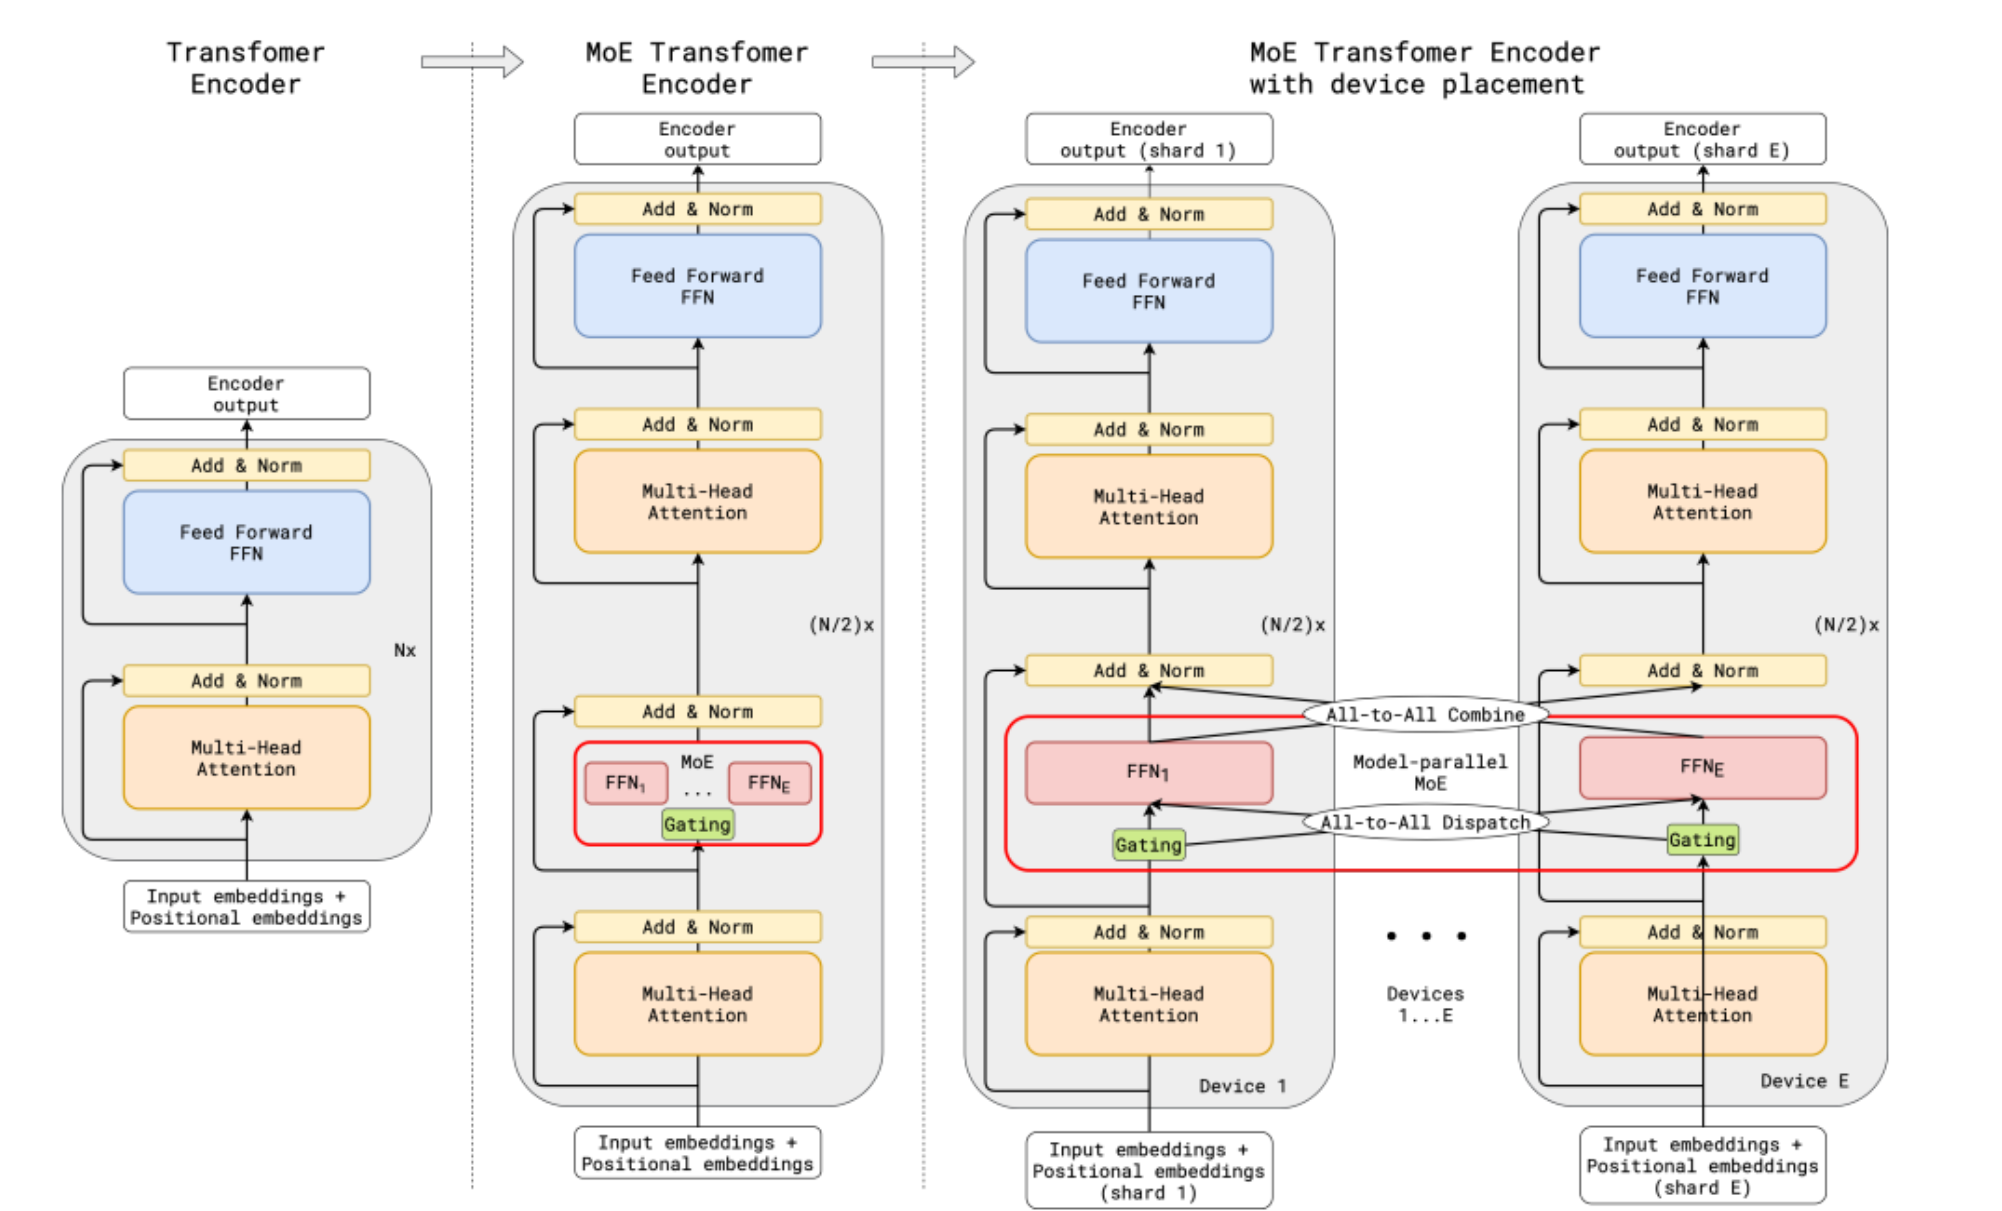

**The Core Concept: Sparsity vs. Density**

In a traditional "Dense" Transformer, every input token must pass through every parameter in the model. In an MoE architecture, the model is Sparse. This means that although the model might have 1 trillion parameters total, it may only use 10 billion parameters to process a single word, making it much faster and cheaper to run than a dense model of the same size.

**Key Components of the Architecture**

**A. The Router (Gating Network)**

The Router is the "traffic controller" of the model. When a word (token) arrives at a layer, the Router analyzes it and decides which "Experts" are best suited to handle it.
- Routing Algorithm: Most models use "Top-2" routing (Top-K Routing), where the Router picks the two most relevant experts for each token and ignores the rest.
- Auxiliary Load Balancing: The Router ensures that work is distributed evenly so that one expert doesn't become "overworked" while others sit idle.

**B. The Experts (Specialized FFNs)**

In a standard Transformer, there is one large Feed-Forward Network (FFN) in each layer. In an MoE model, that single FFN is replaced by a collection of multiple smaller, independent FFNs called Experts. Each expert eventually "specializes" during training. For example, one expert might become great at understanding Python code, while another specializes in French grammar or historical facts.The more experts you have, the more "knowledge" the model can store without slowing down the inference speed.

**C. Sparse Layers vs. Dense Layers**

MoE models are typically "Hybrid." Not every part of the model is split into experts.
- Dense Layers: Usually, the Self-Attention mechanism remains dense (shared by all tokens) to maintain a global understanding of the sentence context.
- Sparse Layers: Only the FFN blocks are replaced with the MoE structure. This is where the bulk of the model's parameters reside.

**D. Expert Fusion and Output**

After the selected experts process the token, their outputs are combined using a weighted average based on the confidence scores originally given by the Router.If Expert A was $80\%$ confident and Expert B was $20\%$ confident, their mathematical outputs are blended in that ratio before being passed to the next layer of the Transformer.

## Ministral-3-3B-Instruct

The Ministral-3-3B-Instruct, released by Mistral AI, is part of the "les Ministraux" family. It is a highly optimized, small-form-factor model designed for edge computing and low-latency tasks. Despite its small size of 3 billion parameters, it incorporates advanced architectural features found in much larger models.

### Ministral-3-3B-Instruct Tokenizer

**Tokenizer: BPE Tiktoken**

The Ministral-3-3B-Instruct uses the V3 (Tekken) Tokenizer developed by Mistral AI.
- Type: It is a Byte-Pair Encoding (BPE) tokenizer trained using Tiktoken.
- Vocabulary Size: It features a large vocabulary of 131,072 tokens. This is a significant increase over earlier Mistral models (which used 32,000).
- Efficiency: The Tekken tokenizer is specifically designed to be more efficient for source code and over 100 multilingual languages. It compresses text better than previous versions, meaning the model can "read" more information within the same context window.
- EOS and Padding: The End of Sequence (EOS) token is used to signal the completion of a response. Like other Mistral models, it does not have a dedicated Padding (PAD) token by default in the configuration; when batching, developers typically use the EOS token or a specific unassigned token as a filler to equalize sequence lengths.

In [8]:
# Configuration
MODEL_NAME = "mistralai/Ministral-3-3B-Instruct-2512-BF16"
OUTPUT_DIR = "./ministral-3-3b-lora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization function
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"""<s>[INST] Question: {row['question_title']}
{row['question_body']} [/INST] {row['answer']}</s>"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: mistralai/Ministral-3-3B-Instruct-2512-BF16


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Tokenizer loaded. Vocab size: 131072
Tokenizing training data...
Tokenizing validation data...
Train examples: 765
Validation examples: 51


### Ministral-3-3B-Instruct Model Architecture

The Ministral-3-3B-Instruct is based on a Transformer Decoder-only architecture. It is an autoregressive model, meaning it predicts the next token in a sequence based on the context of all previous tokens.

**Model Architecture**

The model’s 3 billion parameters are structured into a stack of Transformer blocks. The core components that define its performance include:
- Sliding Window Attention (SWA): This is a hallmark of Mistral architectures. Instead of every token looking at every other token in a massive sequence, SWA allows a token to look at a fixed "window" of previous tokens. This reduces computational complexity from $O(n^2)$ to something much more manageable, allowing the model to handle longer sequences with less memory.
- Grouped-Query Attention (GQA): To optimize speed, Ministral-3 uses GQA. This mechanism groups multiple "Query" heads to share a single "Key" and "Value" head. This drastically reduces the size of the KV Cache, making the model incredibly fast during inference on local devices like phones or laptops.
- Rotary Positional Embeddings (RoPE): The model uses RoPE to encode the position of tokens. Rather than adding fixed values to embeddings, RoPE rotates the vectors in a way that preserves relative distance, which helps the model maintain coherence over its 128,000-token context window.
- SwiGLU Activation Function: Used in the feed-forward layers, SwiGLU provides better mathematical "expressivity" than standard activation functions, allowing the 3B model to perform at a level usually expected from 7B or 8B models.
- RMSNorm: The model utilizes Root Mean Square Layer Normalization applied before each sub-layer (Pre-Norm) to ensure numerical stability during the deep processing of data.

### Ministral-3-3B-Instruct PEFT Optimization Configuration

For the Ministral-3-3B-Instruct, this configuration represents a "Pure BF16 LoRA" approach. Unlike previous examples where we used 4-bit compression, this setup prioritizes maximum model quality and training stability over memory savings.

**1. Model Loading (Pure BF16)**

Instead of using a BitsAndBytesConfig, the model is loaded in its native precision.
- `torch_dtype=torch.bfloat16`: This loads the model weights in BrainFloat16. Because Ministral-3 is a 3B parameter model, it only requires about 6GB–7GB of VRAM to load in this format. Since most modern GPUs have 8GB to 12GB+, quantization isn't strictly necessary to fit the model.
- `device_map="auto"`: Automatically distributes the model layers across your available hardware.
- `Mistral3ForConditionalGeneration`: Uses the specific class designed for the Mistral-3 architecture (which includes specialized attention mechanisms like Sliding Window Attention).

**2. LoRA Configuration**

- `r=32`: A slightly lower rank than the 8B models. For a 3B model, a rank of 32 is often the "sweet spot"—it provides enough parameters to learn new tasks without making the adapter so large that it starts to "override" the model's base logic.
- `lora_alpha=64`: Following the standard $2 \times r$ scaling rule, this ensures the adapters have a significant but balanced impact on the final output.
- `target_modules`: By targeting both the Attention (q, k, v, o) and MLP (gate, up, down) layers, you ensure the fine-tuning can modify both the model's conversational style and its factual knowledge.

### Ministral-3-3B-Instruct Model Fine Tuning

In [9]:
# Load model in BF16 (no quantization)
print(f"Loading {MODEL_NAME} in bfloat16...")
model = Mistral3ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# LoRA configuration
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

# Training arguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    logging_steps=10,
    run_name="ministral-3-3b-lora-qa",
    bf16=True,  # since we're loading in bfloat16
    fp16=False,
    gradient_checkpointing=True,
    optim="adamw_8bit",  # very memory efficient; fallback to "adamw_torch" if bitsandbytes not available
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    max_grad_norm=0.5,
    group_by_length=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

# Print summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16: {training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print(f"Learning rate: {training_args.learning_rate}")
print("Starting training...")

# Train
trainer.train()

# Save
trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Loading mistralai/Ministral-3-3B-Instruct-2512-BF16 in bfloat16...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 67,502,080 || all params: 3,916,592,128 || trainable%: 1.7235
Total parameters: 3,916,592,128
Trainable parameters (LoRA): 67,502,080
Effective batch size: 32
BF16: True
Gradient checkpointing: True
Optimizer: OptimizerNames.ADAMW_8BIT
Learning rate: 2e-05
Starting training...


Epoch,Training Loss,Validation Loss
1,2.659629,2.516064
2,1.946124,2.439904
3,1.693925,2.465994


('./ministral-3-3b-lora-finetuned-qa/tokenizer_config.json',
 './ministral-3-3b-lora-finetuned-qa/chat_template.jinja',
 './ministral-3-3b-lora-finetuned-qa/tokenizer.json')

In [10]:
# Results
print("\n" + "=" * 60)
print("TRAINING RESULTS")
print("=" * 60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Mem (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print("\nPer-epoch results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(e['time'] for e in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data)
    avg_mem = sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data)

    print(f"\nTotal training time: {total_time:.1f} s")
    print(f"Average epoch time: {avg_time:.1f} s")
    print(f"Average CPU usage: {avg_cpu:.1f}%")
    print(f"Average memory usage: {avg_mem:.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Per-epoch results:
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Mem (%)
     0         2.516064 80.150058     18.97625     9.096250
     1         2.439904 80.931218     17.32963     9.230864
     2         2.465994 80.823457     17.39500     9.238750

Total training time: 241.9 s
Average epoch time: 80.6 s
Average CPU usage: 17.9%
Average memory usage: 9.2%

Training completed.


## DeepSeek-V2-Lite

The DeepSeek-V2-Lite model is a highly efficient, small-scale version of the DeepSeek-V2 series. It is a Mixture-of-Experts (MoE) model that punches far above its weight class by using innovative attention and expert-routing mechanisms.

### DeepSeek-V2-Lite Tokenizer

**Tokenizer: Byte-Pair Encoding (BPE)**

DeepSeek-V2-Lite uses a Byte-Pair Encoding (BPE) tokenizer that is highly optimized for multilingual performance, particularly for English and Chinese, as well as programming code.
- Vocabulary Size: It features a vocabulary of 102,400 tokens.
- Efficiency: The tokenizer is designed to maximize the compression ratio, allowing the model to process more information within its context window compared to standard GPT-2 style tokenizers.
- Special Tokens: It includes standard control tokens for identifying the end of a string and managing conversational roles (System, User, Assistant).
- EOS and Padding: The End-of-Sequence (EOS) token is used to tell the model when to stop generating. Like many modern models, it does not have a unique, hard-coded padding token; the EOS token is typically repurposed as a padding token during training and inference to align sequences in a batch.

In [10]:
# Patch for Transformers 5.0.0+ compatibility
if not hasattr(transformers.utils.import_utils, "is_torch_fx_available"):
    def is_torch_fx_available():
        return True
    
    transformers.utils.import_utils.is_torch_fx_available = is_torch_fx_available
    # Also inject into the main transformers namespace just in case
    transformers.is_torch_fx_available = is_torch_fx_available
    print("Bridge: is_torch_fx_available injected for Transformers")

Bridge: is_torch_fx_available injected for Transformers


In [8]:
# Configuration
MODEL_NAME = "deepseek-ai/DeepSeek-V2-Lite" 
OUTPUT_DIR = "./deepseek-v2-lite-lora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        # Simple format without chat template
        text = f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}"
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading tokenizer: deepseek-ai/DeepSeek-V2-Lite
Tokenizer loaded. Vocab size: 100002
Tokenizing training data...
Tokenizing validation data...
Train examples: 763
Validation examples: 68


### DeepSeek-V2-Lite Model Architecture

The architecture of DeepSeek-V2-Lite is a MoE (Mixture-of-Experts) Decoder-only Transformer. It is specifically defined by two groundbreaking architectural choices:Multi-head Latent Attention (MLA) and DeepSeekMoE.

**Model Architecture: Multi-head Latent Attention & MoE**

The model consists of several stacked Transformer blocks, but the internal "organs" of these blocks are different from traditional models:
- Multi-head Latent Attention (MLA): This is the most distinct part of the model. In standard models, the "KV Cache" (the memory used to store past words) grows very large and slows down the model. MLA compresses the Keys ($K$) and Values ($V$) into a low-dimensional "latent vector." This allows the model to have a very large context window while using a tiny fraction of the memory usually required.
- DeepSeekMoE (Mixture-of-Experts): Instead of one giant dense layer, the feed-forward section is split into many small "experts." For any given word, only a few of these experts are "activated."
    - Shared Experts: Some experts are always active to capture general knowledge.
    - Routed Experts: Other experts are specialized and only turn on when the model needs specific knowledge (like math or coding).
- Rotary Positional Embeddings (RoPE): It uses RoPE to handle token positioning, allowing the model to understand the relative distance between tokens across its context length.
- RMSNorm: Root Mean Square Layer Normalization is used for numerical stability, applied before the attention and MoE blocks.

**How the Architecture Works**

The model functions through a highly optimized "sparse" execution pipeline:

**1. Latent Compression (The MLA Step)**

When a prompt enters the model, the Multi-head Latent Attention doesn't store the full Key and Value matrices for every word. Instead, it compresses them into a small latent bottleneck. When the model needs to "remember" a previous word, it up-projects that small vector back into the full attention space. This makes the model incredibly fast and memory-efficient during long conversations.

**2. Sparse Routing (The MoE Step)**

After the attention mechanism gathers context, the data moves to the DeepSeekMoE layer. A "router" looks at the current token and decides which specialists are best equipped to handle it. For example, if the token is part of a Python function, the router sends it to the "coding" experts. Because only a small percentage of total parameters are "awake" at any one time, the model behaves like a much larger model while using the energy and speed of a small one.

**3. Next-Token Prediction**

After passing through the layers, the model generates a probability distribution over its 102,400-token vocabulary. It selects the most likely next token, appends it to the sequence, and repeats. Because of the MLA architecture, even as the conversation gets very long, the model doesn't slow down as much as traditional Transformers would.

### DeepSeek-V2-Lite PEFT Optimization Configuration

For the DeepSeek-V2-Lite, which is a Mixture-of-Experts (MoE) model, your configuration reflects a highly stabilized "Native Precision" approach. Because MoE models have unique routing logic and sparse activations, they are more sensitive to the "noise" introduced by quantization than standard dense models (like Llama or Mistral).

**1. Model Loading (Direct to CUDA in BF16)**

Unlike standard models, you are forcing the loading directly to a single device in BrainFloat16.
- `dtype=torch.bfloat16`: DeepSeek-V2-Lite is a 16B parameter model total, but it only activates 2.4B parameters per token. Despite the 16B size, the full model in BF16 requires about 32GB of VRAM. This allows it to fit on a single 40GB or 80GB A100/H100/A6000 without needing to compress the weights to 4-bit.
- `device_map={"": device}`: By mapping the entire model to one device and bypassing auto, you avoid the "meta device" or "split-layer" bugs that often plague complex MoE architectures during the initialization of custom remote code.
- `trust_remote_code=True`: Essential for DeepSeek models because they use Multi-head Latent Attention (MLA) and DeepSeekMoE, which are not yet part of the standard Hugging Face transformers core library.

**2. LoRA Configuration (MoE Specialization)**

- `r=8`: You are using a lower rank than usual. This is a "safety first" move. MoE models can be prone to routing instability—if the adapters change the weights too drastically, the model might start sending tokens to the "wrong" experts, causing the model to generate gibberish.
- `target_modules`: You are targeting both the Attention and the MLP (Experts).
- Attention (`q, k, v, o`): Adjusts how the model focuses on context.
- MLP (`gate, up, down`): These modules in DeepSeek-V2-Lite represent the Experts. By targeting these, you are essentially fine-tuning the specialized knowledge "experts" within the MoE structure.

**Why avoid BitsAndBytes (4-bit/8-bit)?**

While bitsandbytes is great for saving memory, there are three specific reasons to skip it for DeepSeek-V2-Lite:
- MLA Sensitivity: DeepSeek uses Multi-head Latent Attention (MLA), which compresses Key-Value (KV) caches into a latent vector. This compression is mathematically delicate. 4-bit quantization (NF4) can distort these latent vectors, leading to a significant drop in reasoning and coding performance compared to BF16.
- Expert Precision: In an MoE model, each expert is responsible for a niche set of knowledge. Quantizing a "sparse" model can sometimes "kill" specific experts if their weights are pushed into a zero-bin during 4-bit rounding, leading to "dead experts" that never get activated.
- VRAM vs. Complexity: Since DeepSeek-V2-Lite only needs approx. 32GB, and most people fine-tuning this model are using 40GB+ cards, the "cost" of quantization (slower training and potential accuracy loss) outweighs the memory benefit.

**Why use only LoRA for optimization?**

- Routing Stability: Full fine-tuning of an MoE model is notoriously difficult. If you update all 16B parameters, the "Router" (the part of the model that decides which expert to use) can become uncalibrated. LoRA keeps the Router stable while the adapters learn the task.
- Handling Sparsity: DeepSeek-V2-Lite has 64 routed experts. Training all of them at once requires massive gradient storage. LoRA allows you to train the "essence" of the experts without the massive overhead of full-gradient updates for 64 different FFN blocks.

In [ ]:
# Load base model without quantization - force all parameters to CUDA
print(f"Loading {MODEL_NAME}...")

# Check CUDA availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load model with explicit device mapping to avoid meta device issues
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.bfloat16,  # Use dtype instead of torch_dtype
    device_map={"": device},  # Force all layers to the same device
    trust_remote_code=True,
    offload_folder="offload", 
)

# Ensure all parameters are on the correct device
model = model.to(device)
print(f"Model loaded on {device}")

# LoRA configuration - only target attention layers for stability
lora_config = LoraConfig(
    r=8,  
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],  # Only target key attention layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Check BF16 support
bf16_supported = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
print(f"BF16 supported: {bf16_supported}")

# Calculate warmup steps
total_steps = len(dataset_dict["train"]) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps) * training_args.num_train_epochs
warmup_steps = int(total_steps * 0.1)  # 10% warmup

# Training arguments - adjusted for MoE model
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    logging_steps=10,
    run_name="deepseek-v2-lite-lora-qa",
    bf16=bf16_supported,
    fp16=not bf16_supported and device == "cuda",
    gradient_checkpointing=True,
    optim="adamw_torch",
    warmup_steps=warmup_steps,  # Use warmup_steps instead of warmup_ratio
    lr_scheduler_type="cosine",
    max_grad_norm=0.5,  # Lower for MoE stability
    group_by_length=False,  # Disable for MoE models
    ddp_find_unused_parameters=False,
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

# Summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTraining Configuration:")
print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.4f}%")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16 enabled: {training_args.bf16}")
print(f"FP16 enabled: {training_args.fp16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Warmup steps: {training_args.warmup_steps}")
print("Starting training...\n")

# Train
train_result = trainer.train()

# Save model
trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModel saved to {OUTPUT_DIR}")

In [ ]:
# Results summary
print("\n" + "=" * 60)
print("TRAINING RESULTS")
print("=" * 60)

log_history = trainer.state.log_history
validation_losses = [log.get('eval_loss', None) for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    
    # Find training loss for this epoch
    epoch_train_losses = []
    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            if int(log['epoch']) == int(epoch['epoch']):
                epoch_train_losses.append(log['loss'])
    
    train_loss = sum(epoch_train_losses) / len(epoch_train_losses) if epoch_train_losses else None
    
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': f"{val_loss:.4f}" if val_loss is not None else "N/A",
        'Time (s)': f"{epoch['time']:.1f}",
        'Avg CPU (%)': f"{epoch['avg_cpu']:.1f}",
        'Avg Mem (%)': f"{epoch['avg_memory']:.1f}"
    })

results_df = pd.DataFrame(results_data)
print("\nPer-epoch results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(float(e['time']) for e in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(float(e['avg_cpu']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    avg_mem = sum(float(e['avg_memory']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"\nSummary Statistics:")
    print(f"Total training time: {total_time:.1f} seconds")
    print(f"Average epoch time: {avg_time:.1f} seconds")
    print(f"Average CPU usage: {avg_cpu:.1f}%")
    print(f"Average memory usage: {avg_mem:.1f}%")
    
    # Display final metrics
    if hasattr(train_result, 'metrics') and train_result.metrics:
        print(f"\nFinal Training Metrics:")
        for key, value in train_result.metrics.items():
            print(f"{key}: {value:.4f}")

print("\nTraining completed.")

## AI21-Jamba2-3B

The AI21-Jamba2-3B model is a high-performance, ultra-compact model released by AI21 Labs. It is built on a "Jamba" hybrid architecture that merges the best of two worlds: the reasoning power of Transformers and the massive efficiency of State-Space Models (SSMs).

### AI21-Jamba2-3B Tokenizer

The Jamba2 series uses a highly efficient, custom tokenizer designed to reduce costs and improve sequence compression.
- Vocabulary Size: It features a vocabulary of 64,000 tokens.
- Multilingual Support: The tokenizer is optimized for 9 languages: English, Spanish, French, Portuguese, Italian, Dutch, German, Arabic, and Hebrew.
- Compression Efficiency: It is designed to be roughly 30 percent more efficient than many comparable models, often mapping roughly one token to one English word or six characters. This means you can fit more "actual" text into the model's context window compared to standard tokenizers.
- Special Tokens: It includes standard control tokens, such as `<|endoftext|>` (EOS), though it notably does not have a dedicated padding token by default (often requiring the EOS token to be used for padding during batch inference).

In [ ]:
# Required environment for this model
%%capture
!pip install mamba-ssm

In [8]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Configuration
MODEL_NAME = "ai21labs/AI21-Jamba2-3B"
OUTPUT_DIR = "./jamba2-3b-qlora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        # Simple format for Jamba2
        text = f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}"
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: ai21labs/AI21-Jamba2-3B


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/895 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Tokenizer loaded. Vocab size: 65536
Tokenizing training data...
Tokenizing validation data...
Train examples: 710
Validation examples: 40


### AI21-Jamba2-3B Model Architecture

**Model Architecture: The Jamba Hybrid**

The architecture of Jamba2-3B is a Hybrid SSM-Transformer Decoder-only model. Unlike standard models like GPT-4 or Llama, which are "Transformer-only," Jamba uses a mix of layers.

The model consists of 28 total layers, organized in a specific ratio of Mamba blocks to Attention blocks.

- Mamba Layers (State-Space Models): These make up the vast majority of the model (26 out of 28 layers). These layers excel at processing sequences linearly, meaning they don't slow down or consume massive amounts of memory as the text gets longer.
- Transformer Attention Layers: Two specific layers (typically at the 4th and 18th positions) are standard Transformer self-attention blocks. These provide the model with "long-range reasoning" capabilities that pure SSMs sometimes struggle with.
- Mixture-of-Experts (MoE): The model also utilizes MoE in its Feed-Forward Networks (FFN). Instead of every part of the model being active for every word, it "routes" information to the most relevant sub-experts, which allows it to have 3.4B total parameters while only using a fraction of that during actual computation.
- Long Context Window: Due to the memory-efficient Mamba layers, the model supports a massive 256K token context window.

**How the Architecture Works**

The Jamba architecture is often described as a "Hybrid Car"—using "electric" Mamba for efficiency and "gas" Transformers for power.

1. Linear Scaling (The Mamba Advantage) In a regular Transformer, every word has to "look back" at every other word, which creates a massive memory table called the KV Cache. As the conversation grows, this table becomes too big for most devices. Jamba’s Mamba layers process text like a stream; they keep a small, fixed-size "hidden state" that updates as it reads. This allows the model to handle 256,000 tokens on a standard laptop or phone that would usually crash with a 32,000-token Transformer.

2. Global "Anchors" (The Attention Advantage) Because Mamba layers occasionally "forget" very specific details over thousands of pages, the architecture injects Transformer Attention layers at strategic points. These layers act like global checkpoints, allowing the model to "look back" across the entire 256K context at once to find a specific fact (the "needle in a haystack").

3. Efficient Throughput When you give the model a prompt, it passes the data through these interleaved layers. The MoE router ensures that only the necessary "experts" are firing, keeping the processing speed high. Because the memory footprint of the KV Cache is reduced by roughly 8x compared to a pure Transformer of the same size, Jamba2-3B can generate text 2 to 5 times faster than its competitors while fitting into smaller hardware.

### AI21-Jamba2-3B QAT and PEFT Optimization Configuration

This configuration sets up QLoRA for the AI21-Jamba-1.5-Mini (the 3B-class model using the Jamba-2 architecture). Jamba is a Hybrid Transformer-Mamba model, which is fundamentally different from the standard Transformer-only models you've likely used. This setup focuses on managing the unique requirements of State Space Models (SSM) mixed with Attention.

**1. Disabling Mamba Kernels**

- `config.use_mamba_kernels = False`: This is a critical technical requirement for fine-tuning. Fast CUDA kernels for Mamba are highly optimized for inference speed but often do not support the backward pass (gradient calculation) required for training. By disabling them, you force the model to use the standard PyTorch implementation, which is compatible with LoRA gradients.

**2. 4-bit Quantization (BitsAndBytes)**

Even though this is a 3B model, quantization is vital because of Jamba-2's massive 256k context window.
- `load_in_4bit=True`: Shrinks the model weights to about 2.5GB–3GB of VRAM.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is essential here. Because Mamba layers process information sequentially, they are sensitive to weight outliers. NF4 captures these better than standard 4-bit integers.
- `bnb_4bit_use_double_quant=True`: Quantizes the quantization constants. While it only saves a few hundred MBs, that extra space is crucial for the "Mamba State" and "KV Cache" needed to process long documents.
- `bnb_4bit_compute_dtype=torch.bfloat16`: Jamba was natively trained in BrainFloat16. Keeping the compute type consistent ensures that the "handshake" between the Mamba blocks and Attention blocks stays numerically stable.

**3. LoRA Configuration (The Attention Focus)**

In this configuration, you are specifically targeting the Transformer components rather than the Mamba or MoE (Mixture-of-Experts) components.
- `r=16`: A conservative rank. Since Jamba is a hybrid model, a smaller rank prevents the adapters from "overpowering" the delicate balance between the sequence-tracking Mamba layers and the context-focusing Attention layers.
- `target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]`:
    - Jamba-2 uses MoE in its MLP layers and Mamba layers for linear recurrence.
    - This config chooses to only update the Attention layers. This is the safest way to fine-tune Jamba because it improves the model's ability to "retrieve" specific facts from its context window without disrupting the internal logic of the Mamba state tracking.

**Why use BitsAndBytes for Jamba-2-3B?**

- Context Headroom: Training a model on 32k or 64k tokens requires immense VRAM for activations. 4-bit quantization isn't just about fitting the model; it's about making room for the data.
- Hybrid Complexity: Managing gradients for a hybrid architecture is memory-intensive. Quantization provides a safety buffer against Out-of-Memory (OOM) errors during the backward pass.

**Why use "Only LoRA"?**

- Stability: Hybrid architectures can be prone to "mode collapse" during full fine-tuning. LoRA acts as a constraint that keeps the core logic of the model intact.
- Speed: Because Jamba-2-3B uses MoE for some layers, full fine-tuning would require calculating gradients for many experts that might not even be used in every step. LoRA on the attention blocks is significantly faster and more direct.

In [9]:
# Load config and disable Mamba kernels
print("Loading model configuration...")
config = AutoConfig.from_pretrained(MODEL_NAME)
config.use_mamba_kernels = False  # Disable fast Mamba kernels
print(f"Mamba kernels disabled: {not config.use_mamba_kernels}")

# Quantization config
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

# Load model with disabled Mamba kernels
print(f"Loading {MODEL_NAME} with 4-bit quantization (Mamba kernels disabled)...")
#try:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,  # Pass the modified config
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
print("Model loaded successfully with quantization.")

# Prepare for QLoRA if using quantization
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
print("Model prepared for k-bit training.")

# LoRA configuration for Jamba2
# Jamba2 has attention layers and Mamba layers - target attention layers
lora_config = LoraConfig(
    r=16,  # Lower rank for 3B model
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Only target attention layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading model configuration...
Mamba kernels disabled: True
Loading ai21labs/AI21-Jamba2-3B with 4-bit quantization (Mamba kernels disabled)...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

The fast path is not available because on of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. To install follow https://github.com/state-spaces/mamba/#installation and https://github.com/Dao-AILab/causal-conv1d. If you want to use the naive implementation, set `use_mamba_kernels=False` in the model config


Loading weights:   0%|          | 0/463 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Model loaded successfully with quantization.
Model prepared for k-bit training.
trainable params: 499,712 || all params: 3,197,609,344 || trainable%: 0.0156


### AI21-Jamba2-3B Model Fine Tuning

In [10]:
# Data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

bf16_supported = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
print(f"BF16 supported: {bf16_supported}")

# Training arguments optimized for Jamba2 (hybrid attention-Mamba)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,  # Conservative for hybrid model
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,  # Higher for hybrid model
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="steps",
    logging_steps=10,
    run_name="jamba2-3b-qlora-qa",
    fp16=not bf16_supported,
    bf16=bf16_supported,
    gradient_checkpointing=True,
    optim="adamw_torch",  # Use standard optimizer for better compatibility
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    max_grad_norm=0.5,  # Lower for hybrid model stability
    group_by_length=False,  # Disable for hybrid models
    dataloader_pin_memory=False,
    ddp_find_unused_parameters=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

# Training summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTraining Configuration:")
print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.2f}%")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16 enabled: {training_args.bf16}")
print(f"FP16 enabled: {training_args.fp16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Mamba kernels: {'Enabled' if config.use_mamba_kernels else 'Disabled (using slow path)'}")
print("Starting training...\n")

# Train
train_result = trainer.train()

# Save model
trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModel saved to {OUTPUT_DIR}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


BF16 supported: True

Training Configuration:
Model: ai21labs/AI21-Jamba2-3B
Total parameters: 1,768,433,024
Trainable parameters (LoRA): 499,712
Trainable percentage: 0.03%
Batch size: 4
Gradient accumulation: 8
Effective batch size: 32
BF16 enabled: True
FP16 enabled: False
Gradient checkpointing: True
Optimizer: OptimizerNames.ADAMW_TORCH
Learning rate: 0.0001
Mamba kernels: Disabled (using slow path)
Starting training...



Epoch,Training Loss,Validation Loss
1,2.653067,2.674176
2,2.374234,2.480375
3,2.269021,2.447526



Model saved to ./jamba2-3b-qlora-finetuned-qa


In [11]:
# Results
print("\n" + "=" * 60)
print("TRAINING RESULTS")
print("=" * 60)

log_history = trainer.state.log_history
validation_losses = [log.get('eval_loss', None) for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    
    # Find training loss for this epoch
    epoch_train_losses = []
    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            if int(log['epoch']) == int(epoch['epoch']):
                epoch_train_losses.append(log['loss'])
    
    train_loss = sum(epoch_train_losses) / len(epoch_train_losses) if epoch_train_losses else None
    
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': f"{val_loss:.4f}" if val_loss is not None else "N/A",
        'Time (s)': f"{epoch['time']:.1f}",
        'Avg CPU (%)': f"{epoch['avg_cpu']:.1f}",
        'Avg Mem (%)': f"{epoch['avg_memory']:.1f}"
    })

results_df = pd.DataFrame(results_data)
print("\nPer-epoch results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(e['time'] for e in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data)
    avg_mem = sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"\nSummary Statistics:")
    print(f"Total training time: {total_time:.1f} seconds")
    print(f"Average epoch time: {avg_time:.1f} seconds")
    print(f"Average CPU usage: {avg_cpu:.1f}%")
    print(f"Average memory usage: {avg_mem:.1f}%")
    
    # Display final metrics
    if hasattr(train_result, 'metrics') and train_result.metrics:
        print(f"\nFinal Training Metrics:")
        for key, value in train_result.metrics.items():
            print(f"{key}: {value:.4f}")

print("\nTraining completed successfully!")


TRAINING RESULTS

Per-epoch results:
 Epoch Validation Loss Time (s) Avg CPU (%) Avg Mem (%)
     0          2.6742   2279.4        21.0        10.8
     1          2.4804   2279.1        19.9        10.9
     2          2.4475   2280.6        21.2        10.9

Summary Statistics:
Total training time: 6839.1 seconds
Average epoch time: 2279.7 seconds
Average CPU usage: 20.7%
Average memory usage: 10.8%

Final Training Metrics:
train_runtime: 6850.4592
train_samples_per_second: 0.3110
train_steps_per_second: 0.0100
total_flos: 4956328859074560.0000
train_loss: 2.4484
epoch: 3.0000

Training completed successfully!


## Phi-3.5-MoE-instruct

The Microsoft Phi-3.5-MoE-instruct is a "Small Language Model" (SLM) that punches far above its weight by using a Mixture-of-Experts architecture. It is designed to provide reasoning capabilities comparable to much larger models while maintaining the speed and efficiency of a smaller one.

### Phi-3.5-MoE-instruct Tokenizer

The Phi-3.5-MoE uses the Llama-2 tokenizer style, which is a Byte-Pair Encoding (BPE) tokenizer.
- Vocabulary Size: It features a vocabulary of 32,064 tokens.
- Design Choice: By using a vocabulary similar to the Llama family, Microsoft ensures high compatibility with existing open-source tools and optimization libraries.
- EOS and Padding: The End of Sequence (EOS) token is used to tell the model exactly where a response should terminate. For Padding (PAD), the model typically does not have a unique dedicated padding token; instead, the EOS token is repurposed to fill out batches so that all sequences in a single GPU calculation are the same length.

In [8]:
# Configuration
MODEL_NAME = "microsoft/Phi-3.5-MoE-instruct"
OUTPUT_DIR = "./phi-3.5-moe-lora-finetuned-qa"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Phi-3.5-MoE uses specific chat format tokens
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization function - using Phi-3.5-MoE chat format
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        # Use Phi-3.5-MoE chat format as per documentation
        text = f"""<|system|>
You are a helpful AI assistant for question answering.<|end|>
<|user|>
Question: {row['question_title']}
{row['question_body']}<|end|>
<|assistant|>
{row['answer']}<|end|>"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: microsoft/Phi-3.5-MoE-instruct


config.json: 0.00B [00:00, ?B/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='longrope': {'short_mscale', 'long_mscale'}
This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

Tokenizer loaded. Vocab size: 32011
Tokenizing training data...
Tokenizing validation data...
Train examples: 739
Validation examples: 48


### Phi-3.5-MoE-instruct Model Architecture

The Phi-3.5-MoE-instruct utilizes a Sparse Mixture-of-Experts architecture. Unlike "dense" models where every single parameter is used for every word, an MoE model only activates a small portion of its brain at any given time.

**Model Architecture: Mixture-of-Experts (MoE)**

While the model has 16.7 billion total parameters, it only uses about 3.8 billion active parameters per token. Its structure consists of:

- 32 Transformer Layers: The model is built from 32 sequential blocks that process information.
- Experts and Routing: Instead of one large feed-forward network in each layer, there are 16 distinct "experts." A specialized "router" decides which 2 experts are the most qualified to handle each specific token.
- Grouped-Query Attention (GQA): To handle its massive 128,000-token context window, it uses GQA. This allows the model to share "Key" and "Value" information across multiple "Query" heads, significantly reducing the memory required to remember long documents.
- RoPE (Rotary Positional Embeddings): This is used to encode the position of words. It allows the model to understand the relationship between tokens even when they are 100,000 words apart.
- RMSNorm: This normalization technique is applied before each layer to keep the mathematical values stable and prevent them from becoming too large or small during deep processing.

**How the Architecture Works?**

The magic of Phi-3.5-MoE lies in its ability to be "smart yet light" through a process called Conditional Computation.

**1. Tokenization and Routing**

When you type a sentence, the tokenizer breaks it into IDs. As each ID moves through the 32 layers, it hits a "Router." The router acts like a traffic controller; it looks at the word (e.g., a word about "quantum physics") and sends it to the two experts in that layer that have "studied" physics during training.

**2. Sparse Execution**

Because only 2 out of the 16 experts are "turned on" for any given word, the computer only has to do the math for 3.8 billion parameters. This makes the model feel as fast as a 4B model, but because it has 16B parameters of total "knowledge" to draw from, its answers are much more sophisticated.

**3. Attention and Context**

While the experts handle the logic, the Grouped-Query Attention ensures the model remembers the beginning of your prompt. It calculates how much focus to put on previous words using the scaled dot-product attention formula:$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$This allows the model to maintain the thread of a very long conversation or analyze a massive PDF file without losing its place.

**4. Output Generation**

After the 32nd layer, the final data is projected back to the vocabulary. The model predicts the next word, adds it to the prompt, and repeats the cycle. The use of SwiGLU activation within the experts further refines this prediction, ensuring high accuracy in reasoning and logic tasks.

### Phi-3.5-MoE-instruct PEFT Optimization Configuration

This configuration sets up a Native Precision LoRA for the Phi-3.5-MoE-instruct model. This is a highly sophisticated Mixture-of-Experts (MoE) model that has a total of 16 experts, with 2 experts active per token. While the total parameter count is about 42B, only 6.6B are used for computation at any given time.

**1. Model Loading (Pure BF16)**

In this setup, you are bypassing 4-bit quantization in favor of maximum accuracy and architectural stability.
- `torch_dtype=torch.bfloat16`: Phi-3.5-MoE was trained on bfloat16. Since MoE models rely on a "Router" to send information to the right experts, keeping the weights in their native 16-bit precision ensures the Router remains highly accurate.
- `device_map={"": device}`: MoE models have a massive memory footprint even if their "active" parameters are low. Phi-3.5-MoE requires roughly 80GB+ of VRAM to load in BF16. By forcing it to a single device (or specific devices), you avoid the communication overhead and potential bugs that occur when MoE layers are split across too many GPUs.
- `trust_remote_code=False`: Unlike many MoE models (like DeepSeek or Qwen), Microsoft has integrated the Phi-3.5 architecture directly into the transformers library, making it more secure and easier to maintain.

**2. LoRA Configuration (The Sparse Strategy)**

This config is intentionally "light" to protect the complex MoE internal logic.
- `r=16`: You are using a relatively low rank. In MoE models, the "knowledge" is spread across 16 different experts. A lower rank ensures that your fine-tuning doesn't cause the model to "collapse" into using only one or two experts for everything (a common failure in MoE fine-tuning).
- `lora_alpha=32`: Following the $2 \times r$ rule, this provides a moderate signal strength for your new data.
- `target_modules=["q_proj", "v_proj"]` : 
    - In Phi-3.5-MoE, the Attention layers are shared across all experts, while the FFN layers are the experts.
    - By only targeting q_proj and v_proj, you are fine-tuning the model's "contextual focus"—essentially teaching it how to read your data—without modifying the factual knowledge stored in the 16 specialized experts. This is the safest way to fine-tune an MoE without breaking its brain.
    
**Why skip BitsAndBytes (4-bit/8-bit)?**

- Router Precision: In an MoE model, the Router makes a mathematical decision for every single token. If you quantize the model to 4-bit, the "signal-to-noise" ratio in the Router can degrade, causing it to send tokens to the wrong experts, which leads to incoherent output.
- MoE "Dead Expert" Risk: Quantization can occasionally zero out weights in smaller, sparse layers. In a dense model, this is fine; in an MoE model, this could effectively "kill" one of the 16 experts, removing a chunk of the model's specialized knowledge.
- High-End Hardware: If you are running Phi-3.5-MoE (42B total params), you are likely using an A100 (80GB) or an H100. Since the model fits on these cards in BF16, there is no need to sacrifice the speed and accuracy of native precision.

**Why use "Only LoRA"?**

- Efficiency at Scale: Fully fine-tuning a 42B parameter MoE model is computationally massive. It would require hundreds of gigabytes of VRAM just to store the optimizer states. LoRA allows you to achieve instruction-following performance by updating less than 0.1 percent of the total parameters.
- Expert Balance: If you updated all the experts (FFN layers) during fine-tuning, you would likely overfit to your specific dataset, and the model would lose its "generalist" abilities. LoRA on the attention layers keeps the experts' pre-trained knowledge intact while adapting the model's behavior.

In [ ]:
# Load model - Note: Phi-3.5-MoE is actived with 6.6B parameters
print(f"Loading {MODEL_NAME}...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load MoE model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map={"": device},  # MoE models work better with explicit device mapping
    trust_remote_code=False,  # Phi-3.5-MoE doesn't require trust_remote_code
)

# Ensure model is on correct device
model = model.to(device)
print(f"Model loaded on {device}")

# LoRA configuration for MoE model
# Target the shared attention layers
lora_config = LoraConfig(
    r=16,  # Lower rank for MoE stability
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # Target key attention projections
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

### Phi-3.5-MoE-instruct Model Fine Tuning

In [ ]:
# Data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Check BF16 support
bf16_supported = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
print(f"BF16 supported: {bf16_supported}")

# Training arguments - adjusted for MoE model
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=1,  # Smaller batch for MoE
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    logging_steps=10,
    run_name="phi-3.5-moe-lora-qa",
    bf16=bf16_supported,
    fp16=not bf16_supported and device == "cuda",
    gradient_checkpointing=True,
    optim="adamw_torch",  # Use standard optimizer for MoE
    warmup_steps=100,  # Fixed warmup steps
    lr_scheduler_type="cosine",
    max_grad_norm=0.5,  # Lower grad norm for MoE stability
    group_by_length=False,  # Disable for MoE models
    ddp_find_unused_parameters=False,
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

# Print summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTraining Configuration:")
print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Trainable percentage: {trainable_params/total_params*100:.4f}%")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16 enabled: {training_args.bf16}")
print(f"FP16 enabled: {training_args.fp16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Warmup steps: {training_args.warmup_steps}")
print("Starting training...\n")

# Train
trainer.train()

# Save
trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModel saved to {OUTPUT_DIR}")

In [ ]:
# Results
print("\n" + "=" * 60)
print("TRAINING RESULTS")
print("=" * 60)

log_history = trainer.state.log_history
validation_losses = [log.get('eval_loss', None) for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    
    # Find training loss for this epoch
    epoch_train_losses = []
    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            if int(log['epoch']) == int(epoch['epoch']):
                epoch_train_losses.append(log['loss'])
    
    train_loss = sum(epoch_train_losses) / len(epoch_train_losses) if epoch_train_losses else None
    
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Train Loss': f"{train_loss:.4f}" if train_loss is not None else "N/A",
        'Val Loss': f"{val_loss:.4f}" if val_loss is not None else "N/A",
        'Time (s)': f"{epoch['time']:.1f}",
        'Avg CPU (%)': f"{epoch['avg_cpu']:.1f}",
        'Avg Mem (%)': f"{epoch['avg_memory']:.1f}"
    })

results_df = pd.DataFrame(results_data)
print("\nPer-epoch results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(float(e['time']) for e in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(float(e['avg_cpu']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    avg_mem = sum(float(e['avg_memory']) for e in monitor.epoch_data) / len(monitor.epoch_data)

    print(f"\nSummary Statistics:")
    print(f"Total training time: {total_time:.1f} s")
    print(f"Average epoch time: {avg_time:.1f} s")
    print(f"Average CPU usage: {avg_cpu:.1f}%")
    print(f"Average memory usage: {avg_mem:.1f}%")

    # Display final metrics
    if hasattr(trainer, 'state') and trainer.state.log_history:
        print(f"\nFinal Training Loss: {trainer.state.log_history[-1].get('loss', 'N/A'):.4f}")
        if validation_losses:
            print(f"Final Validation Loss: {validation_losses[-1]:.4f}")

print("\nTraining completed.")

# Large Reasoning Model (LRM)

Large Reasoning Models (LRMs) are designed for multi-step reasoning — going beyond text prediction to logical, mathematical, or analytical thinking.

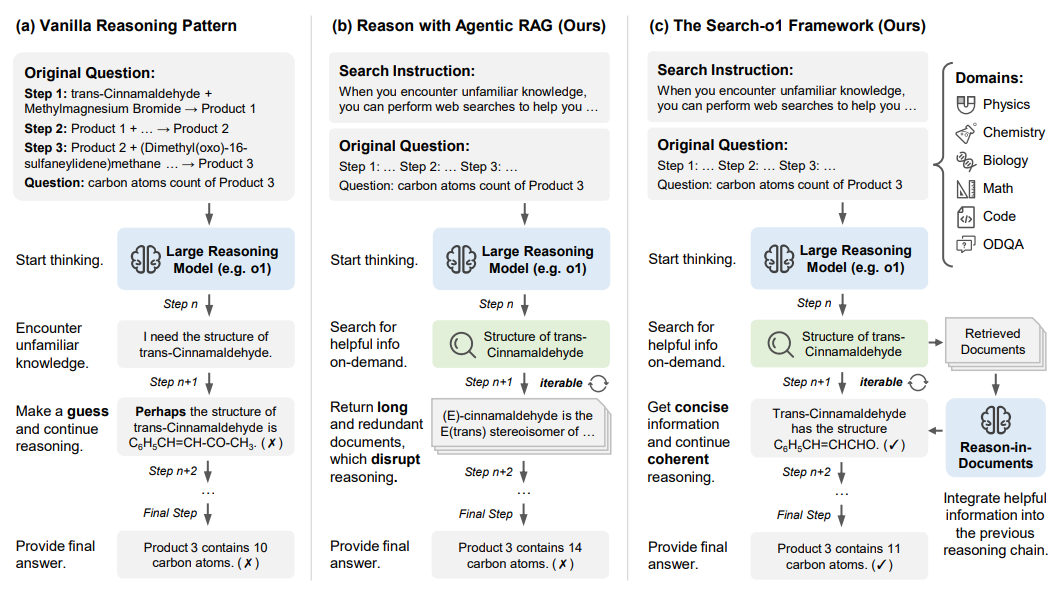

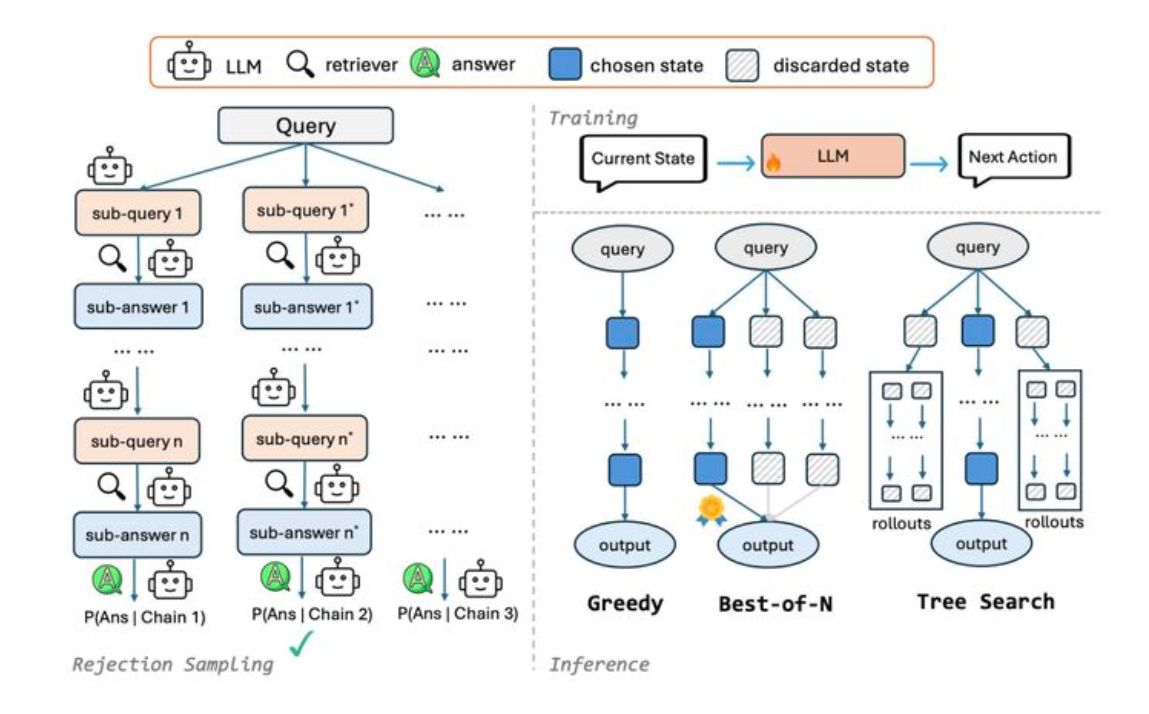

**LRM (Large Reasoning Model)**

Large Reasoning Models (LRMs) are a new class of AI models designed to move beyond the rapid "pattern matching" of standard LLMs. While traditional models like GPT-4 operate on "System 1" thinking (fast and intuitive), LRMs are built for "System 2" thinking—slow, deliberate, and logical. Notable examples include OpenAI’s o1 and DeepSeek-R1.

**The Architecture: Inference-Time Compute Scaling**

Standard LLMs use a fixed amount of computation per token regardless of the question's difficulty. LRMs shift the intelligence from the training phase to the inference phase. By generating a long, internal Chain of Thought (CoT) before arriving at a conclusion, the model "scales" its intelligence by spending more time (and tokens) thinking through complex problems.

**Key Components of the Architecture**

**A. Hidden Chain of Thought (CoT)**

The defining feature of an LRM is its ability to generate an internal monologue. Unlike standard prompts where you might ask a model to "think step by step," LRMs are natively trained to do this.
- Self-Correction: During this process, the model can catch its own logical errors and backtrack to try a different path.
- Search and Simulation: The model essentially performs a "mental" search, weighing different approaches to a math or coding problem before presenting the final answer to the user.

**B. Process-Based Reward Models (PRM)**

Standard models are usually trained with Outcome-Based Rewards (is the final answer right or wrong?). LRMs utilize Process Reward Models, which provide a mathematical "reward" for every single correct step in a reasoning chain. This prevents the model from getting the right answer for the wrong reasons (hallucinated logic).

**C. Reinforcement Learning (RL) and Verifiable Environments**

LRMs are primarily refined through massive-scale Reinforcement Learning. LRMs rely heavily on large-scale Reinforcement Learning. They are "punished" for logical leaps and "rewarded" for sound reasoning. In domains like math or coding, the model can practice against a Verifiable Environment (e.g., a code compiler or math checker) to verify its own steps without human intervention, allowing it to "teach itself" to reason more effectively.

**D. Test-Time Scaling Laws**

In standard GPT models, performance is mostly determined by how many parameters the model has (model size). In LRMs, performance is a function of Inference-Time Compute. This means a smaller model that "thinks" for 20 seconds can often outperform a massive model that answers in 1 second.

## Qwen3-4B-Thinking-2507

The Qwen3-4B-Thinking-2507 is a specialized "reasoning" model from Alibaba Cloud. While it shares the name of the Qwen3 family, the "Thinking" designation indicates it is fine-tuned for Chain-of-Thought (CoT) processing—meaning it is designed to "think" through complex problems internally before providing a final answer.

### Qwen 3 Thinking Toknizer

**Tokenizer: Tiktoken-based BPE**

The Qwen3-4B-Thinking model utilizes the standard Qwen3 Tiktoken-based Byte-Pair Encoding (BPE) tokenizer.
- Vocabulary Size: It features an expansive vocabulary of 151,936 tokens. This large size is a hallmark of the Qwen series, allowing it to represent diverse languages (especially East Asian languages) and technical code much more efficiently than models with smaller vocabularies.
- EOS (End of Sequence): The model uses <|endoftext|> as its primary EOS token. However, for the "Thinking" variant, it often utilizes specific control tokens like <|thought|> and </|thought|> (or similar internal markers) to delineate where its internal reasoning begins and ends.
- Padding (PAD): The model does not have a dedicated, unique padding token by default. During batch processing, developers typically use the <|endoftext|> token as a filler to ensure all sequences in a mathematical batch are the same length.

In [8]:
# Configuration
MODEL_NAME = "Qwen/Qwen3-4B-Thinking-2507"          # Use non-FP8 variant for training
OUTPUT_DIR = "./qwen3-4b-thinking-2507-qlora-qa"
MAX_LENGTH = 128

# Load tokenizer & model with 4-bit quantization + LoRA
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization
def tokenize_examples(df):
    texts = [
        f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}{tokenizer.eos_token}"
        for row in df.iter_rows(named=True)
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})

val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Tokenizer loaded: Qwen/Qwen3-4B-Thinking-2507
Vocab size: 151,669
Tokenizing training data...
Tokenizing validation data...
Train examples: 772
Validation examples: 51


### Qwen 3 Thinking Model Architecture

The base architecture is a Dense Decoder-only Transformer. It follows the industry-standard "GPT-style" structure but is optimized for high-speed inference and deep reasoning.

**Model Architecture: Decoder-Only Transformer with Thinking Heads**

The 4-billion parameters are distributed across a stack of layers (typically 24 to 28 layers for the 4B size). The architecture includes:
- Grouped-Query Attention (GQA): To save memory and increase speed, the model uses GQA. This allows multiple "Query" heads to share "Key" and "Value" heads. This is essential for maintaining performance when the model is performing long-winded "thinking" steps.
- RoPE (Rotary Positional Embeddings): This is used to encode the position of tokens. Qwen3-Thinking uses an enhanced version of RoPE that supports long context windows, allowing it to keep track of complex logic over thousands of tokens.
- SwiGLU Activation: The feed-forward layers use SwiGLU, which provides the mathematical "expressivity" needed for the model to handle difficult math and logic puzzles.
- RMSNorm: This is used for "Pre-Normalization," ensuring the numbers flowing through the 4B parameters stay mathematically stable.

**How the Architecture Works?**

The "Thinking" ProcessWhile the physical architecture is a Transformer, the "Thinking" model works differently than a standard assistant through a process called Reasoning Traces.

**1. The Internal Dialogue (CoT)**

When you ask a difficult question, the model doesn't jump to the answer. The architecture is trained to generate an internal "thought" sequence first. It uses its attention heads to map out the steps of the problem. For example, if asked a math question, the first few hundred tokens generated (internally) might be the model trying out different formulas before it ever prints the "Final Answer."

**2. Token-by-Token Autoregression**

The model works by predicting the next token based on all previous tokens. Because it is a "Thinking" model, it treats its own internal reasoning as context.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$Every step of its "thought" is fed back into the attention mechanism, allowing the model to "double-check" its work as it goes.

**3. Latent Reasoning**

In the 4B version, the model uses a "dense" approach where the reasoning is explicit in the text stream. The layers are tuned to prioritize logical consistency over "chatty" responses. The model gathers context from your prompt, passes it through the attention and feed-forward blocks, and produces a sequence of logical deductions.

**4. Final Output**

Once the model's internal "thinking" logic reaches a conclusion (often signaled by a specific internal token), it transitions into "answering mode." It uses the high-probability paths it found during the thinking phase to generate the final, concise response for the user.

### Qwen 3 Thinking QAT and PEFT Optimization Configuration

This configuration implements QLoRA for the Qwen3-4B-Thinking model. This specific model is a Large Reasoning Model (LRM), meaning it is pre-trained to generate long, internal "Chain of Thought" sequences before delivering a final answer. Fine-tuning an LRM requires careful handling to preserve this "thinking" behavior while adapting it to new data.

**1. 4-bit Quantization (QLoRA)**

Even though this is a relatively small 4B parameter model, 4-bit quantization is strategically used here to manage the Inference-Time Compute overhead typical of reasoning models.
- `load_in_4bit=True`: Reduces the model's VRAM footprint to approximately 2.5GB - 3GB.
- `bnb_4bit_quant_type="nf4"`: Uses NormalFloat 4, which is the gold standard for QLoRA. It ensures that the model's weights, which follow a normal distribution, are represented with minimal information loss.
- `bnb_4bit_use_double_quant=True`: This second layer of quantization (quantizing the quantization constants) saves an additional ~0.4 bits per parameter. This is crucial for LRMs because they often require extra VRAM for the very long "thinking" sequences generated during training.
- `bnb_4bit_compute_dtype=torch.bfloat16`: By performing math in BF16, you maintain the numerical stability required for complex reasoning steps, preventing the model from losing its logical "train of thought."

**2. LoRA Configuration (Aggressive Rank)**

Unlike standard models where a rank ($r$) of 8 or 16 is common, your configuration uses a much higher rank.
- `r=64`: This is a "High Capacity" LoRA setup. Because reasoning models need to learn complex logical structures—not just style—a higher rank allows the adapter to capture more intricate mathematical and procedural patterns.
- `lora_alpha=128`: Following the standard $2 \times r$ scaling, this ensures the new learned logic has a strong influence on the model’s pre-existing reasoning paths.
- `target_modules`: Targeting all linear layers (Attention and MLP).
    - Attention (`q, k, v, o`): Helps the model learn which parts of a complex prompt to focus on during its "thinking" phase.
    - MLP (`gate, up, down`): These layers store the "knowledge." Fine-tuning these is essential if you want the model to reason about a specific technical domain (like medicine or specialized law).

In [9]:
# 4-bit quantization config (bitsandbytes)
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

model = prepare_model_for_kbit_training(model)

# LoRA config (target Qwen modules)
peft_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

trainable params: 132,120,576 || all params: 4,154,588,672 || trainable%: 3.1801


### Qwen 3 Thinking Model Fine Tuning

In [10]:
# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,          
    learning_rate=1e-4,
    weight_decay=0.01,
    bf16=True,                              # most modern GPUs support bfloat16
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    logging_strategy="epoch",
    remove_unused_columns=False,
    run_name="qwen3-4b-thinking-qa-qlora",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

print("Starting fine-tuning...")
train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Starting fine-tuning...


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,1.817847,2.469119
2,0.825127,2.900892
3,0.608776,3.179557


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


('./qwen3-4b-thinking-2507-qlora-qa/tokenizer_config.json',
 './qwen3-4b-thinking-2507-qlora-qa/chat_template.jinja',
 './qwen3-4b-thinking-2507-qlora-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal training loss: {train_result.training_loss:.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.469119 150.718035    23.479333       13.928667
     1         2.900892 152.035436    23.148684       13.937500
     2         3.179557 151.993339    24.061184       13.966447

Final training loss: 1.0839
Total training time: 454.7 s
Avg epoch time: 151.6 s
Avg CPU: 23.6%
Avg Memory: 13.9%

Fine-tuning completed.


## DeepSeek-R1-Distill-Qwen-1.5B

The DeepSeek-R1-Distill-Qwen-1.5B is a specialized model that represents a "best of both worlds" approach in AI. It takes the advanced reasoning patterns of the massive DeepSeek-R1 model and "distills" them into the compact, highly efficient architecture of Qwen-2.5.

### DeepSeek-R1-Distill-Qwen Tokenizer

**Tokenizer: Tiktoken-based BPE**

The model utilizes the Qwen-2.5 tokenizer, which is a Byte-Pair Encoding (BPE) system implemented via the Tiktoken library.
- Vocabulary Size: It features a large vocabulary of 151,936 tokens. This high capacity allows the model to handle multiple languages and complex code structures very efficiently, as it can represent more data in a single token.
- Special Tokens: It includes specific tokens used for reasoning, such as `<think> and </think>`. These allow the model to encapsulate its "internal monologue" or Chain-of-Thought (CoT) reasoning before delivering a final answer.
- EOS and Padding: The End-of-Sequence (EOS) token is `<|endoftext|>`. Like most models in the Qwen family, it does not have a dedicated padding token; the EOS token is typically used as a filler when processing batches of text.

In [8]:
# Configuration
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
OUTPUT_DIR = "./deepseek-r1-distill-qwen-1.5b-lora-qa"
MAX_LENGTH = 128

# Load tokenizer & model with 4-bit + LoRA
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = [
        f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}{tokenizer.eos_token}"
        for row in df.iter_rows(named=True)
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})

val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
Vocab size: 151,665
Tokenizing training data...
Tokenizing validation data...
Train examples: 742
Validation examples: 47


### DeepSeek-R1-Distill-Qwen Model Architecture

The architecture is a Dense Decoder-only Transformer based on the Qwen-2.5-1.5B framework. Although the "R1" parent model uses Mixture-of-Experts (MoE), this distilled version is "dense," meaning all 1.5 billion parameters are active for every token it generates.

**Model Architecture: Decoder-Only Transformer**

The 1.5-billion parameters are organized into 28 Transformer layers. Each layer consists of the following technical components:
- Grouped-Query Attention (GQA): This is a key efficiency feature. Instead of every "Query" head having its own "Key" and "Value" head, multiple queries share them. This significantly reduces the memory overhead (KV Cache), allowing the 1.5B model to run extremely fast on low-end hardware.
- Rotary Positional Embeddings (RoPE): Rather than using fixed numbers for word order, RoPE applies a mathematical rotation to the token vectors. This allows the model to handle a context window of up to 32,768 tokens with a high degree of precision regarding word relationships.
- SwiGLU Activation Function: Used in the feed-forward networks, SwiGLU is a "gated" function that helps the model learn complex logical patterns more effectively than older functions like ReLU.
- RMSNorm: This is used for "Pre-Normalization," stabilizing the mathematical values as they pass through the 28 layers to prevent the numbers from becoming too large or too small.

**How the Architecture Works**

The "Distill" part of the name is crucial to how this model works. While the architecture is a standard Transformer, the behavior is driven by distilled reasoning.

**1. Input and Positional Encoding**

Your text is converted into 1,536-dimensional vectors (the "hidden size"). These vectors are "twisted" by RoPE so the model understands exactly where each word sits in the sequence.

**2. The Reasoning Phase (Chain-of-Thought)**

Unlike a standard 1.5B model that tries to answer immediately, this model is trained to generate a `<think>` block first. During this phase, the Self-Attention mechanism performs deep look-backs at your prompt. It uses the patterns it "learned" from the larger DeepSeek-R1 to verify facts and plan its response steps.
    
$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**3. Feed-Forward Processing**

After the attention mechanism identifies which words are relevant, the data passes through the SwiGLU-powered feed-forward layers. This is where the model’s "knowledge" is stored. It transforms the raw context into a logical deduction.

**4. Autoregressive Output**
    
The model predicts the next token, one by one. If it is in the "thinking" stage, it continues to build its internal logic. Once it predicts the `</think>` token, the architecture shifts its internal state to provide the final, user-facing answer based on the logic it just established.

**5. Speed and Efficiency**

Because it is only 1.5B parameters and uses GQA, the model can generate text at incredibly high speeds (often over 100 tokens per second on modern GPUs), making it one of the most capable "small" reasoning models available.

### DeepSeek-R1-Distill-Qwen QAT and PEFT Optimization Configuration

This configuration establishes a QLoRA pipeline for the DeepSeek-R1-Distill-Qwen-1.5B. This model is particularly unique because it is a "Distilled" Reasoning Model—it has been trained to mimic the massive DeepSeek-R1’s reasoning chains but within a tiny 1.5B parameter Qwen framework. Fine-tuning this requires a high-capacity approach to keep its "thinking" capabilities sharp.

**1. 4-bit Quantization (QLoRA)**

Even though the 1.5B model is very small, using 4-bit quantization is a strategic choice for performance and context management.
- `load_in_4bit=True`: Reduces the model's VRAM usage to roughly 1.2GB – 1.5GB.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is used to preserve the "distilled" intelligence. Since this model was trained to output very specific "Chain of Thought" tokens, NF4 ensures the weights representing those logical transitions aren't degraded.
- `bnb_4bit_use_double_quant=True`: This saves roughly 200MB of VRAM by quantizing the quantization constants. In a 1.5B model, this extra space allows you to push the batch size or sequence length significantly higher on consumer GPUs.
- `bnb_4bit_compute_dtype=torch.bfloat16`: Essential for maintaining the "BrainFloat" precision used during the distillation process, ensuring the model doesn't become "confused" during long reasoning steps.

**2. LoRA Configuration (High-Rank Adaptation)**

Because this is a Reasoning Model, your configuration uses a very aggressive rank to capture the complex "logic" distilled from the larger R1 model.
- `r=64`: Using a high rank for a 1.5B model is unconventional but effective for LRMs. It provides the adapter with more "expressive power" to learn new specialized reasoning patterns without losing the core R1 "Thinking" style.
- `lora_alpha=128`: This high alpha ensures that the new task-specific knowledge can compete with the model's strong pre-trained distilled reasoning.
- `target_modules`: Targeting all linear layers.
    - Attention (`q, k, v, o`): Adjusts how the model navigates its own "Chain of Thought" internal monologue.
    - MLP (`gate, up, down`): These layers contain the "knowledge." For a 1.5B model, you must target these to successfully inject new factual data or specialized domain logic.

### DeepSeek-R1-Distill-Qwen Model Fine Tuning

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

trainable params: 73,859,072 || all params: 1,850,947,072 || trainable%: 3.9903


In [10]:
# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,             # increased – model is small
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,             # effective batch size = 16
    learning_rate=5e-5,                        # higher LR common for distilled small models
    weight_decay=0.01,
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="deepseek-r1-distill-qwen-1.5b-lora-qa",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    #tokenizer=tokenizer,
    callbacks=[monitor],
)

print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Batch size: 4
Gradient accumulation: 4
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,2.680548,3.088598
2,1.719608,3.351333
3,1.205094,3.574776


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


('./deepseek-r1-distill-qwen-1.5b-lora-qa/tokenizer_config.json',
 './deepseek-r1-distill-qwen-1.5b-lora-qa/chat_template.jinja',
 './deepseek-r1-distill-qwen-1.5b-lora-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal logged train loss: {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Memory (%)
     0         3.088598 72.729002    23.019444       12.838889
     1         3.351333 71.453495    22.132394       12.854930
     2         3.574776 70.618474    24.032857       12.878571

Final logged train loss: 1.8684
Total training time: 214.8 s
Avg epoch time: 71.6 s
Avg CPU: 23.1%
Avg Memory: 12.9%

Fine-tuning completed.


## LFM2.5-1.2B-Thinking

The LiquidAI/LFM2.5-1.2B-Thinking is a groundbreaking model that represents a departure from the traditional "Transformer-only" world. Built by Liquid AI, it belongs to the Liquid Foundation Models (LFM) family, which uses a new mathematical framework designed to handle long sequences more efficiently than standard architectures.

### LFM2.5-Thinking Tokenizer

The LFM2.5-1.2B-Thinking model uses a custom Byte-Pair Encoding (BPE) tokenizer, often optimized for high-density information compression.
- Vocabulary Size: It typically utilizes a vocabulary of 32,000 to 50,000 tokens (depending on the specific sub-version), designed to be highly efficient for English, code, and mathematical notation.
- Thinking Tokens: Because this is a "Thinking" model, the tokenizer handles specific control tokens that delineate the model's internal reasoning process (Chain-of-Thought).
- EOS and Padding: It uses a standard End of Sequence (EOS) token to mark the completion of a thought or response. Like most modern lightweight models, it uses the EOS token for Padding (PAD) during batch inference to ensure all inputs in a processing block are the same size.

In [8]:
# Configuration
MODEL_NAME = "LiquidAI/LFM2.5-1.2B-Thinking"
OUTPUT_DIR = "./lfm2.5-1.2b-thinking-lora-qa"
MAX_LENGTH = 128

# Load tokenizer & model with 4-bit quantization + LoRA
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization (added eos_token for better causal LM training)
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = [
        f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}{tokenizer.eos_token}"
        for row in df.iter_rows(named=True)
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})

val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Tokenizer loaded: LiquidAI/LFM2.5-1.2B-Thinking
Vocab size: 64,402
Tokenizing training data...
Tokenizing validation data...
Train examples: 760
Validation examples: 69


### LFM2.5-Thinking Model Architecture

The architecture of LFM2.5-1.2B is not a standard Transformer. Instead, it is based on Liquid Neural Networks, specifically structured as a Linear Recurrent Neural Network (LRNN) with gated mechanisms.

**Model Architecture: Linear Recurrent Neural Networks (LRNNs)**

The "1.2B" refers to its 1.2 billion parameters. Its structure consists of:
- Linear State-Space Layers: Instead of the "Self-Attention" layers found in Llama or GPT, LFMs use state-space representations. These layers compress the history of the conversation into a fixed-size "hidden state."
- Gated Linear Units (GLU): These act as filters that decide which information from the past should be kept and which should be discarded.
- Constant-Memory State: Unlike Transformers, where memory usage grows as the conversation gets longer, the LFM architecture maintains a constant memory footprint regardless of whether the prompt is 100 words or 10,000 words.
- Modular Thinking Block: The "Thinking" version includes an extra layer of logic fine-tuned for Chain-of-Thought, allowing the model to perform multiple internal computational passes before outputting the final text.

**How the Architecture Works**

The LFM architecture operates more like a sophisticated "stream" processor than a "lookup" table.

**1. Sequential State Updates**

In a standard Transformer, every new word must look back at every previous word ($O(n^2)$ complexity). In the LFM-1.2B architecture, the model maintains a hidden state vector. As each new token comes in, the model simply updates that vector. It doesn't need to "re-read" the beginning of the book to understand the last chapter; the "essence" of the beginning is already stored in the current state.

**2. The Liquid Dynamics**

The name "Liquid" comes from the fact that the underlying mathematical equations (inspired by differential equations) allow the model to adjust its "time-step." This means the model can adapt how it processes information based on the complexity of the input. In the "Thinking" mode, the model essentially slows down its internal processing to "ponder" the logical steps of a problem.

**3. Chain-of-Thought (The "Thinking" Part)**

When you ask a complex logic question, the architecture is trained to generate a hidden reasoning trace. Because the memory is so efficient, the model can generate a very long internal monologue (thinking steps) without the massive slowdown or RAM usage that a 1.2B Transformer would experience.

**4. Efficient Output Generation**

Once the state is fully updated and the "thinking" tokens are processed, the model projects the final state onto the vocabulary to predict the next word. Because the architecture is mathematically "linear" during inference, it is incredibly fast, often outperforming much larger models on specialized edge hardware like mobile chips or small servers.

### LFM2.5-Thinking QAT and PEFT Optimization Configuration

This configuration establishes a QLoRA pipeline for the LiquidAI LFM-1.2B-Thinking. This model is a Liquid Foundation Model (LFM), which deviates from standard Transformers by using dynamical systems (similar to State Space Models) to process information. The "Thinking" variant is specifically tuned for Large Reasoning Model (LRM) behaviors, requiring a high-capacity LoRA setup to adapt its unique architectural "memory" to new tasks.

**1. 4-bit Quantization (BitsAndBytes)**

Despite the small 1.2B parameter size, 4-bit quantization is essential for this model due to its high-density reasoning capabilities.
- `load_in_4bit=True`: Reduces the VRAM usage to roughly 1.0GB – 1.2GB.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is the optimal choice here. Because LFMs use continuous-time linear systems, they are highly sensitive to weight precision. NF4 preserves the distribution of these weights better than standard integer quantization.
- `bnb_4bit_use_double_quant=True`: This further compresses the model. For a 1.2B model, this allows you to run training on GPUs with as little as 4GB-6GB of VRAM while leaving massive room for the Hidden State and Chain of Thought tokens.
- `bnb_4bit_compute_dtype=torch.bfloat16`: LFM architectures benefit significantly from the wide dynamic range of BF16, which prevents numerical overflow during the recursive steps of the liquid state updates.

**2. LoRA Configuration (Reasoning-Focused)**

Since this is an LRM, your configuration utilizes a high-rank approach to modify the model's internal "thinking" logic.
- `r=64`: For a 1.2B model, a rank of 64 is very high. This is necessary because LFMs store temporal information differently than Transformers. A larger rank ensures the adapters can capture the complex relationship between the "Liquid" states and the reasoning output.
- `lora_alpha=128`: This ensures the learned adapters have enough "weight" to steer the model's pre-trained reasoning paths toward your specific fine-tuning objective.
- `target_modules`: Targeting both Attention and MLP-like structures.
    - Attention (`q, k, v, o`): Adjusts the retrieval mechanism during the reasoning process.
    - Linear/MLP (`gate, up, down`): In LFMs, these layers often handle the state transitions. Targeting them is crucial for adapting the model's "logic" and factual retrieval.

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

trainable params: 3,538,944 || all params: 1,173,879,552 || trainable%: 0.3015


### LFM2.5-Thinking Model Fine Tuning

In [10]:
# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,             # model is very small so higher batch possible
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,             # effective batch size = 16
    learning_rate=5e-5,                        # common starting point for small reasoning models
    weight_decay=0.01,
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="lfm2.5-1.2b-thinking-lora-qa",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Batch size: 4
Gradient accumulation: 4
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,2.861525,2.661726
2,2.461437,2.636381
3,2.322024,2.642905


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


('./lfm2.5-1.2b-thinking-lora-qa/tokenizer_config.json',
 './lfm2.5-1.2b-thinking-lora-qa/chat_template.jinja',
 './lfm2.5-1.2b-thinking-lora-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal logged train loss: {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.661726 32.200334    23.034375       12.325000
     1         2.636381 32.674485    22.330303       12.430303
     2         2.642905 33.108116    21.778788       12.396970

Final logged train loss: 2.5483
Total training time: 98.0 s
Avg epoch time: 32.7 s
Avg CPU: 22.4%
Avg Memory: 12.4%

Fine-tuning completed.


## Phi-4-mini-reasoning

The Microsoft Phi-4-mini-reasoning is a state-of-the-art "Small Language Model" (SLM) designed specifically for advanced reasoning, logic, and mathematical tasks. It represents a significant evolution in Microsoft’s Phi series, focusing on a "reasoning-first" approach that mimics the chain-of-thought capabilities of much larger models like o1.

### Phi 4 Reasoning Tokenizer

**Tokenizer: Tiktoken-based BPE**

The Phi-4-mini-reasoning uses a highly efficient Tiktoken-based Byte Pair Encoding (BPE) tokenizer.
- Vocabulary Size: It features a vocabulary of 100,352 tokens. This is an expansion compared to the Llama-2 style tokenizer used in Phi-3, allowing for better representation of code and multi-lingual text.
- Reasoning Tokens: Since this is a reasoning model, the tokenizer is designed to handle special control tokens that facilitate "Chain-of-Thought" (CoT). These tokens allow the model to encapsulate its internal logic before providing a final answer.
- EOS and Padding: The End of Sequence (EOS) token is typically `<|endoftext|>`. Like most Microsoft Phi models, it does not utilize a dedicated, unique padding token; it usually defaults to the EOS token for padding during batch processing.

In [8]:
# Configuration
MODEL_NAME = "microsoft/Phi-4-mini-reasoning"
OUTPUT_DIR = "./phi-4-mini-reasoning-lora-qa"
MAX_LENGTH = 128

# Load tokenizer & model with 4-bit quantization + LoRA
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization using chat template (optimized for reasoning model)
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        messages = [
            {"role": "user", "content": f"{row['question_title']}\n\n{row['question_body']}"},
            {"role": "assistant", "content": row['answer']}
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})

val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

Tokenizer loaded: microsoft/Phi-4-mini-reasoning
Vocab size: 200,029
Tokenizing training data...
Tokenizing validation data...
Train examples: 752
Validation examples: 39


### Phi-4-Reasoning Model Architecture

The Phi-4-mini-reasoning is built on a Dense Decoder-only Transformer architecture. Unlike Mixture-of-Experts (MoE) models, every parameter in this "mini" model is active during every calculation, which helps maintain high-density reasoning capabilities in a small parameter count.

**Model Architecture: Dense Decoder-only Transformer**

The model is composed of a deep stack of Transformer blocks (typically 30 to 32 layers). Its specific technical components include:
- Grouped-Query Attention (GQA): This is essential for the model's performance. By having multiple "Query" heads share "Key" and "Value" heads, the model reduces the memory footprint of its KV Cache. This allows the model to handle its 128,000-token context window with very low latency.
- Rotary Positional Embeddings (RoPE): Phi-4-mini utilizes RoPE to manage how the model understands the order of words. This is vital for reasoning tasks where the model must remember a specific constraint mentioned 50,000 words ago.
- SwiGLU Activation Function: Inside the Feed-Forward Networks (FFN), the model uses SwiGLU. This "gated" function is more computationally intensive than older activation functions but allows the model to learn much more complex logical pathways.
- RMSNorm (Root Mean Square Layer Normalization): The model applies normalization before each sub-layer (Pre-Norm). This keeps the mathematical values stable, which is critical during long "thinking" sequences where numbers might otherwise grow too large (exploding gradients).

**How the Architecture Works?**

The architecture works through a specialized Reasoning Pipeline that allows a small model to perform at a high level:

**1. Embedding and Positional Induction**

Input text is converted into high-dimensional vectors. Because reasoning often requires "global" context, the RoPE positional embeddings ensure that the model views the prompt as a structured logic puzzle rather than just a list of words.

**2. The Reasoning Step (Latent Chains)**

What makes Phi-4-mini-reasoning unique is how it uses its layers. Instead of predicting the next word immediately, the model is trained to generate an internal "reasoning trace." During this phase, the Self-Attention mechanism creates heavy connections between the problem constraints and the potential solution steps.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**3. Feed-Forward Logic Processing**

The data then moves through the SwiGLU-powered Feed-Forward Network. In this stage, the model applies its "world knowledge" to the context gathered by the attention layer. It performs the "calculation" or "logic check" required for the specific reasoning step.

**4. Autoregressive Verification**

The model predicts the next token in its internal monologue. If the model is in a "thinking" state, it continues to build out its logic. Once the logic is complete, the architecture shifts its focus to the output projection, turning that internal reasoning into a concise, human-readable answer.

**5. KV Cache Efficiency**

Because of the GQA integration, the model can look back through its own "thoughts" very quickly. This allows it to self-correct during the generation process—if it notices a logic error in its internal trace, the attention mechanism can pivot the next token prediction to fix the error before the user sees it.

### Phi-4-Reasoning QAT and PEFT Optimization Configuration

This configuration sets up QLoRA for the Microsoft Phi-4-mini-instruct/reasoning. This model is a high-performance Large Reasoning Model (LRM) that achieves results comparable to much larger models by utilizing a massive amount of high-quality synthetic data and a "thinking" mechanism. Fine-tuning a reasoning-specialized Phi model requires high-capacity adapters to maintain its logical.

**1. 4-bit Quantization (BitsAndBytes)**

Despite its "mini" status, Phi-4-mini's density of information makes 4-bit quantization a smart choice for maintaining context efficiency.
- `load_in_4bit=True`: Reduces the model's VRAM footprint to roughly 2.5GB.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is critical here. Phi-4 is a highly "dense" model in terms of knowledge per parameter; NF4 ensures that the weight distribution remains mathematically sound, preserving its advanced reasoning capabilities.
- `bnb_4bit_use_double_quant=True`: This saves additional memory by quantizing the quantization constants. This is specifically useful for Phi-4 because it supports a 128k context window. Saving every megabyte of weight memory allows you to use more VRAM for the KV Cache during long-reasoning tasks.
- `bnb_4bit_compute_dtype=torch.bfloat16`: Phi-4 uses BrainFloat16 naturally. Keeping the compute type in BF16 prevents precision loss during the "Thinking" phases where the model might generate thousands of tokens to solve a single problem.

**2. LoRA Configuration (The Capacity Strategy)**

Since Phi-4-mini is a 3.8B parameter model doing the work of a 70B model, it is "parameter dense." Your config uses an aggressive rank to match this density.
- `r=64`: A rank of 64 is quite high for a "mini" model, but it is necessary for Reasoning Models. Standard ranks (8 or 16) might only capture stylistic changes, whereas r=64 allows the model to learn new logical structures or complex domain-specific rules.
- `lora_alpha=128`: This ensures the adapter's signal is strong enough to steer the model’s internal reasoning engine.
- `target_modules`: Targeting all linear layers (Attention and MLP).
    - Attention (`q, k, v, o`): Fine-tunes how the model prioritizes information in its context window during multi-step reasoning.
    - MLP (`gate, up, down`): These are the "knowledge" layers. Targeting these is vital if you are training the model on specialized datasets (like medicine, engineering, or complex codebases).

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

trainable params: 35,651,584 || all params: 3,871,673,344 || trainable%: 0.9208


### Phi-4-Reasoning Model Fine Tuning

In [10]:
# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,             # effective batch size = 16
    learning_rate=5e-5,
    weight_decay=0.01,
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="phi-4-mini-reasoning-lora-qa",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    #tokenizer=tokenizer,
    callbacks=[monitor],
)

print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Batch size: 4
Gradient accumulation: 4
Starting training...


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,2.722359,2.328904
2,1.771075,2.427306
3,1.521814,2.553431


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


('./phi-4-mini-reasoning-lora-qa/tokenizer_config.json',
 './phi-4-mini-reasoning-lora-qa/chat_template.jinja',
 './phi-4-mini-reasoning-lora-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal logged train loss: {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.328904 95.920547    24.903158       12.888421
     1         2.427306 97.242814    27.312371       12.990722
     2         2.553431 97.506204    25.063265       12.929592

Final logged train loss: 2.0051
Total training time: 290.7 s
Avg epoch time: 96.9 s
Avg CPU: 25.8%
Avg Memory: 12.9%

Fine-tuning completed.


## Ministral-3-3B-Reasoning-2512

The mistralai/Ministral-3-3B-Reasoning-2512, often referred to as a "reasoning" specialist within the "les Ministraux" series, is a powerhouse of efficiency. Released late in 2025, it is specifically fine-tuned to handle complex, multi-step logical deductions while maintaining the low-latency benefits of a 3-billion-parameter model.

### Ministral-3-Reasoning-2512 Tokenizer

**The Tokenizer: Tekken (V3)**

The model utilizes Mistral AI's advanced Tekken tokenizer, which is a Byte-Pair Encoding (BPE) tokenizer trained with Tiktoken.
- Vocabulary Size: It boasts a massive vocabulary of 131,072 tokens. This is significantly larger than the 32k vocabularies used in earlier models, allowing it to represent technical data, code, and over 100 languages with much higher efficiency.
- Reasoning-Specific Tokens: As a reasoning-tuned model, it uses specific control tokens to manage the "Chain-of-Thought" (CoT) process, separating internal logic from the final response.
- EOS and Padding: It uses `<|endoftext|>` as the End-of-Sequence (EOS) marker. Like most Mistral architectures, it does not use a fixed, dedicated padding token; the EOS token is typically repurposed for padding in batch computational tasks.

In [2]:
# Required environment for Mistral
%%capture
!pip install mistral-common
!pip install mistral-common --upgrade
!pip install transformers==5.0.0rc0

In [8]:
# Configuration
MODEL_NAME = "mistralai/Ministral-3-3B-Reasoning-2512"
OUTPUT_DIR = "./ministral-3-3b-reasoning-2512"
MAX_LENGTH = 128

# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {len(tokenizer)}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        text = f"""<s>[INST] Question: {row['question_title']}
{row['question_body']} [/INST] {row['answer']}</s>"""
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt"
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

dataset_dict = DatasetDict({
    "train": Dataset.from_dict({
        "input_ids": train_tokenized["input_ids"],
        "attention_mask": train_tokenized["attention_mask"],
        "labels": train_tokenized["labels"]
    }),
    "validation": Dataset.from_dict({
        "input_ids": val_tokenized["input_ids"],
        "attention_mask": val_tokenized["attention_mask"],
        "labels": val_tokenized["labels"]
    })
})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Loading tokenizer: mistralai/Ministral-3-3B-Reasoning-2512


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Tokenizer loaded. Vocab size: 131072
Tokenizing training data...
Tokenizing validation data...
Train examples: 738
Validation examples: 38


### Ministral-3-Reasoning-2512 Model Architecture

The architecture is a Dense Decoder-only Transformer, but it is distinguished by Mistral’s unique implementation of windowed attention. Unlike standard "global" Transformers that can be slow with large amounts of text, this model is designed for extreme speed.

**Model Architecture: Hybrid Sliding Window Transformer**

The model’s 3 billion parameters are organized into a deep stack of Transformer layers (typically 32 layers). The core components include:
- Sliding Window Attention (SWA): This is the "secret sauce" of the Ministral line. Instead of every token attending to every other token, each token only attends to a fixed number of previous tokens (the "window"). This keeps the computational cost low while still allowing information to flow across the entire context window through the deep stack of layers.
- Grouped-Query Attention (GQA): This optimizes the memory used for the "KV Cache." By sharing key and value heads across multiple query heads, the model can maintain a large 128,000-token context on consumer-grade hardware or edge devices.
- Rotary Positional Embeddings (RoPE): This encodes the order and position of tokens by rotating their vector representations, which is vital for the model to keep track of logical constraints in a multi-step math or logic problem.
- SwiGLU Activation Function: Inside the Feed-Forward blocks, the model uses SwiGLU, a gated activation function that allows the 3B parameters to store and retrieve more complex information than older architectures could.
- RMSNorm: Root Mean Square Layer Normalization is used for pre-normalization, ensuring the mathematical values stay stable throughout the deep network.

**How the Architecture Works?**

The Ministral-3-3B-Reasoning-2512 functions through an autoregressive pipeline optimized for "internal thinking."

**1. Input and Positional Encoding**

When you provide a prompt, the Tekken tokenizer converts it into high-dimensional vectors. RoPE is applied to these vectors, giving them a "coordinate" in time. This allows the model to differentiate between the first instruction and the last constraint.

**2. Contextualization via Sliding Windows**

As the vectors pass through each layer, the Sliding Window Attention mechanism identifies the most relevant local context. In a reasoning model, this is crucial—it allows the model to "focus" intensely on the immediate steps of a logic chain without being distracted by irrelevant "noise" from earlier in a massive document.

**3. The Reasoning Pass**

The "Reasoning" version of the model is trained to spend more "compute" on internal states. The SwiGLU-powered Feed-Forward Networks are specifically tuned to act as logic gates. When a token is processed, the model doesn't just look for the most common next word; it evaluates the mathematical consistency of the sequence.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**4. Information Propagation**

Even though the attention window is "sliding," information moves globally. As the data passes through layer 1, 2, 3, and so on, information from the very beginning of the prompt is "passed up" to the higher layers. This allows the model to "remember" the full 128k context while only "looking" at a smaller window at any single moment.

**5. Final Prediction**

Once the reasoning chain is complete, the final vector is projected onto the 131,072-token vocabulary. The model selects the next token, adds it to the sequence, and continues until the problem is solved.

### Ministral-3-Reasoning-2512 QAT and PEFT Optimization Configuration

This configuration establishes a high-performance fine-tuning setup for the Mistral-3-3B-Reasoning-2512. This model belongs to the latest generation of "Ministral" architectures—compact but highly dense models specifically optimized for System 2 reasoning. Fine-tuning this model requires maintaining the delicate balance between its 3.4B language backbone and its sophisticated internal "thinking" traces.

**1. 16-bit Precision Loading (Native BF16)**

Unlike the 4-bit configurations used for larger models, your setup leverages the native precision of the model for maximum logical fidelity.
- `torch_dtype=torch.bfloat16`: Ministral-3 is natively trained in BrainFloat16. Since the model is only 3B parameters, loading it in 16-bit precision requires only about 7GB of VRAM. This avoids the slight "noise" introduced by quantization, which is critical for a "Reasoning" model where a single bit of precision loss can derail a complex mathematical derivation.
- `device_map={"": device}`: By mapping the entire model to a single GPU, you eliminate inter-GPU latency. For a 3B model, this is the most efficient way to maintain the speed of the reasoning tokens during training.
- `trust_remote_code=True`: The Mistral3 architecture contains custom kernels for handling its specific attention mechanisms and reasoning-token bottlenecks.

**2. LoRA Configuration (The Structural Strategy)**

The configuration uses a balanced rank approach to adapt the model without overriding the core distilled reasoning logic provided by Mistral AI.
- `r=32`: A rank of 32 is the "sweet spot" for 3B-class models. It provides enough trainable parameters to adapt to new domains (like legal or medical reasoning) while remaining efficient enough to prevent the model from over-fitting to the training data style.
- `lora_alpha=64`: Following the $2 \times r$ rule, this provides a stable scaling factor. It ensures that the LoRA weights have a significant impact on the model's output without causing the "Reasoning Collapse" often seen when alpha is too high.
- `target_modules`: Targeting all linear layers to ensure a comprehensive update.
    - Attention (`q, k, v, o`): This targets the model’s "focus." It helps the model learn how to better attend to specific parts of your custom prompts during its internal "thinking" process.
    - MLP (`gate, up, down`): These layers house the model's factual knowledge. By targeting these, you allow the model to learn new domain-specific information that it can then use in its reasoning chains.

In [9]:
# Load model
print(f"Loading {MODEL_NAME} in bfloat16...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = Mistral3ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map={"": device},
    trust_remote_code=True,
)

model = model.to(device)
print(f"Model loaded on {device}")

# LoRA configuration
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Ensure LoRA params require gradients
for name, param in model.named_parameters():
    if "lora" in name:
        param.requires_grad = True

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading mistralai/Ministral-3-3B-Reasoning-2512 in bfloat16...
Using device: cuda


config.json: 0.00B [00:00, ?B/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

Model loaded on cuda
trainable params: 67,502,080 || all params: 3,916,592,128 || trainable%: 1.7235


### Ministral-3-Reasoning-2512 Model Fine Tuning

In [10]:
# Data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

# TrainingArguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    bf16=torch.cuda.is_available(),
    optim="adamw_torch",
    warmup_steps=100,
    lr_scheduler_type="cosine",
    max_grad_norm=0.5,
    logging_strategy="epoch",   # When to report training loss
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

# Summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (LoRA): {trainable_params:,}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16: {training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print("Starting training...")

# Train
trainer.train()

# Save
trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

Total parameters: 3,916,592,128
Trainable parameters (LoRA): 67,502,080
Effective batch size: 32
BF16: True
Gradient checkpointing: False
Starting training...


Epoch,Training Loss,Validation Loss
1,3.311337,3.003190
2,2.707230,2.527635
3,2.163087,2.340636


('./ministral-3-3b-reasoning-2512/tokenizer_config.json',
 './ministral-3-3b-reasoning-2512/chat_template.jinja',
 './ministral-3-3b-reasoning-2512/tokenizer.json')

In [11]:
# Results
print("\n" + "=" * 60)
print("TRAINING RESULTS")
print("=" * 60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    epoch_train_losses = [log['loss'] for log in log_history if 'loss' in log and math.isclose(log['epoch'], epoch['epoch'], abs_tol=0.1)]
    train_loss = sum(epoch_train_losses) / len(epoch_train_losses) if epoch_train_losses else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': f"{val_loss:.4f}" if val_loss is not None else "N/A",
        'Time (s)': f"{epoch['time']:.1f}",
        'Avg CPU (%)': f"{epoch['avg_cpu']:.1f}",
        'Avg Mem (%)': f"{epoch['avg_memory']:.1f}"
    })

results_df = pd.DataFrame(results_data)
print("\nPer-epoch results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(float(e['time']) for e in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(float(e['avg_cpu']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    avg_mem = sum(float(e['avg_memory']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    print(f"\nTotal training time: {total_time:.1f} s")
    print(f"Average epoch time: {avg_time:.1f} s")
    print(f"Average CPU usage: {avg_cpu:.1f}%")
    print(f"Average memory usage: {avg_mem:.1f}%")

print("\nTraining completed.")


TRAINING RESULTS

Per-epoch results:
 Epoch Validation Loss Time (s) Avg CPU (%) Avg Mem (%)
     0          3.0032     55.2        16.9         9.4
     1          2.5276     56.9        18.0         9.4
     2          2.3406     57.3        16.0         9.4

Total training time: 169.4 s
Average epoch time: 56.5 s
Average CPU usage: 17.0%
Average memory usage: 9.4%

Training completed.


# Small Language Model (SLM)

**SLM (Small Language Model)**

Small Language Models (SLMs) are compact, highly efficient versions of traditional LLMs. While models like GPT-4 contain hundreds of billions of parameters, SLMs typically range from 100M to 10B parameters. They are designed to deliver high performance on specific tasks while being small enough to run on local devices (phones, laptops) or edge hardware. Examples include Microsoft's Phi-3, Google's Gemma, and Mistral's Ministral.

**The Architecture: Dense or Distilled Decoder-Only**

SLMs primarily utilize the same Decoder-only Transformer architecture as their larger counterparts. However, their architecture is optimized for "density"—packing more knowledge into fewer parameters. This is often achieved through Knowledge Distillation, where a large "teacher" model (LLM) helps train the smaller "student" model (SLM) to prioritize only the most essential information.

**Key Components of the Architecture**

**A. Shared Embeddings and Vocabulary Optimization**

To keep the model "small," SLMs often use Tied Embeddings, where the input and output layers share the same weights. Additionally, they use optimized tokenizers with smaller vocabularies targeted toward specific languages or tasks, which significantly reduces the memory required for the "dictionary" of the model.

**B. Grouped-Query Attention (GQA)**

Traditional models use Multi-Head Attention, which can be memory-heavy. Many SLMs implement Grouped-Query Attention (GQA). By sharing key and value heads across multiple query heads, the model reduces the size of the KV Cache, allowing for much faster inference and lower VRAM usage without sacrificing reasoning quality.

**C. Depth vs. Width Scaling**

While LLMs scale by becoming both deep (more layers) and wide (larger hidden dimensions), SLMs are often architected to be deeper but narrower. This allows the model to perform complex reasoning through multiple sequential layers of logic while keeping the total number of weights (width) low enough to fit in the cache of a mobile processor.

**D. Sliding Window Attention (SWA)**

To handle long documents without the exponential memory cost of standard attention, some SLMs use Sliding Window Attention. Instead of looking at every single word in a 10,000-word prompt, each layer only looks at a specific "window" of nearby words. Information is then passed across the layers to create a global understanding, drastically improving efficiency.

**E. High-Quality Data Curation**

Because SLMs have fewer "storage slots" (parameters) for information, the architecture relies on high-density data. Unlike LLMs that train on the entire "noisy" internet, SLMs are often trained on highly curated, textbook-quality data. This ensures that every parameter in the architecture is used to store valuable logic rather than useless noise.

## Phi-3.5-mini-instruct

The microsoft/Phi-3.5-mini-instruct is a lightweight yet powerful "Small Language Model" (SLM) designed to deliver high-quality reasoning and instruction-following capabilities. Despite its small scale (3.8 billion parameters), it is engineered to rival much larger models through a refined architecture and high-quality training data.

### Phi-3.5-mini-instruct Tokenizer

**Tokenizer: Llama-2 Compatible BPE**

The Phi-3.5-mini-instruct uses a Byte-Pair Encoding (BPE) tokenizer, specifically one that is compatible with the Llama-2 tokenizer style.
- Vocabulary Size: It features a vocabulary of 32,064 tokens.
- Design Rationale: By adhering to the Llama-2 vocabulary structure, Microsoft ensures that the model is highly compatible with the existing ecosystem of open-source tools, quantization libraries (like GGUF or AWQ), and inference frameworks.
- Efficiency: While the vocabulary size is smaller than some "Thinking" models, it is highly optimized for English and common programming languages, allowing the 3.8B model to maintain a low memory footprint while processing text accurately.

In [8]:
# Configuration
MODEL_NAME = "microsoft/Phi-3.5-mini-instruct"
OUTPUT_DIR = "./phi-3.5-mini-instruct-qlora-qa"
MAX_LENGTH = 128

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        messages = [
            {"role": "user", "content": f"{row['question_title'].strip()}\n\n{row['question_body'].strip()}"},
            {"role": "assistant", "content": row['answer'].strip()}
        ]
        try:
            text = tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False
            )
        except Exception:
            text = f"<|user|>\n{row['question_title'].strip()}\n\n{row['question_body'].strip()}\n<|assistant|>\n{row['answer'].strip()}\n"
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})
val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})
print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Tokenizer loaded: microsoft/Phi-3.5-mini-instruct
Vocab size: 32,011
Tokenizing training data...
Tokenizing validation data...
Train examples: 757
Validation examples: 44


### Phi-3.5-mini-instruct Model Architecture

The Phi-3.5-mini-instruct is built on a Dense Decoder-only Transformer architecture. In this "dense" setup, every one of its 3.82 billion parameters is utilized for every token generated, providing a high concentration of "intelligence" per parameter.

**Model Architecture: Dense Decoder-Only Transformer**

The model is structured into a stack of 32 Transformer layers. Each layer is composed of several critical sub-components designed for modern efficiency:
- Grouped-Query Attention (GQA): This is one of the most important upgrades from earlier small models. GQA allows multiple "Query" heads to share a single "Key" and "Value" head. This significantly reduces the memory requirements for the KV Cache, which is what enables this mini model to support a massive 128,000-token context window.
- Rotary Positional Embeddings (RoPE): Instead of using static position markers, Phi-3.5-mini uses RoPE to mathematically rotate token vectors. This helps the model understand the relative distance and order of words with high precision, even in very long documents.
- SwiGLU Activation Function: Within the Feed-Forward Networks (FFN), the model utilizes the SwiGLU activation function. This "gated" mathematical approach allows the model to capture more nuanced relationships in data compared to older, simpler functions.
- RMSNorm: The model applies Root Mean Square Layer Normalization before each attention and feed-forward block. This "Pre-Norm" setup ensures that mathematical values remain stable as they pass through all 32 layers, preventing errors during complex reasoning.

**How the Architecture Works?**

The Phi-3.5-mini-instruct follows a linear, autoregressive pipeline to transform your instructions into a coherent response:

**1. Embedding and Positional Encoding**

When you provide a prompt, the tokenizer converts your words into numerical IDs. These are then projected into a high-dimensional vector space. The RoPE mechanism "twists" these vectors, ensuring that the model knows exactly where each word sits within your 128k context.

**2. Contextual Attention (Global Awareness)**

As the vectors move through the layers, the Grouped-Query Attention mechanism calculates the relationships between tokens. Because of the GQA and the high-quality training, the model can effectively "attend" to information at the very beginning of a long prompt while generating the very last word of its answer.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**3. Feed-Forward Reasoning**

After the attention block identifies what to look at, the Feed-Forward Network determines how to use that information. Using the SwiGLU gate, the model processes the gathered context against its internal knowledge base to formulate the next logical step in the sentence.

**4. Autoregressive Prediction**

At the final layer, the model generates a probability score for every token in its 32,064-word vocabulary. It selects the most likely token, appends it to the sequence, and restarts the entire 32-layer process. This continues until it produces an End-of-Sequence (EOS) token.

### Phi-3.5-mini-instruct QAT and PEFT Optimization Configuration

This configuration establishes a high-fidelity fine-tuning setup for the Microsoft Phi-3.5-mini-instruct. This model is a premier example of a Small Language Model (SLM), packing 3.82 billion parameters into an architecture that rivals models ten times its size. By loading in 16-bit BrainFloat (BF16), you prioritize the model's high-density reasoning capabilities over the memory savings of 4-bit quantization.

**16-bit Precision Strategy (Native BF16)**

For a model of this size (3.8B), native precision is often preferred over 4-bit quantization if the hardware allows, as it preserves the "textbook-quality" logic Microsoft infused into the weights without the mathematical "noise" introduced by compression.
- `dtype=torch.bfloat16`: Phi-3.5-mini is optimized for BF16. This precision offers a significantly wider dynamic range than standard Float16, which is crucial for preventing numerical overflows during the complex attention calculations required for its massive 128k context window.
- `device_map={"": device}`: By explicitly mapping the model to a single device (typically a GPU with at least 10GB–12GB of VRAM), you ensure the fastest possible training throughput. This bypasses the performance-sapping communication overhead that occurs when a small model is sharded across multiple GPUs using the "auto" setting.
- `trust_remote_code=True`: This flag is mandatory for Phi-3.5 to load its custom implementation of LongRoPE (Long Rotary Positional Embedding). This specialized technique allows the model to maintain logical coherence over extremely long sequences that standard Transformer implementations cannot handle.

**2. LoRA Configuration (The Capacity Strategy)**

While not explicitly in your loading snippet, to fine-tune this model effectively using LoRA with these 16-bit settings, you would typically target the following:
- Rank (`r=32 or r=64`): Because the model is loaded in 16-bit, you can afford a higher rank. This provides the "expressive power" needed to teach the model complex new reasoning paths or domain-specific jargon without breaking its pre-trained instruction-following behavior.
- Target Modules: To get the best results, you should target all linear layers:
    - Attention (`q_proj, k_proj, v_proj, o_proj`): Crucial for adapting how the model handles long-context retrieval and specific prompt structures.
    - MLP (`gate_up_proj, down_proj`): Phi-3.5 uses a combined `gate_up_proj` in its MLP blocks. Targeting these is necessary if you are teaching the model new factual information or specialized coding logic.

In [9]:
# Quantization + LoRA config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",              # "nf4" usually best quality/memory trade-off
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,         # nested quantization to 0.4 bit/param extra saving
)

lora_config = LoraConfig(
    r=16,                           # LoRA rank — 8–32 common; lower = less memory
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],                              # Phi-3.5 / Llama-like architecture
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# Load quantized base model
print(f"Loading quantized {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",                      # Accelerate/bitsandbytes distribute
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,             # consistent with compute dtype
    low_cpu_mem_usage=True,
)

# Prepare for k-bit training + apply LoRA
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, lora_config)

model.print_trainable_parameters()          # Should show 1–3% trainable params

print(f"Model loaded with 4-bit + LoRA")

`torch_dtype` is deprecated! Use `dtype` instead!
This model has set a `original_max_position_embeddings` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attention` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.


Loading quantized microsoft/Phi-3.5-mini-instruct...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

trainable params: 8,912,896 || all params: 3,829,992,448 || trainable%: 0.2327
Model loaded with 4-bit + LoRA


### Phi-3.5-mini-instruct Model Fine Tuning

In [10]:
# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,         
    learning_rate=2e-5,
    weight_decay=0.01,
    bf16=True,                              # or fp16=True if bf16 not supported
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="phi-3.5-mini-qlora-qa",
    
    # Extra memory savers
    gradient_checkpointing=True,
    optim="adamw_8bit",                     # works great with bitsandbytes
    max_grad_norm=0.3,                      # helps stability
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor] if 'monitor' in globals() else [], 
)

print(f"\nTraining Configuration (QLoRA):")
print(f"Model: {MODEL_NAME}")
print(f"Quantization: 4-bit nf4 + double quant")
print(f"LoRA rank: {lora_config.r}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16 enabled: {training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print("Starting training...\n")

train_result = trainer.train()
trainer.save_model()                        # saves LoRA adapters + config
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nModel (LoRA adapters) saved to {OUTPUT_DIR}")


Training Configuration (QLoRA):
Model: microsoft/Phi-3.5-mini-instruct
Quantization: 4-bit nf4 + double quant
LoRA rank: 16
Batch size: 1
Gradient accumulation: 8
Effective batch size: 8
BF16 enabled: True
Gradient checkpointing: True
Optimizer: OptimizerNames.ADAMW_8BIT
Starting training...



You are not running the flash-attention implementation, expect numerical differences.


Epoch,Training Loss,Validation Loss
1,10.379990,9.581938
2,8.789213,8.882279
3,8.352527,8.760900



Model (LoRA adapters) saved to ./phi-3.5-mini-instruct-qlora-qa


In [11]:
# Results summary
import math
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log.get('eval_loss', None) for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    
    # Find training loss for this epoch
    epoch_train_losses = []
    for log in log_history:
        if 'loss' in log and 'epoch' in log:
            if int(log['epoch']) == int(epoch['epoch']):
                epoch_train_losses.append(log['loss'])
    
    train_loss = sum(epoch_train_losses) / len(epoch_train_losses) if epoch_train_losses else None
    
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Train Loss': f"{train_loss:.4f}" if train_loss is not None else "N/A",
        'Val Loss': f"{val_loss:.4f}" if val_loss is not None else "N/A",
        'Time (s)': f"{epoch['time']:.1f}",
        'Avg CPU (%)': f"{epoch['avg_cpu']:.1f}",
        'Avg Memory (%)': f"{epoch['avg_memory']:.1f}"
    })

results_df = pd.DataFrame(results_data)
print("\nPer-epoch results:")
print(results_df.to_string(index=False))

if monitor.epoch_data:
    total_time = sum(float(e['time']) for e in monitor.epoch_data)
    avg_time = total_time / len(monitor.epoch_data)
    avg_cpu = sum(float(e['avg_cpu']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    avg_mem = sum(float(e['avg_memory']) for e in monitor.epoch_data) / len(monitor.epoch_data)
    
    print(f"\nSummary Statistics:")
    print(f"Total training time: {total_time:.1f} s")
    print(f"Average epoch time: {avg_time:.1f} s")
    print(f"Average CPU usage: {avg_cpu:.1f}%")
    print(f"Average memory usage: {avg_mem:.1f}%")
    
    # Display final metrics
    if hasattr(train_result, 'metrics') and train_result.metrics:
        print(f"\nFinal Training Metrics:")
        for key, value in train_result.metrics.items():
            print(f"{key}: {value:.4f}")

print("\nFine-tuning completed.")


TRAINING RESULTS

Per-epoch results:
 Epoch Train Loss Val Loss Time (s) Avg CPU (%) Avg Memory (%)
     0        N/A   9.5819    214.4        17.9            8.2
     1    10.3800   8.8823    214.0        17.7            8.2
     2     8.7892   8.7609    213.4        17.3            8.2

Summary Statistics:
Total training time: 641.8 s
Average epoch time: 213.9 s
Average CPU usage: 17.6%
Average memory usage: 8.2%

Final Training Metrics:
train_runtime: 655.1887
train_samples_per_second: 3.4660
train_steps_per_second: 0.4350
total_flos: 6508199399915520.0000
train_loss: 9.1739
epoch: 3.0000

Fine-tuning completed.


## Gemma-3-1b-it

The Gemma-3-1b-it is a state-of-the-art lightweight model from Google, built using the same technology and research behind the Gemini family. It is specifically optimized for efficiency on mobile and edge devices while maintaining strong reasoning capabilities for its size.

### Gemma-3-it Tokenizer

Gemma-3 uses the SentencePiece library to implement a Byte-Pair Encoding (BPE) tokenizer.
- Vocabulary Size: It features a massive vocabulary of 256,000 tokens. This large vocabulary is a strategic choice by Google to ensure the model is highly efficient at processing multilingual text and code, as it can represent complex words or sequences with fewer total tokens.
- Case Sensitivity: The tokenizer is case-sensitive and does not strip whitespace, which is critical for maintaining the structural integrity of programming code.
- Special Tokens: It includes specific control tokens for instruction-following, such as `<start_of_turn>, <end_of_turn>, and <role>`, which help the model distinguish between user prompts and its own internal "thinking" or responses.

In [8]:
# Configuration
MODEL_NAME = "google/gemma-3-1b-it"
OUTPUT_DIR = "./gemma-3-1b-it-full-ft-qa"
MAX_LENGTH = 128

# Load tokenizer & model (full fine-tuning – no quantization / LoRA)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Gemma-3 instruct models usually have pad_token = eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization using the model's chat template
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        messages = [
            {"role": "user", "content": f"{row['question_title'].strip()}\n\n{row['question_body'].strip()}"},
            {"role": "model", "content": row['answer'].strip()}
        ]
        # Gemma-3 uses the same chat template format as previous Gemma instruct models
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized


print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)

print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})

val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Tokenizer loaded: google/gemma-3-1b-it
Vocab size: 262,145
Tokenizing training data...
Tokenizing validation data...
Train examples: 779
Validation examples: 29


### Gemma-3-it Model Architecture

Gemma-3 is built on a Dense Decoder-only Transformer architecture. While it shares the basic DNA of the original Transformer, it incorporates several "modern" refinements that Google pioneered for the Gemini series.

**Model Architecture: Decoder-Only Transformer**

The 1-billion parameters are organized into a series of Transformer blocks (typically 16 to 24 layers for this size). The architecture consists of:
- Multi-Query Attention (MQA): Unlike the larger versions that use Grouped-Query Attention (GQA), the 1B version often utilizes MQA to maximize speed on low-power devices. In this setup, all attention heads share a single "Key" and "Value" head, drastically reducing the memory required for the KV Cache.
- Rotary Positional Embeddings (RoPE): Gemma-3 uses RoPE to encode the positions of words in a sentence. This allows the model to handle its 128,000-token context window effectively, ensuring it can remember details from the beginning of a very long conversation.
- GeGLU Activation Function: Instead of standard ReLU, Gemma-3 uses the Gated Linear Unit with GeLU activation. This adds a "gate" to the feed-forward layers, allowing the model to more effectively filter which information is important for the next prediction.
- RMSNorm: Root Mean Square Layer Normalization is applied at the input of each transformer sub-layer (attention and feed-forward). Google also uses "unit variance" normalization to keep the training and inference mathematically stable.

**How the Architecture Works**

The architecture functions as a "next-token predictor," but it processes data through a highly refined numerical pipeline:

**1. Input and Positional Twist**

When you provide a prompt, the tokenizer turns it into IDs. These are converted into vectors. The RoPE mechanism applies a mathematical rotation to these vectors. This rotation is unique because it preserves the relative distance between words—the model "feels" how far apart two words are based on the angle of their vectors.

**2. Local and Global Attention**

As the vectors pass through the layers, the Multi-Query Attention mechanism allows each word to "look" at the other words in the prompt. Even though it uses MQA to save memory, the model is highly effective at identifying which specific tokens are relevant to the current task.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**3. The Gated Logic Pass**

After the attention mechanism gathers context, the data hits the GeGLU-powered Feed-Forward Network. This acts like a logic gate. One part of the network decides "what" the information is, while the gate decides "how much" of that information should pass through to the next layer. This allows the 1B model to act smarter than its parameter count suggests by focusing its "neurons" only on relevant data.

**4. Autoregressive Generation**

Finally, the model generates a probability distribution over its 256,000-word vocabulary. It picks the most likely next word, appends it to the prompt, and restarts the process. Because the KV Cache is so small (thanks to MQA), this process can happen at extremely high speeds on a smartphone or local laptop.

### Gemma-3-it QAT and PEFT Optimization Configuration

This configuration establishes a QLoRA (Quantized Low-Rank Adaptation) pipeline for Google's Gemma-3-1B-IT. Gemma-3 is a multimodal-capable model designed with a high-density Transformer architecture. Despite its small 1B parameter count, it utilizes a large vocabulary and sophisticated attention mechanisms, making 4-bit quantization an efficient way to fine-tune on consumer-grade hardware while preserving its reasoning "intelligence."

**1. 4-bit Quantization (BitsAndBytes)**

By using `BitsAndBytesConfig`, you are drastically reducing the model's memory footprint without significantly compromising the quality of its internal representations.
- `load_in_4bit=True`: This compresses the 1B parameter weights from 16-bit to 4-bit. For Gemma-3-1B, this brings the VRAM usage for the model itself down to approximately 800MB – 1.2GB, leaving plenty of room for long-context windows or vision-processing tokens.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is the industry standard for fine-tuning. It is mathematically optimized for weights that follow a normal distribution (like those in Gemma), ensuring that the most important information in the model is preserved better than standard 4-bit integers.
- `bnb_4bit_use_double_quant=True`: This adds a second layer of quantization for the quantization constants. While it only saves a small amount of memory, it is highly effective for "Small Language Models" (SLMs) to keep the total footprint as lean as possible during training.
- `bnb_4bit_compute_dtype=torch.bfloat16`: Even though the model is stored in 4-bit, the calculations (the "forward pass") happen in BF16. This ensures numerical stability and matches the native training precision of the Gemma-3 architecture.

**2. LoRA Configuration (High-Capacity Adaptation)**

Since Gemma-3 is a "dense" model, a robust LoRA configuration is required to effectively update its internal logic without needing to train every single parameter.
- `r=64` (Rank): Using a rank of 64 is considered "high capacity" for a 1B model. This is beneficial for Gemma-3 because it allows the adapter to capture more complex patterns, especially if you are fine-tuning it for specialized reasoning or multimodal (image-to-text) tasks.
- `lora_alpha=128`: This is the scaling factor. By setting it to $2 \times$ the rank ($r$), you ensure the training signal is strong enough to steer the model's output effectively while maintaining the stability of the pre-trained weights.
- `target_modules`: Targeting both the Attention and MLP blocks:
    - Attention (`q_proj, k_proj, v_proj, o_proj`): This adapts how the model retrieves information and handles relationships between tokens.
    - MLP (`gate_proj, up_proj, down_proj`): In Gemma models, the MLP layers hold a significant amount of "factual" and "reasoning" logic. Targeting these is vital for changing the model's underlying knowledge or behavior.

### Gemma-3-it Model Fine Tuning

In [9]:
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,          # effective batch size = 16
    learning_rate=2e-5,
    weight_decay=0.01,
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="gemma-3-1b-it-full-ft-qa",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor],
)

print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print("Starting training...")

train_result = trainer.train()

trainer.save_model()
tokenizer.save_pretrained(OUTPUT_DIR)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading google/gemma-3-1b-it...


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


Total parameters: 999,885,952
Batch size: 2
Gradient accumulation: 8
Starting training...


Epoch,Training Loss,Validation Loss
1,1.680441,3.286810
2,0.638243,4.068142
3,0.531943,4.293201


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


('./gemma-3-1b-it-full-ft-qa/tokenizer_config.json',
 './gemma-3-1b-it-full-ft-qa/chat_template.jinja',
 './gemma-3-1b-it-full-ft-qa/tokenizer.json')

In [11]:
# Results summary
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal logged train loss: {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss  Time (s)  Avg CPU (%)  Avg Memory (%)
     0         3.286810 52.430760    15.921154        8.298077
     1         4.068142 53.859893    16.551852        8.344444
     2         4.293201 54.387569    16.592593        8.351852

Final logged train loss: 0.9502
Total training time: 160.7 s
Avg epoch time: 53.6 s
Avg CPU: 16.4%
Avg Memory: 8.3%

Fine-tuning completed.


## Ministral-3-3B-Instruct-2512

The Ministral-3-3B-Instruct-2512-BF16, part of the "les Ministraux" family by Mistral AI, is a premier small language model optimized for edge computing and low-latency applications. Released in late 2024 and updated into 2025, this model is specifically engineered to provide high-tier reasoning and instruction-following capabilities within a compact 3-billion parameter footprint, utilizing BFloat16 (BF16) precision to balance numerical stability with memory efficiency.

### Ministral-3-3B-Instruct Tokenizer

The Ministral-3-3B utilizes Mistral AI’s advanced Tekken tokenizer, which is a highly optimized Byte-Pair Encoding (BPE) implementation.
- Vocabulary Size: It features a large vocabulary of 131,072 tokens. This expansive vocabulary allows the model to represent complex strings—especially in code, mathematics, and non-English languages—using fewer tokens compared to older 32k-vocab models.
- Efficiency: The Tekken tokenizer is approximately 30% more efficient at compressing source code and multilingual text than previous Mistral tokenizers. This efficiency directly translates to faster processing and lower computational overhead for long-context prompts.
- Special Tokens: It employs dedicated control tokens to manage conversational turns, such as `[INST] and [/INST]` for instructions, along with string-encoded tokens to handle system prompts and tool-calling metadata.
- Padding and EOS: The model utilizes specific End-of-Turn and End-of-Sequence tokens to ensure the model knows exactly when to stop generating and when to wait for user input, facilitating clean multi-turn dialogues.

In [8]:
# Configuration
MODEL_NAME = "mistralai/Ministral-3-3B-Instruct-2512-BF16"  # BF16 variant – compatible with compute cap 8.6
OUTPUT_DIR = "./ministral-3-3b-instruct-qlora-qa"
MAX_LENGTH = 128

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = []
    for row in df.iter_rows(named=True):
        messages = [
            {"role": "user", "content": f"{row['question_title'].strip()}\n\n{row['question_body'].strip()}"},
            {"role": "assistant", "content": row['answer'].strip()}
        ]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        texts.append(text)

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})
val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})
print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Tokenizer loaded: mistralai/Ministral-3-3B-Instruct-2512-BF16
Vocab size: 131,072
Tokenizing training data...
Tokenizing validation data...
Train examples: 746
Validation examples: 46


### Ministral-3-3B-Instruct Model Architecture

The Ministral-3-3B is based on a Dense Decoder-only Transformer architecture. While many modern models are moving toward Mixture-of-Experts (MoE), Mistral chose a dense structure for this scale to ensure that every ounce of the 3 billion parameters is utilized for every token, maximizing the "knowledge density" required for complex reasoning tasks.

The model’s architecture is composed of 32 Transformer layers, integrating several state-of-the-art mechanisms:
- Sliding Window Attention (SWA): A hallmark of Mistral architectures, SWA allows the model to handle a context window of up to 128,000 tokens by focusing on a specific "window" of previous tokens at each layer. This prevents the computational cost from exploding as the conversation grows.
- Grouped-Query Attention (GQA): To optimize inference speed and reduce VRAM consumption, Ministral-3 uses GQA. This mechanism shares Key and Value heads among multiple Query heads, which drastically slims down the KV Cache—the part of the GPU memory that stores conversation history.
- Rotary Positional Embeddings (RoPE): The model implements RoPE to encode the relative position of tokens. This mathematical approach is superior for long-context models because it allows the model to maintain structural awareness of a document even when processing thousands of words.
- SwiGLU Activation Function: In its feed-forward blocks, the model uses SwiGLU. This gated linear unit allows the model to perform more sophisticated non-linear transformations, effectively acting as a filter that determines which information is most relevant for the task at hand.
- RMSNorm: Root Mean Square Layer Normalization is applied at the start of each layer. This keeps the internal mathematical values (activations) within a stable range, preventing the "vanishing gradient" problem during training and ensuring consistent output quality.

**How the Architecture Works?**

The Ministral-3-3B functions as a high-speed autoregressive engine, processing information through a structured computational flow:
- Input Encoding and Embedding: When a prompt is received, the Tekken tokenizer converts text into numerical IDs. These are projected into a high-dimensional vector space where RoPE is applied. This "twists" the vectors based on their sequence order, ensuring the model understands the difference between "The dog bit the man" and "The man bit the dog."
- Contextual Synthesis via SWA: As data moves through the 32 layers, the Sliding Window Attention mechanism identifies local and global dependencies. Because of the multi-layered stack, information from the very beginning of a 128k prompt eventually "bubbles up" to the top layers, even if the individual attention window is smaller.
- Attention Computation: The GQA mechanism performs the core attention calculation, allowing the model to focus on the most important parts of the user’s instruction.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
- Reasoning and Logic Filtering: The data enters the SwiGLU feed-forward network, where the model’s "intelligence" is applied. This stage filters the context gathered during attention and maps it against the model’s internal knowledge to determine the logical next step in the response.
- Autoregressive Prediction: At the final layer, the model calculates the probability for all 131,072 possible tokens. It selects the most appropriate token, appends it to the history, and repeats the cycle until the response is complete.

### Ministral-3-3B-Instruct QAT and PEFT Optimization Configuration

This configuration establishes a QLoRA (Quantized Low-Rank Adaptation) pipeline for Ministral-3-3B-Instruct. Ministral-3 is a high-performance "Small Language Model" (SLM) from Mistral AI, optimized for low-latency edge computing. By using 4-bit quantization, you can fine-tune this 3.3 billion parameter model on hardware with as little as 8GB–12GB of VRAM, preserving its high-density reasoning capabilities while drastically lowering the barrier to entry.

**1. 4-bit Quantization (BitsAndBytes)**

By utilizing the BitsAndBytesConfig, you are shrinking the model's memory footprint to a fraction of its native BF16 size. This is essential for the Ministral-3 architecture, which packs significant complexity into a small parameter count.
- `load_in_4bit=True`: This compresses the 3B parameter weights from 16-bit to 4-bit. For Ministral-3-3B, this reduces the VRAM footprint of the model weights from approx. 7GB down to approximately 2.2GB – 2.5GB, providing ample head-room for the optimizer states and long context gradients.
- `bnb_4bit_quant_type="nf4"`: NormalFloat 4 is the gold standard for QLoRA. It is a data type specialized for weights that follow a Gaussian distribution. Since Mistral models are known for high weight density, nf4 ensures that the "information loss" during compression is significantly lower than with standard 4-bit integer formats.
- `bnb_4bit_use_double_quant=True`: This "extra savings" feature quantizes the quantization constants themselves. While the savings per parameter are small (approx. 0.4 bits), in the context of a 3B model, it further stabilizes the memory overhead during long training runs.
- `bnb_4bit_compute_dtype=torch.bfloat16`: This ensures that while the model is stored in 4-bit, the actual mathematical operations (gradients and activations) are computed in BFloat16. This matches the native precision of the Ministral-3-2512 release, maintaining numerical stability.

**2. LoRA Configuration (Standardized Adaptation)**

The LoraConfig defines the "adapter" layers that will be trained while the massive base model remains frozen. This allows Ministral-3 to learn new behaviors without "catastrophic forgetting."
- `r=16` (Rank): A rank of 16 is a balanced "Medium" capacity setting for a 3B model. It provides enough trainable parameters to adapt the model to new domains or specific instruction-following styles without the memory bloat of higher ranks (like 64 or 128).
- `lora_alpha=32`: This is the scaling factor for the LoRA weights. Following the industry best practice of setting Alpha to $2 \times$ Rank ($r$), this ensures that the adapter's influence is correctly weighted against the base model’s pre-existing knowledge.
- `target_modules`: You are targeting the full set of linear projections within the Transformer blocks:
    - Attention (`q_proj, k_proj, v_proj, o_proj`): This allows the model to re-learn how it "attends" to different parts of your specific dataset's vocabulary.
    - MLP (`gate_proj, up_proj, down_proj`): For the Mistral-3 architecture, these feed-forward layers are where the majority of "factual" knowledge is stored. Targeting these is crucial for fine-tuning the model on specialized technical or creative knowledge.
- `lora_dropout=0.05`: This adds a 5% probability of "dropping" certain adapter connections during training, which acts as a regularizer to prevent the model from simply memorizing your training examples (overfitting).

**3. Loading & Training Preparation**

The final segment of the code handles the actual initialization on your hardware.
- `trust_remote_code=True`: Necessary for Ministral-3, as it uses a custom Mistral3ForConditionalGeneration architecture that may not yet be hardcoded into the standard Transformers library.
- `prepare_model_for_kbit_training`: This utility handles two critical tasks: it enables Gradient Checkpointing (trading compute time for massive memory savings) and ensures the 4-bit layers are compatible with gradient 
- `calculations.device_map="auto"`: Automatically calculates the best way to split the model across available GPUs/CPUs.

In [9]:
# Quantization + LoRA config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",              # Best quality/memory trade-off
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,         # Extra savings (0.4 bit/param)
)

lora_config = LoraConfig(
    r=16,                           # Rank: 8–32; lower = less memory
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],                              # Standard for Mistral-like models
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# Load quantized base model + apply LoRA
print(f"Loading quantized {MODEL_NAME}...")
model = Mistral3ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",                      # Distributes layers automatically
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

# Prepare for quantized training + add LoRA
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, lora_config)

model.print_trainable_parameters()          # Expect 1–3% trainable params

print(f"Model loaded with 4-bit quantization + LoRA")

Unrecognized keys in `rope_parameters` for 'rope_type'='yarn': {'max_position_embeddings'}


Loading quantized mistralai/Ministral-3-3B-Instruct-2512-BF16...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

trainable params: 33,751,040 || all params: 3,882,841,088 || trainable%: 0.8692
Model loaded with 4-bit quantization + LoRA


### Ministral-3-3B-Instruct Model Fine Tuning

In [10]:
# Training setup
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,          
    learning_rate=2e-5,
    weight_decay=0.01,
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="ministral-3-3b-qlora-qa",
    
    # Memory optimizations
    gradient_checkpointing=True,
    optim="adamw_8bit",                     # 8-bit optimizer (works with bitsandbytes)
    max_grad_norm=0.3,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor] if 'monitor' in globals() else [],
)

print(f"\nTraining Configuration (QLoRA):")
print(f"Model: {MODEL_NAME}")
print(f"Quantization: 4-bit nf4 + double quant")
print(f"LoRA rank: {lora_config.r}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16 enabled: {training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print("Starting training...\n")

train_result = trainer.train()
trainer.save_model()                        # Saves LoRA adapters + adapter_config
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nLoRA adapters saved to {OUTPUT_DIR}")


Training Configuration (QLoRA):
Model: mistralai/Ministral-3-3B-Instruct-2512-BF16
Quantization: 4-bit nf4 + double quant
LoRA rank: 16
Batch size: 1
Gradient accumulation: 8
Effective batch size: 8
BF16 enabled: True
Gradient checkpointing: True
Optimizer: OptimizerNames.ADAMW_8BIT
Starting training...



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.401841,0.134010
2,0.088759,0.050949
3,0.042528,0.031105



LoRA adapters saved to ./ministral-3-3b-instruct-qlora-qa


In [12]:
# Results summary
import math
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal logged train loss: {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         0.134010 251.207258    17.416000        8.240000
     1         0.050949 251.164368    16.739600        8.580000
     2         0.031105 251.005677    16.700797        8.607171

Final logged train loss: 0.1777
Total training time: 753.4 s
Avg epoch time: 251.1 s
Avg CPU: 17.0%
Avg Memory: 8.5%

Fine-tuning completed.


## SmolLM3-3B

The SmolLM3-3B, developed by Hugging Face’s "Smol" team, is a compact yet exceptionally powerful model trained on the massive FineWeb-Edu dataset. It is designed to maximize "intelligence per parameter," proving that a 3-billion-parameter model can handle complex reasoning if the training data is high enough in quality.

### SmolLM3-3B Tokenizer

SmolLM3-3B uses a Byte-Pair Encoding (BPE) tokenizer, specifically the one developed for the Llama-3 family.
- Vocabulary Size: It features a large vocabulary of 128,256 tokens.
- Efficiency: Because it uses the Llama-3 tokenizer, it is highly efficient at compressing both natural language and programming code. A larger vocabulary means the model can process more information per token, which reduces the total number of computations needed for long documents.
- Special Tokens: It includes standard markers for the end of a sequence (`<|endoftext|>`) and role indicators (system, user, assistant) to ensure clear conversational structure.
- Padding: Following the trend of modern compact models, it typically uses the EOS token for padding during batch inference, as it lacks a unique, dedicated pad token.

In [8]:
# Configuration
MODEL_NAME = "HuggingFaceTB/SmolLM3-3B"
OUTPUT_DIR = "./smollm3-3b-qlora-qa"  
MAX_LENGTH = 128

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer):,}")

# Tokenization
def tokenize_examples(df, max_length=MAX_LENGTH):
    texts = [
        f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}{tokenizer.eos_token}"
        for row in df.iter_rows(named=True)
    ]
    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    tokenized["labels"] = tokenized["input_ids"].clone()
    return tokenized

print("Tokenizing training data...")
train_tokenized = tokenize_examples(train_data)
print("Tokenizing validation data...")
val_tokenized = tokenize_examples(val_data)

train_dataset = Dataset.from_dict({
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": train_tokenized["labels"],
})
val_dataset = Dataset.from_dict({
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": val_tokenized["labels"],
})

dataset_dict = DatasetDict({"train": train_dataset, "validation": val_dataset})

print(f"Train examples: {len(dataset_dict['train']):,}")
print(f"Validation examples: {len(dataset_dict['validation']):,}")

Tokenizer loaded: HuggingFaceTB/SmolLM3-3B
Vocab size: 128,256
Tokenizing training data...
Tokenizing validation data...
Train examples: 735
Validation examples: 56


### SmolLM3-3B Model Architecture

The SmolLM3-3B is based on a Dense Decoder-only Transformer architecture. It adheres to the standard structural principles used by the Llama family but is scaled specifically for high-speed local inference.

The model’s 3 billion parameters are structured into a deep stack of Transformer blocks. The core architectural elements include:
- Grouped-Query Attention (GQA): This is a critical feature for efficiency. Instead of every "Query" head having a unique "Key" and "Value" head, they are grouped. This significantly reduces the size of the KV Cache, allowing the model to process a context window of up to 8,192 tokens (standard) or higher without a massive spike in VRAM usage.
- Rotary Positional Embeddings (RoPE): SmolLM3 uses RoPE to inject positional information into the token vectors. Unlike older absolute positional embeddings, RoPE allows the model to better understand the relative distance between words, which is essential for following complex instructions.
- SwiGLU Activation Function: The feed-forward layers utilize the SwiGLU activation function. This mathematical "gate" allows the model to learn more complex non-linear relationships than standard ReLU, essentially making the model "smarter" without adding more parameters.
- RMSNorm: Root Mean Square Layer Normalization is applied at the beginning of each sub-layer. This helps stabilize the gradients during training and ensures consistent numerical performance during inference.

**How the Architecture Works?**

The SmolLM3-3B functions as an autoregressive engine, predicting text through a highly optimized "read-think-write" cycle:

**1. Input Encoding**

When you enter a prompt, the tokenizer breaks the text into IDs. These are mapped to high-dimensional vectors. The RoPE mechanism then "rotates" these vectors based on their position, providing the model with a sense of word order.

**2. Multi-Layer Attention**

The vectors move through the layers. In each layer, the GQA mechanism calculates which previous words are most relevant to the current one. Because it is a "Dense" model, all 3 billion parameters are engaged in this process, ensuring that the model utilizes its full knowledge base for every word it reads.$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**3. Feed-Forward Processing**

The data then enters the SwiGLU feed-forward network. This is where the model "reasons." The gated mechanism filters the context gathered during the attention phase and determines the most logical next concept.

**4. Prediction**

At the final layer, the model generates a probability distribution across its 128,256-token vocabulary. It picks the most likely next token, adds it to the sequence, and repeats the process. Because the architecture is so streamlined, it can generate text at speeds exceeding 100 tokens per second on modern consumer hardware.

### SmolLM3-3B QAT and PEFT Optimization Configuration

This configuration defines a high-performance training setup for the HuggingFaceTB/SmolLM3-3B. SmolLM3 is a state-of-the-art Small Language Model (SLM) that utilizes a highly optimized Transformer architecture. By loading in 16-bit BrainFloat (BF16) precision, this setup preserves the model's dense information density, which is critical for maintaining the high-quality reasoning and instruction-following capabilities found in the SmolLM series.

**1. 16-bit Precision Strategy (Native BF16)**

For a 3B parameter model like SmolLM3, loading in native 16-bit precision is the "quality-first" approach. While quantization (4-bit) saves memory, it can introduce noise into the weights of very small models where every parameter is highly tuned.
- `dtype=torch.bfloat16`: SmolLM3 is optimized for BrainFloat16. This format provides a much larger dynamic range than standard Float16, which is essential for numerical stability during the attention calculations. It prevents the "vanishing gradients" that can occur when fine-tuning small, deep models on complex text.
- `device_map={"": device}`: By pinning the model to a specific GPU (rather than using the "auto" split), you eliminate the latency caused by moving data between GPUs. This ensures the highest possible training throughput on a single card (like an RTX 3090/4090 or A100).
- `trust_remote_code=True`: SmolLM3 uses cutting-edge architectural features (like specific rotary embeddings and Grouped-Query Attention) that require the custom modeling code provided by Hugging Face to be executed directly.

**2. LoRA Configuration (Structural Adaptation)**

To fine-tune this model effectively using LoRA (Low-Rank Adaptation) with your 16-bit setup, you would typically target the specific linear projections within the SmolLM3 architecture.
- Rank (`r=16 or 32`): Because SmolLM3 is a 3B model, a moderate rank is sufficient. It provides enough "trainable surface area" to learn new styles or domain-specific terminology while keeping the total trainable parameter count low (typically around 1–2 percent of the total model).
- Target Modules: Optimization target both the Attention and the MLP blocks for a holistic fine-tune:
    - Attention (`q_proj, k_proj, v_proj, o_proj`): This allows the model to adapt its focus—crucial if you are training it for specific formats like JSON extraction or creative writing.
    - MLP (`gate_proj, up_proj, down_proj`): SmolLM3 utilizes a Gated Linear Unit (GLU) variant. Targeting these layers is necessary if you are teaching the model new factual information or specialized technical knowledge.

In [9]:
# Quantization + LoRA config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",              # "nf4" offers good quality/memory balance
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,         # Nested quantization to extra 0.4 bit/param savings
)

lora_config = LoraConfig(
    r=16,                           # LoRA rank: 8–32 common; lower = less memory
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],                              # Standard for modern decoder-only models like SmolLM3
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# Load quantized base model + apply LoRA
print(f"Loading quantized {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",                      # Auto-distribute layers (GPU/CPU offload if needed)
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)

# Prepare model for k-bit training (important for quantized + LoRA)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# Apply LoRA adapters
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()          # Should show 1–3% trainable params

print(f"Model loaded with 4-bit quantization + LoRA")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading quantized HuggingFaceTB/SmolLM3-3B...


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

trainable params: 30,228,480 || all params: 3,105,327,104 || trainable%: 0.9734
Model loaded with 4-bit quantization + LoRA


### SmolLM3-3B Model Fine Tuning

In [10]:
# ────────────────────────────────────────────────
# Training setup
# ────────────────────────────────────────────────
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

monitor = EpochMonitor()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,         
    learning_rate=2e-5,
    weight_decay=0.01,
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    save_total_limit=2,
    remove_unused_columns=False,
    logging_strategy="epoch",
    run_name="smollm3-3b-qlora-qa",
    
    # Memory-saving extras
    gradient_checkpointing=True,
    optim="adamw_8bit",                     # 8-bit optimizer compatible with bitsandbytes
    max_grad_norm=0.3,                      # Gradient clipping for stability
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    data_collator=data_collator,
    callbacks=[monitor] if 'monitor' in globals() else [],  
)

print(f"\nTraining Configuration (QLoRA):")
print(f"Model: {MODEL_NAME}")
print(f"Quantization: 4-bit nf4 + double quant")
print(f"LoRA rank: {lora_config.r}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"BF16 enabled: {training_args.bf16}")
print(f"Gradient checkpointing: {training_args.gradient_checkpointing}")
print(f"Optimizer: {training_args.optim}")
print("Starting training...\n")

train_result = trainer.train()
trainer.save_model()                        # Saves LoRA adapters + config
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nLoRA adapters saved to {OUTPUT_DIR}")


Training Configuration (QLoRA):
Model: HuggingFaceTB/SmolLM3-3B
Quantization: 4-bit nf4 + double quant
LoRA rank: 16
Batch size: 2
Gradient accumulation: 8
Effective batch size: 16
BF16 enabled: True
Gradient checkpointing: True
Optimizer: OptimizerNames.ADAMW_8BIT
Starting training...



Epoch,Training Loss,Validation Loss
1,2.457994,2.289726
2,2.147563,2.203276
3,2.003326,2.216685



LoRA adapters saved to ./smollm3-3b-qlora-qa


In [13]:
# Results summary
import math
print("\n" + "="*60)
print("TRAINING RESULTS")
print("="*60)

log_history = trainer.state.log_history
validation_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

results_data = []
for i, epoch in enumerate(monitor.epoch_data):
    val_loss = validation_losses[i] if i < len(validation_losses) else None
    results_data.append({
        'Epoch': math.ceil(epoch['epoch']),
        'Validation Loss': val_loss,
        'Time (s)': epoch['time'],
        'Avg CPU (%)': epoch['avg_cpu'],
        'Avg Memory (%)': epoch['avg_memory']
    })

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))

print(f"\nFinal logged train loss: {train_result.metrics.get('train_loss', 'N/A'):.4f}")
print(f"Total training time: {sum(e['time'] for e in monitor.epoch_data):.1f} s")
print(f"Avg epoch time: {sum(e['time'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f} s")
print(f"Avg CPU: {sum(e['avg_cpu'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")
print(f"Avg Memory: {sum(e['avg_memory'] for e in monitor.epoch_data) / len(monitor.epoch_data):.1f}%")

print("\nFine-tuning completed.")


TRAINING RESULTS
 Epoch  Validation Loss   Time (s)  Avg CPU (%)  Avg Memory (%)
     0         2.289726 160.752192    16.717500        8.246875
     1         2.203276 160.723093    16.844099        8.319255
     2         2.216685 161.153771    18.065217        8.321118

Final logged train loss: 2.2030
Total training time: 482.6 s
Avg epoch time: 160.9 s
Avg CPU: 17.2%
Avg Memory: 8.3%

Fine-tuning completed.


# Text Generation

## Text Generation Strategies

When generating text, LLMs don't just "pick a word." They calculate a probability distribution for all possible next tokens. Generation strategies are the mathematical rules that decide which token to actually select from that distribution.

Choosing the right strategy is a balance between coherence (staying on topic) and creativity (avoiding repetitive or robotic phrasing).

**1. Greedy Search**

The simplest form of generation.

- Logic: At every step, the model picks the token with the absolute highest probability.
- Input Param: Usually the default when `do_sample=False and num_beams=1`.
- Result: Highly deterministic and fast. However, it often leads to repetitive loops (e.g., "I like it, I like it, I like it") because it misses high-probability sequences that might start with a low-probability token.

**2. Beam Search**

A more "farsighted" version of Greedy Search.
- Logic: Instead of picking one token, the model keeps track of the top-N most likely sequences (beams). At the end, it chooses the sequence with the highest overall score.Input Param: num_beams (e.g., 4 or 5).
- Result: Reduces the chance of the model hitting a "dead end." It produces much more coherent and grammatically structured text. It is the standard for translation and summarization where accuracy is more important than "personality."
- Variation: `no_repeat_ngram_size` is often used here to manually prevent the model from repeating the same phrases.

**3. Random Sampling with Temperature**

This introduces "entropy" or randomness into the process.
- Logic: The model chooses the next token based on its probability (e.g., a token with 20% chance is picked 20% of the time).
- Input Param: `do_sample=True, temperature`.
- Temperature Impact: 
    - Low Temp (e.g., 0.2): Makes the distribution "sharper," pushing the model toward only the most likely options. (Results in factual, concise text).
    - High Temp (e.g., 1.0 - 1.5): Flattens the distribution, giving "long-tail" (unlikely) tokens a fighting chance. (Results in creative, poetic, or sometimes nonsensical text).

**4. Top-K Sampling**

A filter applied before sampling to cut off the "nonsense" tail.
- Logic: The model sorts all possible tokens by probability and throws away everything except the top K tokens.
- Input Param: `top_k (e.g., 50)`.
- Result: Prevents the model from accidentally picking a completely irrelevant word (like "banana" in a math proof) just because it had a 0.0001% probability. It improves "safety" in creative writing.

**5. Top-P (Nucleus) Sampling**

A more dynamic filter than Top-K.
- Logic: Instead of a fixed number of tokens, it picks the smallest set of tokens whose cumulative probability exceeds the threshold P.
- Input Param: `top_p (e.g., 0.9)`.
- Result: If the model is very confident, the "nucleus" of tokens is small (e.g., only 2 words). If the model is uncertain, the nucleus expands (e.g., 50 words). This is currently the most popular method for chatbots like ChatGPT because it adapts to the model's confidence level.

**6. Contrastive Search**

A newer strategy designed to eliminate the "dullness" of LLM output.
- Logic: It selects tokens that are both high-probability and different from the previous context (using a "non-degeneration" penalty).
- Input Param: `penalty_alpha (e.g., 0.6) and top_k`.
- Result: Produces text that is much more human-like and diverse without the weirdness that sometimes comes from high-temperature sampling.

**7. Multinomial Sampling**

The pure statistical approach.
- Logic: It samples from the entire vocabulary distribution based on the probabilities calculated by the model.
- Input `Param: num_beams=1, do_sample=True`.
- Result: Often used as a baseline for creative tasks, though usually paired with Top-P/Top-K to keep it from hallucinating.

**Summary Checklist for Choosing a Strategy**

- For Coding/Math: Use Greedy Search or Beam Search with Low Temperature ($< 0.2$). You want the most "correct" answer.
- For Chatbots: Use Top-P (0.9) with Temperature (0.7). You want a balance of personality and logic.
- For Storytelling: Use Top-K (50) or Contrastive Search with High Temperature ($> 1.0$). You want maximum variety and descriptive language.

## Text Generation Parameters

The `model.generate()` method is the final stage of the pipeline where the LLM actually "speaks." It uses the probability distributions learned during fine-tuning to select tokens one by one. While these parameters are technically used for inference, they are vital for evaluating your fine-tuned model to see if it has truly learned the desired behavior.

**1. Length Control Parameters**

These define the boundaries of the generated text.

`max_new_tokens`
- Input: Integer (e.g., 50, 512).
- Function: The maximum number of tokens to generate, excluding the prompt.
- Result: Prevents the model from rambling indefinitely.

`min_new_tokens`
- Input: Integer (e.g., 10).
- Function: Forces the model to keep generating until it reaches this length.
- Result: Useful if your fine-tuned model has a tendency to give overly brief "yes/no" answers when you want a detailed explanation.

`early_stopping`
- Input: Boolean (True, False, "never").
- Function: Used with beam search; stops generation when all beams hit an End-of-Sequence (EOS) token.
- Result: Saves computation time by stopping as soon as the model "thinks" it is done.

**2. Strategy & Sampling Parameters**

These control the "creativity" vs. "logic" of the output.

`do_sample`
- Input: Boolean (True, False).
- Function: If False, the model uses Greedy Search (picks the top word). If True, it samples from the probability distribution.
- Result: Setting this to True is essential for chatbots to avoid sounding repetitive.

`temperature`
- Input: Float (typically 0.1 to 1.5).
- Function: Scales the logits before the softmax.
- Result: Lower values ($<0.5$) make the model "sharp" and confident (good for facts).Higher values ($>1.0$) make it "diverse" and creative (good for stories).

`top_k`
- Input: Integer (e.g., 50).
- Function: Only considers the top $K$ most likely tokens.
- Result: Filters out the "long tail" of low-probability, nonsensical words.

`top_p` (Nucleus Sampling)
- Input: Float (e.g., 0.9).
- Function: Selects the smallest set of tokens whose cumulative probability is $\ge P$.
- Result: Allows the model’s vocabulary choice to expand or contract based on its confidence level.

**3. Repetition & Quality Control**

These prevent common LLM "failure modes" like looping.

`repetition_penalty`
- Input: Float (e.g., 1.1, 1.2).
- Function: Discounts the scores of tokens that have already appeared.
- Result: Directly combats the "looping" behavior where a model repeats the same sentence over and over.

`no_repeat_ngram_size`
- Input: Integer (e.g., 3).
- Function: Forces the model to never repeat a sequence of $N$ tokens.
- Result: If set to 3, the model cannot use the same three-word phrase twice in the same generation.

`bad_words_ids`
- Input: List of List of Integers (Token IDs).
- Function: Explicitly forbids specific tokens from being generated.
- Result: A simple way to implement "safety filters" for specific banned words.

**4. Search & Beam Parameters**

These change the mathematical algorithm used to find the "best" sequence.

`num_beams`
- Input: Integer (e.g., 1 to 5).
- Function: Keeps track of multiple "paths" (sequences) at once and chooses the one with the highest overall probability.
- Result: Significantly improves the quality of translations and summaries, but makes generation slower.

`num_return_sequences`
- Input: Integer (e.g., 3).
- Function: Generates multiple independent versions of the answer for the same prompt.
- Result: Useful during evaluation to see the "range" of a model's capabilities.

**5. Hardware & Speed Efficiency**

`use_cache`
- Input: Boolean (usually True).
- Function: Stores the "KV Cache" (Key/Value pairs) of previous tokens.
- Result: Critical for speed. Without this, the model re-calculates the entire prompt for every new token it generates, making it incredibly slow as the text gets longer.

`pad_token_id / eos_token_id`
- Input: Integer (Token ID).
- Function: Tells the generator which ID represents "Stop" and which represents "Padding."
- Result: If `eos_token_id` is not set correctly, the model will never stop talking and will fill the entire max_new_tokens limit with nonsense.

**Summary for your Fine-Tuning Evaluation**

- To check if the model learned facts: Use `do_sample=False` (Greedy Search).
- To check for creative writing: Use `do_sample=True, temperature=0.8, top_p=0.9`.
- To check for code generation: `Use num_beams=5 and temperature=0.2`.

In [9]:
class ResourceMonitor:
    def __init__(self, interval=0.5):
        self.interval = interval
        self.running = False
        self.cpu_samples = collections.deque(maxlen=1000)
        self.memory_samples = collections.deque(maxlen=1000)
        
    def start(self):
        self.running = True
        self.cpu_samples.clear()
        self.memory_samples.clear()
        
    def stop(self):
        self.running = False
        
    def record(self):
        if self.running:
            self.cpu_samples.append(psutil.cpu_percent(interval=self.interval))
            self.memory_samples.append(psutil.virtual_memory().percent)
        
    def get_average(self):
        if not self.cpu_samples:
            return 0, 0
        return sum(self.cpu_samples) / len(self.cpu_samples), sum(self.memory_samples) / len(self.memory_samples)

class EvaluationMonitor:
    def __init__(self):
        self.cpu_samples = []
        self.memory_samples = []
        self.query_times = []
        self.monitor = ResourceMonitor()
        
    def start(self):
        self.cpu_samples = []
        self.memory_samples = []
        self.query_times = []
        self.monitor.start()
        
    def stop(self):
        self.monitor.stop()
        
    def record_query(self, query_time):
        self.query_times.append(query_time)
        avg_cpu, avg_memory = self.monitor.get_average()
        self.cpu_samples.append(avg_cpu)
        self.memory_samples.append(avg_memory)
        self.monitor.record()
        
    def get_summary(self):
        if not self.query_times:
            return {
                'avg_query_time': 0,
                'total_time': 0,
                'avg_cpu': 0,
                'avg_memory': 0,
                'num_queries': 0
            }
        
        return {
            'avg_query_time': sum(self.query_times) / len(self.query_times),
            'total_time': sum(self.query_times),
            'avg_cpu': sum(self.cpu_samples) / len(self.cpu_samples),
            'avg_memory': sum(self.memory_samples) / len(self.memory_samples),
            'num_queries': len(self.query_times)
        }

def load_model(model_path):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForCausalLM.from_pretrained(model_path)
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    return model, tokenizer, device

def prepare_test_data(test_data):
    test_texts = []
    references = []
    questions = []
    
    for row in test_data.iter_rows(named=True):
        full_text = f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}"
        test_texts.append(full_text)
        references.append(row['answer'].strip())
        questions.append({'title': row['question_title'], 'body': row['question_body']})
    
    return test_texts, references, questions

def extract_answer(text):
    if "Answer:" in text:
        return text.split("Answer:")[-1].strip()
    return text.strip()

def calculate_perplexity(model, tokenizer, texts, device, monitor):
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for text in texts:
            start_time = time.time()
            
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            inputs["labels"] = inputs["input_ids"].clone()
            
            outputs = model(**inputs)
            loss = outputs.loss
            
            if loss is not None:
                total_loss += loss.item() * inputs["input_ids"].size(1)
                total_tokens += inputs["input_ids"].size(1)
            
            monitor.record_query(time.time() - start_time)
    
    if total_tokens > 0:
        return torch.exp(torch.tensor(total_loss / total_tokens)).item()
    return float('inf')

def generate_answer(model, tokenizer, device, question_title, question_body, monitor, max_length=100, strategy='greedy'):
    prompt = f"Question: {question_title}\n{question_body}\n\nAnswer:"
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    start_time = time.time()
    
    if strategy == 'greedy':
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            num_beams=1,
        )
    elif strategy == 'beam_search':
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.0,
            do_sample=False,
            num_beams=4,
            early_stopping=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    elif strategy == 'top_k':
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.7,
            do_sample=True,
            top_k=50,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    elif strategy == 'top_p':
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.7,
            do_sample=True,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    elif strategy == 'temperature_sampling':
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.8,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    else:
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.2,
            do_sample=False,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    query_time = time.time() - start_time
    
    generated_answer = extract_answer(tokenizer.decode(outputs[0], skip_special_tokens=True))
    monitor.record_query(query_time)
    
    return generated_answer, query_time

def evaluate_generation_strategies(model, tokenizer, device, test_data, strategies=None, num_samples=None):
    if strategies is None:
        strategies = ['greedy', 'beam_search', 'top_k', 'top_p', 'temperature_sampling']
    
    test_texts, references, questions = prepare_test_data(test_data)
    
    if num_samples:
        test_texts = test_texts[:num_samples]
        references = references[:num_samples]
        questions = questions[:num_samples]
    
    rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothing = SmoothingFunction().method1
    
    strategy_results = {}
    
    for strategy in strategies:
        print(f"Evaluating strategy: {strategy}")
        
        generation_monitor = EvaluationMonitor()
        generation_monitor.start()
        
        rouge1_scores = []
        rouge2_scores = []
        rougeL_scores = []
        bleu_scores = []
        generation_times = []
        
        for i, (ref, question) in enumerate(zip(references, questions)):
            generated, gen_time = generate_answer(
                model, tokenizer, device, 
                question['title'], question['body'], 
                generation_monitor, strategy=strategy
            )
            generation_times.append(gen_time)
            
            rouge_scores = rouge_scorer_obj.score(ref, generated)
            rouge1_scores.append(rouge_scores['rouge1'].fmeasure)
            rouge2_scores.append(rouge_scores['rouge2'].fmeasure)
            rougeL_scores.append(rouge_scores['rougeL'].fmeasure)
            
            ref_tokens = nltk.word_tokenize(ref.lower())
            gen_tokens = nltk.word_tokenize(generated.lower())
            bleu_scores.append(sentence_bleu([ref_tokens], gen_tokens, smoothing_function=smoothing))
        
        generation_monitor.stop()
        generation_summary = generation_monitor.get_summary()
        
        strategy_results[strategy] = {
            'metrics': {
                'rouge1': np.mean(rouge1_scores),
                'rouge2': np.mean(rouge2_scores),
                'rougeL': np.mean(rougeL_scores),
                'bleu': np.mean(bleu_scores),
            },
            'timing': {
                'avg_gen_time': np.mean(generation_times),
                'total_gen_time': sum(generation_times),
                'avg_query_time': generation_summary['avg_query_time']
            },
            'resources': {
                'avg_cpu': generation_summary['avg_cpu'],
                'avg_memory': generation_summary['avg_memory']
            },
            'samples': len(test_texts)
        }
        
        print(f"  ROUGE-1: {strategy_results[strategy]['metrics']['rouge1']:.4f}, "
              f"BLEU: {strategy_results[strategy]['metrics']['bleu']:.4f}, "
              f"Avg Time: {strategy_results[strategy]['timing']['avg_gen_time']:.2f}s")
    
    return strategy_results

def display_strategy_comparison(strategy_results, model_name):
    if not strategy_results:
        print("No strategy results to compare")
        return None
    
    print("\n" + "="*80)
    print(f"GENERATION STRATEGY COMPARISON - {model_name}")
    print("="*80)
    
    comparison_data = []
    
    for strategy, results in strategy_results.items():
        comparison_data.append({
            'Strategy': strategy.upper(),
            'ROUGE-1': results['metrics']['rouge1'],
            'ROUGE-2': results['metrics']['rouge2'],
            'ROUGE-L': results['metrics']['rougeL'],
            'BLEU': results['metrics']['bleu'],
            'Avg Time (s)': results['timing']['avg_gen_time'],
            'Total Time (s)': results['timing']['total_gen_time'],
            'CPU (%)': results['resources']['avg_cpu'],
            'Memory (%)': results['resources']['avg_memory']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\nPerformance Comparison:")
    print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) and x < 1 else f"{x:.2f}"))
    
    print("\n" + "-"*80)
    print("BEST STRATEGIES FOR EACH METRIC:")
    print("-"*80)
    
    metrics_to_compare = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'Avg Time (s)']
    
    for metric in metrics_to_compare:
        if metric == 'Avg Time (s)':
            best_idx = comparison_df[metric].idxmin()
            best_value = comparison_df.loc[best_idx, metric]
            best_strategy = comparison_df.loc[best_idx, 'Strategy']
            print(f"{metric}: {best_strategy} ({best_value:.2f}s)")
        else:
            best_idx = comparison_df[metric].idxmax()
            best_value = comparison_df.loc[best_idx, metric]
            best_strategy = comparison_df.loc[best_idx, 'Strategy']
            print(f"{metric}: {best_strategy} ({best_value:.4f})")
    
    return comparison_df

def evaluate_model(model_path, test_data, num_samples=None, compare_strategies=True):
    print(f"Loading model from: {model_path}")
    model, tokenizer, device = load_model(model_path)
    print("Model loaded successfully")
    
    test_texts, references, questions = prepare_test_data(test_data)
    
    if num_samples:
        test_texts = test_texts[:num_samples]
        references = references[:num_samples]
        questions = questions[:num_samples]
    
    print(f"Prepared {len(test_texts)} test examples")
    
    perplexity_monitor = EvaluationMonitor()
    generation_monitor = EvaluationMonitor()
    rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothing = SmoothingFunction().method1
    
    print("Calculating perplexity...")
    perplexity_monitor.start()
    perplexity_score = calculate_perplexity(model, tokenizer, test_texts, device, perplexity_monitor)
    perplexity_monitor.stop()
    
    print("Generating answers and calculating ROUGE/BLEU scores...")
    generation_monitor.start()
    
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    bleu_scores = []
    
    for i, (ref, question) in enumerate(zip(references, questions)):
        start_time = time.time()
        generated, gen_time = generate_answer(
            model, tokenizer, device, 
            question['title'], question['body'], 
            generation_monitor, strategy='greedy'
        )
        
        rouge_scores = rouge_scorer_obj.score(ref, generated)
        rouge1_scores.append(rouge_scores['rouge1'].fmeasure)
        rouge2_scores.append(rouge_scores['rouge2'].fmeasure)
        rougeL_scores.append(rouge_scores['rougeL'].fmeasure)
        
        ref_tokens = nltk.word_tokenize(ref.lower())
        gen_tokens = nltk.word_tokenize(generated.lower())
        bleu_scores.append(sentence_bleu([ref_tokens], gen_tokens, smoothing_function=smoothing))
    
    generation_monitor.stop()
    
    perplexity_summary = perplexity_monitor.get_summary()
    generation_summary = generation_monitor.get_summary()
    
    results = {
        'model_path': model_path,
        'metrics': {
            'perplexity': perplexity_score,
            'rouge1': np.mean(rouge1_scores),
            'rouge2': np.mean(rouge2_scores),
            'rougeL': np.mean(rougeL_scores),
            'bleu': np.mean(bleu_scores)
        },
        'resource_monitoring': {
            'perplexity': perplexity_summary,
            'generation': generation_summary
        },
        'statistics': {
            'total_examples': len(test_texts),
            'successful_generations': len(test_texts),
            'total_evaluation_time': perplexity_summary['total_time'] + generation_summary['total_time']
        }
    }
    
    if compare_strategies and len(test_texts) > 0:
        print("\n" + "="*80)
        print("COMPARING TEXT GENERATION STRATEGIES")
        print("="*80)
        
        strategies_to_compare = ['greedy', 'beam_search', 'top_k', 'top_p', 'temperature_sampling']
        
        strategy_results = evaluate_generation_strategies(
            model, tokenizer, device, test_data, 
            strategies=strategies_to_compare, 
            num_samples=min(5, len(test_texts))
        )
        
        if strategy_results:
            comparison_df = display_strategy_comparison(strategy_results, model_path.split('/')[-1])
            results['strategy_comparison'] = strategy_results
            results['comparison_table'] = comparison_df
    
    return results

def evaluate_multiple_models(model_paths, test_data, num_samples=None):
    all_results = {}
    
    for model_path in model_paths:
        print(f"\nEvaluating model: {model_path}")
        print("-"*40)
        
        results = evaluate_model(model_path, test_data, num_samples, compare_strategies=True)
        
        import os
        all_results[os.path.basename(model_path)] = results
    
    return all_results

In [10]:
model_paths = ["deepseek-r1-distill-qwen-1.5b-lora-qa"] 

results = evaluate_multiple_models(
    model_paths=model_paths,
    test_data=test_data,
)


Evaluating model: deepseek-r1-distill-qwen-1.5b-lora-qa
----------------------------------------
Loading model from: deepseek-r1-distill-qwen-1.5b-lora-qa


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Model loaded successfully
Prepared 141 test examples
Calculating perplexity...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating answers and calculating ROUGE/BLEU scores...

COMPARING TEXT GENERATION STRATEGIES
Evaluating strategy: greedy
  ROUGE-1: 0.2858, BLEU: 0.0349, Avg Time: 4.37s
Evaluating strategy: beam_search
  ROUGE-1: 0.2726, BLEU: 0.0132, Avg Time: 4.37s
Evaluating strategy: top_k
  ROUGE-1: 0.2065, BLEU: 0.0089, Avg Time: 4.24s
Evaluating strategy: top_p
  ROUGE-1: 0.2225, BLEU: 0.0065, Avg Time: 4.25s
Evaluating strategy: temperature_sampling
  ROUGE-1: 0.1983, BLEU: 0.0062, Avg Time: 4.19s

GENERATION STRATEGY COMPARISON - deepseek-r1-distill-qwen-1.5b-lora-qa

Performance Comparison:
            Strategy  ROUGE-1  ROUGE-2  ROUGE-L   BLEU  Avg Time (s)  Total Time (s)  CPU (%)  Memory (%)
              GREEDY   0.2858   0.0817   0.1683 0.0349          4.37           21.87   0.9133        7.09
         BEAM_SEARCH   0.2726   0.0586   0.1681 0.0132          4.37           21.85     4.37        7.38
               TOP_K   0.2065   0.0376   0.1246 0.0089          4.24           21.18    1

In [10]:
model_paths = ["phi-4-mini-reasoning-lora-qa"]

results = evaluate_multiple_models(
    model_paths=model_paths,
    test_data=test_data,
)


Evaluating model: phi-4-mini-reasoning-lora-qa
----------------------------------------
Loading model from: phi-4-mini-reasoning-lora-qa


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

Model loaded successfully
Prepared 148 test examples
Calculating perplexity...


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating answers and calculating ROUGE/BLEU scores...

COMPARING TEXT GENERATION STRATEGIES
Evaluating strategy: greedy
  ROUGE-1: 0.1082, BLEU: 0.0036, Avg Time: 3.39s
Evaluating strategy: beam_search
  ROUGE-1: 0.1330, BLEU: 0.0090, Avg Time: 3.60s
Evaluating strategy: top_k
  ROUGE-1: 0.1768, BLEU: 0.0043, Avg Time: 3.51s
Evaluating strategy: top_p
  ROUGE-1: 0.1823, BLEU: 0.0062, Avg Time: 3.50s
Evaluating strategy: temperature_sampling
  ROUGE-1: 0.1830, BLEU: 0.0058, Avg Time: 3.53s

GENERATION STRATEGY COMPARISON - phi-4-mini-reasoning-lora-qa

Performance Comparison:
            Strategy  ROUGE-1  ROUGE-2  ROUGE-L   BLEU  Avg Time (s)  Total Time (s)  CPU (%)  Memory (%)
              GREEDY   0.1082   0.0061   0.0775 0.0036          3.39           16.95     9.03        6.90
         BEAM_SEARCH   0.1330   0.0078   0.0917 0.0090          3.60           17.99     4.27        7.20
               TOP_K   0.1768   0.0093   0.1079 0.0043          3.51           17.56     6.11     

# Model Evaluation

## Evaluation Metrics

Evaluating the quality of an LLM's generated text is challenging because human language is nuanced. Evaluation metrics are generally split into Statistical/Overlap metrics (which look at word matching) and Probabilistic metrics (which look at how "surprised" the model is by the text).

**1. Perplexity (PPL)**

Perplexity is the "intrinsic" metric used to measure how well a probability model predicts a sample.
- Theory: Derived from Entropy, perplexity is the exponentiation of the cross-entropy loss. Mathematically, for a sequence $X = (x_1, x_2, ..., x_n)$, it is calculated as: 

$$PPL(X) = \exp\left( -\frac{1}{N} \sum_{i=1}^{N} \log P(x_i | x_{<i}) \right)$$

- Intuition: It represents the "branching factor." A perplexity of 10 means the model was as confused as if it had to choose uniformly between 10 different words at each step.
- How to Evaluate: You run your model over a test dataset (like WikiText) and calculate the loss. A lower score indicates the model is "less surprised" by the data and has a better grasp of the language's patterns.

**2. BLEU Score (Bilingual Evaluation Understudy)**

The classic standard for translation, focusing on Precision.
- Theory: It calculates the $n$-gram overlap between the generated text and a reference human text. It uses modified n-gram precision to ensure that words in the generated text aren't counted more times than they appear in the reference.
- Intuition: It answers: "How many of the words/phrases I generated are actually in the correct answer?"
- How to Evaluate: 
    - 1. Count matches for unigrams, bigrams, trigrams, and quadgrams ($n=1$ to $4$).
    - 2. Apply a Brevity Penalty (BP) if the generated text is shorter than the reference (to prevent the model from "cheating" by only outputting one certain word).
    - 3. The final score is between 0 and 1 (or 0 and 100).
    
**3. ROUGE Scores (Recall-Oriented Understudy for Gisting Evaluation)**

The gold standard for summarization, focusing on Recall.Theory: While BLEU looks at precision, ROUGE looks at how much of the human reference was "captured" by the model.
- Intuition: It answers: "How much of the important information from the original summary did I include?"The Main Variants:
    - ROUGE-1/2: Measures overlap of individual words and pairs.
    - ROUGE-L: Measures the Longest Common Subsequence (LCS). This is powerful because it identifies the longest string of words that appear in the same relative order, capturing sentence structure better than individual word counts.
- How to Evaluate: Compare the generated summary to one or more human-written summaries. High ROUGE-L scores generally indicate good structural flow and content retention.

**4. METEOR (Metric for Evaluation of Translation with Explicit ORdering)**

An advanced metric designed to fix BLEU's inability to recognize synonyms.
- Theory: METEOR creates an alignment between the generated and reference strings. It uses Exact matches, Stemming (e.g., "running" matches "run"), and Synonymy (using WordNet to match "scared" with "afraid").
- Intuition: It rewards the model for getting the meaning right, even if it uses different words than the human reference.
- How to Evaluate: It calculates a harmonic mean of precision and recall, with a specific penalty for "fragmentation" (how much the word order is scrambled). It correlates much better with human judgment than BLEU.

**5. BERTScore**

A modern metric using Deep Learning to evaluate Deep Learning.Theory: Instead of matching literal strings of text, it uses context-aware embeddings (from a model like BERT or RoBERTa). It computes the Cosine Similarity between every token in the generated sentence and every token in the reference sentence.
- Intuition: It evaluates the semantics (meaning). If a model says "The film was great" and the reference says "The movie was excellent," BERTScore will give a near-perfect score, whereas BLEU would give a low score.
- How to Evaluate: You use the bert-score Python library to pass your predictions and references through a pre-trained transformer to get an F1 score.

**6. Human Evaluation (The Ultimate Baseline)**

Despite the math above, human intuition remains the "Ground Truth."
- Theory: Metrics like Elo Rating (used in Chatbot Arena) or Likert Scales (1–5 stars).
- Evaluation Criteria:Fluency: Does it sound natural?Coherence: Does the logic hold up across paragraphs?Factuality/Groundedness: Is the information true, or is it a hallucination?
- How to Evaluate: Often done via "A/B Testing" (Side-by-side comparison) where a human (or a "Judge" model like GPT-4o) decides which response is better based on specific rubrics.

## Modern LLMs Evaluation

Modern evaluation of Large Language Models (LLMs) has shifted from simple word-matching to more sophisticated methods that attempt to understand context, intent, and reasoning. While the classical metrics like BLEU or ROUGE are still used for quick checks, they are no longer considered the "gold standard" for modern generative AI. Here is how modern pre-trained LLMs are evaluated in 2026.

**1. LLM-as-a-Judge (The "GPT-4" Evaluation)**

This is currently the most popular method for evaluating open-ended chat models.
- The Theory: Human evaluation is slow and expensive. Instead, we use a "Teacher" model (a much larger, highly capable LLM like GPT-4o or Claude 3.5) to grade the response of a "Student" model.
- How it works: The Judge model is given a prompt, the Student's response, and a specific rubric (e.g., "Rate this based on helpfulness, tone, and factual accuracy on a scale of 1-10").
- Evaluation: The Judge provides a score and a written justification. This correlates highly with human preferences.

**2. Semantic Similarity (BERTScore)**

Modern LLMs are evaluated on the meaning of what they say, rather than the specific words used.
- The Theory: Uses vector embeddings to see how close the generated text is to the ground truth in "thought space."
- How it works: It uses a transformer (like RoBERTa or BERT) to map sentences into high-dimensional vectors. It then calculates the Cosine Similarity between these vectors.
- Evaluation: If the model says "The sun is a star" and the reference says "The solar center is a stellar body," BERTScore gives a high score because the vectors are nearly identical in meaning.

**3. Reward Model Scoring (RM Score)**

This is the evaluation technique born from RLHF (Reinforcement Learning from Human Feedback).
- The Theory: A separate model (the Reward Model) is trained specifically to predict what a human would like.
- How it works: The Reward Model sees two different completions for the same prompt and assigns a scalar "preference score" to each.
- Evaluation: During training and testing, the LLM is evaluated based on how high it can get its "Reward Score." This is the core of how models are "aligned" to be helpful and harmless.

**4. Hallucination & Factuality Metrics (HALU / FactScore)**

As LLMs are used more for search and knowledge, measuring "truth" is critical.
- The Theory: Breaks down a response into individual "atomic facts" and verifies each one against a trusted database (like Wikipedia or a private KB).
- How it works:
    - FactScore: Uses an LLM to extract every claim made in a paragraph and checks them one by one.
    - NLI (Natural Language Inference): Checks if the generated text is entailed by (logically follows) the source context.
    - Evaluation: The score is the percentage of facts that are verified as true.

**5. Benchmark Performance (MMLU, GSM8K, HumanEval)**

Instead of looking at the quality of a single sentence, we look at the model's ability to solve specific problems.
- MMLU (Massive Multitask Language Understanding): Tests knowledge across 57 subjects like STEM, the humanities, and more.
- GSM8K: Specifically evaluates multi-step mathematical reasoning.
- HumanEval / MBPP: Evaluates Python coding proficiency by running the generated code against actual unit tests.
- Evaluation: The model is graded on Accuracy (Pass@1 or Pass@k).

In [11]:
class ResourceMonitor(threading.Thread):
    def __init__(self, interval=0.5):
        super().__init__()
        self.interval = interval
        self.running = False
        self.cpu_samples = collections.deque(maxlen=1000)
        self.memory_samples = collections.deque(maxlen=1000)
        
    def run(self):
        self.running = True
        while self.running:
            self.cpu_samples.append(psutil.cpu_percent(interval=self.interval))
            self.memory_samples.append(psutil.virtual_memory().percent)
            
    def stop(self):
        self.running = False
        
    def get_average(self):
        if not self.cpu_samples:
            return 0, 0
        return sum(self.cpu_samples) / len(self.cpu_samples), sum(self.memory_samples) / len(self.memory_samples)
        
    def clear(self):
        self.cpu_samples.clear()
        self.memory_samples.clear()

class EvaluationMonitor:
    def __init__(self, interval=0.5):
        self.cpu_samples = []
        self.memory_samples = []
        self.query_times = []
        self.monitor = ResourceMonitor(interval=interval)
        
    def start(self):
        self.monitor.start()
        
    def stop(self):
        self.monitor.stop()
        
    def record_query(self, query_time):
        self.query_times.append(query_time)
        avg_cpu, avg_memory = self.monitor.get_average()
        self.cpu_samples.append(avg_cpu)
        self.memory_samples.append(avg_memory)
        self.monitor.clear()
        
    def get_summary(self):
        if not self.query_times:
            return {
                'avg_query_time': 0,
                'total_time': 0,
                'avg_cpu': 0,
                'avg_memory': 0,
                'num_queries': 0
            }
        
        return {
            'avg_query_time': sum(self.query_times) / len(self.query_times),
            'total_time': sum(self.query_times),
            'avg_cpu': sum(self.cpu_samples) / len(self.cpu_samples),
            'avg_memory': sum(self.memory_samples) / len(self.memory_samples),
            'num_queries': len(self.query_times)
        }

def load_model(model_path):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForCausalLM.from_pretrained(model_path)
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    return model, tokenizer, device

def prepare_test_data(test_data):
    test_texts = []
    references = []
    questions = []
    
    for row in test_data.iter_rows(named=True):
        full_text = f"Question: {row['question_title']}\n{row['question_body']}\n\nAnswer: {row['answer']}"
        test_texts.append(full_text)
        references.append(row['answer'].strip())
        questions.append({'title': row['question_title'], 'body': row['question_body']})
    
    return test_texts, references, questions

def extract_answer(text):
    if "Answer:" in text:
        return text.split("Answer:")[-1].strip()
    return text.strip()

def calculate_perplexity(model, tokenizer, texts, device, monitor):
    model.eval()
    total_loss = 0
    total_tokens = 0
    
    with torch.no_grad():
        for text in texts:
            start_time = time.time()
            
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            inputs["labels"] = inputs["input_ids"].clone()
            
            outputs = model(**inputs)
            loss = outputs.loss
            
            if loss is not None:
                total_loss += loss.item() * inputs["input_ids"].size(1)
                total_tokens += inputs["input_ids"].size(1)
            
            monitor.record_query(time.time() - start_time)
    
    if total_tokens > 0:
        return torch.exp(torch.tensor(total_loss / total_tokens)).item()
    return float('inf')

def generate_answer(model, tokenizer, device, question_title, question_body, monitor, max_length=100):
    prompt = f"Question: {question_title}\n{question_body}\n\nAnswer:"
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=0.2,
            do_sample=False,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    query_time = time.time() - start_time
    
    generated_answer = extract_answer(tokenizer.decode(outputs[0], skip_special_tokens=True))
    monitor.record_query(query_time)
    
    return generated_answer

def evaluate_model(model_path, test_data, num_samples=None):
    print(f"Loading model from: {model_path}")
    model, tokenizer, device = load_model(model_path)
    print("Model loaded successfully")
    
    test_texts, references, questions = prepare_test_data(test_data)
    
    if num_samples:
        test_texts = test_texts[:num_samples]
        references = references[:num_samples]
        questions = questions[:num_samples]
    
    print(f"Prepared {len(test_texts)} test examples")
    
    perplexity_monitor = EvaluationMonitor()
    generation_monitor = EvaluationMonitor()
    rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothing = SmoothingFunction().method1
    
    print("Calculating perplexity...")
    perplexity_monitor.start()
    perplexity_score = calculate_perplexity(model, tokenizer, test_texts, device, perplexity_monitor)
    perplexity_monitor.stop()
    
    print("Generating answers and calculating ROUGE/BLEU scores...")
    generation_monitor.start()
    
    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    bleu_scores = []
    generation_details = []
    
    for i, (ref, question) in enumerate(zip(references, questions)):
        
        start_time = time.time()
        generated = generate_answer(model, tokenizer, device, question['title'], question['body'], generation_monitor)
        generation_time = time.time() - start_time
        
        rouge_scores = rouge_scorer_obj.score(ref, generated)
        rouge1_scores.append(rouge_scores['rouge1'].fmeasure)
        rouge2_scores.append(rouge_scores['rouge2'].fmeasure)
        rougeL_scores.append(rouge_scores['rougeL'].fmeasure)
        
        ref_tokens = nltk.word_tokenize(ref.lower())
        gen_tokens = nltk.word_tokenize(generated.lower())
        bleu_scores.append(sentence_bleu([ref_tokens], gen_tokens, smoothing_function=smoothing))
        
        generation_details.append({
            'example_id': i,
            'generation_time': generation_time,
            'rouge1': rouge_scores['rouge1'].fmeasure,
            'rouge2': rouge_scores['rouge2'].fmeasure,
            'rougeL': rouge_scores['rougeL'].fmeasure,
            'bleu': bleu_scores[-1]
        })
    
    generation_monitor.stop()
    
    perplexity_summary = perplexity_monitor.get_summary()
    generation_summary = generation_monitor.get_summary()
    
    results = {
        'model_path': model_path,
        'metrics': {
            'perplexity': perplexity_score,
            'rouge1': np.mean(rouge1_scores) if rouge1_scores else 0,
            'rouge2': np.mean(rouge2_scores) if rouge2_scores else 0,
            'rougeL': np.mean(rougeL_scores) if rougeL_scores else 0,
            'bleu': np.mean(bleu_scores) if bleu_scores else 0
        },
        'resource_monitoring': {
            'perplexity': perplexity_summary,
            'generation': generation_summary
        },
        'statistics': {
            'total_examples': len(test_texts),
            'successful_generations': len(generation_details),
            'total_evaluation_time': perplexity_summary['total_time'] + generation_summary['total_time']
        },
        'detailed_results': generation_details[:20]
    }
    
    return results

def display_results(results):
    print("\n" + "="*60)
    print(f"EVALUATION RESULTS: {results['model_path']}")
    print("="*60)
    
    stats = results['statistics']
    print(f"\nStatistics:")
    print(f"Total Examples: {stats['total_examples']}")
    print(f"Successful Generations: {stats['successful_generations']}")
    print(f"Success Rate: {100 * stats['successful_generations'] / stats['total_examples']:.1f}%")
    print(f"Total Evaluation Time: {stats['total_evaluation_time']:.1f}s")
    print()
    print("-"*60)
    metrics_df = pd.DataFrame({
        'Metric': ['Perplexity', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU'],
        'Score': [
            results['metrics']['perplexity'],
            results['metrics']['rouge1'],
            results['metrics']['rouge2'],
            results['metrics']['rougeL'],
            results['metrics']['bleu']
        ]
    })
    
    print("\nModel Performance Metrics:")
    print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()
    print("-"*60)
    # Create resource monitoring data for generation only
    gen_data = results['resource_monitoring']['generation']
    resource_data = {
        'Metrics': ['Answer Generation'],
        'Avg Time (s)': [gen_data['avg_query_time']],
        'Total Time (s)': [gen_data['total_time']],
        'Avg CPU (%)': [gen_data['avg_cpu']],
        'Avg Memory (%)': [gen_data['avg_memory']],
        'Queries': [gen_data['num_queries']]
    }
    
    resource_df = pd.DataFrame(resource_data).set_index('Metrics').T
    print("\nResource Monitoring (Answer Generation):")
    print(resource_df)
    print()
    print("-"*60)
    
    return metrics_df, resource_df

def evaluate_multiple_models(model_paths, test_data, num_samples=None):
    all_results = {}
    
    for model_path in model_paths:
        print(f"\nEvaluating model: {model_path}")
        print("-"*40)
        
        results = evaluate_model(model_path, test_data, num_samples)
        display_results(results)
        all_results[os.path.basename(model_path)] = results
    
    return all_results

In [12]:
model_paths = ["deepseek-r1-distill-qwen-1.5b-lora-qa"] 

results = evaluate_multiple_models(
    model_paths=model_paths,
    test_data=test_data,
)


Evaluating model: deepseek-r1-distill-qwen-1.5b-lora-qa
----------------------------------------
Loading model from: deepseek-r1-distill-qwen-1.5b-lora-qa


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

Model loaded successfully
Prepared 141 test examples
Calculating perplexity...
Generating answers and calculating ROUGE/BLEU scores...

EVALUATION RESULTS: deepseek-r1-distill-qwen-1.5b-lora-qa

Statistics:
Total Examples: 141
Successful Generations: 141
Success Rate: 100.0%
Total Evaluation Time: 623.9s

------------------------------------------------------------

Model Performance Metrics:
    Metric   Score
Perplexity 11.7231
   ROUGE-1  0.2267
   ROUGE-2  0.0477
   ROUGE-L  0.1413
      BLEU  0.0191

------------------------------------------------------------

Resource Monitoring (Answer Generation):
Metrics         Answer Generation
Avg Time (s)             4.373157
Total Time (s)         616.615100
Avg CPU (%)             20.071458
Avg Memory (%)           9.908848
Queries                141.000000

------------------------------------------------------------


In [13]:
model_paths = ["qwen3-4b-thinking-2507-qlora-qa"] 

results = evaluate_multiple_models(
    model_paths=model_paths,
    test_data=test_data,
)


Evaluating model: qwen3-4b-thinking-2507-qlora-qa
----------------------------------------
Loading model from: qwen3-4b-thinking-2507-qlora-qa


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/504 [00:00<?, ?it/s]

Model loaded successfully
Prepared 141 test examples
Calculating perplexity...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating answers and calculating ROUGE/BLEU scores...

EVALUATION RESULTS: qwen3-4b-thinking-2507-qlora-qa

Statistics:
Total Examples: 141
Successful Generations: 141
Success Rate: 100.0%
Total Evaluation Time: 716.7s

------------------------------------------------------------

Model Performance Metrics:
    Metric  Score
Perplexity 5.3973
   ROUGE-1 0.2229
   ROUGE-2 0.0484
   ROUGE-L 0.1538
      BLEU 0.0151

------------------------------------------------------------

Resource Monitoring (Answer Generation):
Metrics         Answer Generation
Avg Time (s)             4.983527
Total Time (s)         702.677303
Avg CPU (%)             20.232125
Avg Memory (%)          10.452868
Queries                141.000000

------------------------------------------------------------


# Conclusion

This tutorial provides a comprehensive journey through the world of Large Language Models, from fundamental concepts to advanced implementation techniques.

**Key Takeaways:**

- Architectural Diversity: Modern LLMs utilize various architectures optimized for specific use cases, ranging from dense transformers to mixture-of-experts and reasoning-focused models.
- Fine-Tuning Flexibility: Multiple strategies exist to balance performance, computational cost, and implementation complexity.
- Optimization Sophistication: Advanced techniques enable training and deployment on accessible hardware through quantization and parameter-efficient methods.
- Evaluation Nuance: Proper assessment requires multiple metrics, considering both statistical measures and practical performance.

**Future Directions:**

The field continues to evolve rapidly toward:
- More efficient architectures and training methods.
- Enhanced reasoning and planning capabilities.
- Improved alignment and safety mechanisms.
- Multimodal integration and democratization through capable small models.

This notebook serves as both a learning resource and a practical reference. The skills developed—from architectural understanding to practical implementation—provide a strong foundation for building and deploying language AI systems across various domains.

# References

- [Survey of different Large Language Model Architectures: Trends, Benchmarks, and Challenges Arxiv](https://arxiv.org/html/2412.03220v1)
- [he Ultimate Guide to Fine-Tuning LLMs from Basics to Breakthroughs: An Exhaustive Review of Technologies, Research, Best Practices, Applied Research Challenges and Opportunities (Version 1.0) Arxiv](https://arxiv.org/html/2408.13296v1)
- [8 Types of LLMs You’ll See Inside AI Agents (and when to use each) Medium](https://medium.com/@mieitza/8-types-of-llms-youll-see-inside-ai-agents-and-when-to-use-each-0485f0af29c8)
- [EleutherAI/pythia-410m HuggingFace](https://huggingface.co/EleutherAI/pythia-410m)
- [Pythia: A Suite for Analyzing Large Language Models
Across Training and Scaling Arxiv](http://arxiv.org/pdf/2304.01373)
- [GPT-NeoX-20B: An Open-Source Autoregressive Language Model Arxiv](https://arxiv.org/abs/2204.06745)
- [Openai-community/gpt2-medium HuggingFace](https://huggingface.co/openai-community/gpt2-medium)
- [GPT Model Geeksforgeeks](https://www.geeksforgeeks.org/artificial-intelligence/introduction-to-generative-pre-trained-transformer-gpt/)
- [Search-o1: Agentic Search-Enhanced Large Reasoning Models Arxiv](https://arxiv.org/abs/2501.05366)
- [What are Small Language Models (SLMs)](https://www.geeksforgeeks.org/nlp/what-are-small-language-models-slms/)
- [Top 17 Small Language Models (SLMs) Analyticsvidhya](https://www.analyticsvidhya.com/blog/2024/12/top-small-language-models/)
- [The Big LLM Architecture Comparison](https://magazine.sebastianraschka.com/p/the-big-llm-architecture-comparison)
- [8 Types of LLMs Powering Modern AI Agents](https://www.hurekatek.com/blog/8-types-llms-powering-modern-ai-agents)
- [10 Best Open-Source LLM Models (2025 Updated): Llama 4, Qwen 3 and DeepSeek R1 HuggingFace](https://huggingface.co/blog/daya-shankar/open-source-llms)
- [SFT Trainner HuggingFace](https://huggingface.co/docs/trl/en/sft_trainer)
- [Fine Tuning Large Language Model (LLM) Geeksforgeeks](https://www.geeksforgeeks.org/deep-learning/fine-tuning-large-language-model-llm/)
- [LoRA HuggingFace](https://huggingface.co/docs/peft/main/en/conceptual_guides/lora)
- [QLoRA: Efficient Finetuning of Quantized LLMs Arxiv](https://arxiv.org/abs/2305.14314)
- [bitsandbytes HuggingFace](https://huggingface.co/docs/transformers/v4.46.0/en/quantization/bitsandbytes)
- [meta-llama/Llama-3.1-8B-Instruct HuggingFace](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct)
- [Qwen/Qwen3-8B HuggingFace](https://huggingface.co/Qwen/Qwen3-8B)
- [tiiuae/Falcon3-7B-Instruct HuggingFace](https://huggingface.co/tiiuae/Falcon3-7B-Instruct)
- [allenai/OLMo-2-1124-7B-Instruct HuggingFace](https://huggingface.co/allenai/OLMo-2-1124-7B-Instruct)
- [mistralai/Ministral-3-3B-Instruct-2512-BF16 HuggingFace](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512-BF16)
- [deepseek-ai/DeepSeek-V2-Lite HuggingFace](https://huggingface.co/deepseek-ai/DeepSeek-V2-Lite)
- [ai21labs/AI21-Jamba2-3B HuggingFace](https://huggingface.co/ai21labs/AI21-Jamba2-3B)
- [microsoft/Phi-3.5-MoE-instruct HuggingFace](https://huggingface.co/microsoft/Phi-3.5-MoE-instruct)
- [Qwen/Qwen3-4B-Thinking-2507 HuggingFace](https://huggingface.co/Qwen/Qwen3-4B-Thinking-2507)
- [deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B HuggingFace](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B)
- [LiquidAI/LFM2.5-1.2B-Thinking HuggingFace](https://huggingface.co/LiquidAI/LFM2.5-1.2B-Thinking)
- [microsoft/Phi-4-mini-reasoning HuggingFace](https://huggingface.co/microsoft/Phi-4-mini-reasoning)
- [mistralai/Ministral-3-3B-Reasoning-2512 HuggingFace](https://huggingface.co/mistralai/Ministral-3-3B-Reasoning-2512)
- [microsoft/Phi-3.5-mini-instruct HuggingFace](https://huggingface.co/microsoft/Phi-3.5-mini-instruct)
- [google/gemma-3-1b-it HuggingFace](https://huggingface.co/google/gemma-3-1b-it)
- [mistralai/Ministral-3-3B-Instruct-2512-BF16 HuggingFace](https://huggingface.co/mistralai/Ministral-3-3B-Instruct-2512-BF16)
- [HuggingFaceTB/SmolLM3-3B HuggingFace](https://huggingface.co/HuggingFaceTB/SmolLM3-3B)
- [Getting Start PyTorch Part 1](https://pytorch.org/get-started/locally/)
- [Getting Start PyTorch Part 2](https://pytorch.org/get-started/previous-versions/)
- [Perplexity of fixed-length models HuggingFace](https://huggingface.co/docs/transformers/en/perplexity)
- [Generation strategies HuggingFace](https://huggingface.co/docs/transformers/en/generation_strategies)